 # Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Obsevations and Insights :
The code snippet imports the drive module from Google Colab and mounts Google Drive to the Colab environment. This enables direct access to files stored in the user’s Google Drive for reading, writing, and managing datasets or project files. After execution, Colab requests authorization, ensuring secure access. Mounting is especially useful for persistent storage because files inside Colab’s temporary runtime may be lost after sessions end. It simplifies workflows in data analysis, machine learning, and collaborative projects by integrating cloud storage seamlessly with Python notebooks.

# Extraction of UTSW Glioma Dataset from Google Drive

In [ ]:
# Import zipfile for extraction
import zipfile

# Set the path to your new zip file in Google Drive
zip_path = "/content/drive/MyDrive/UTSW-Glioma.zip"

# Set extraction folder
extract_path = "/content/UTSW-Glioma"

# Extract the zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("UTSWGlioma extracted successfully")

UTSWGlioma extracted successfully


# Observations and Insights :
The code successfully extracts the UTSW-Glioma.zip dataset from Google Drive into the Colab working directory using Python’s zipfile library. This step prepares the dataset for further preprocessing, analysis, or machine learning tasks. Storing the compressed file in Google Drive ensures accessibility and persistence across sessions, while extraction into Colab allows faster file handling during runtime. The successful extraction message confirms that all dataset contents were unpacked without errors. This process is essential in medical imaging and AI workflows, where large datasets such as glioma MRI scans need organized access for segmentation, classification, and predictive modeling experiments.

# Load Patient List

In [ ]:
import os
base_path = os.path.join(extract_path, "UTSW-Glioma")  # adjust if needed

patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT0617', 'BT1262', 'BT1086', 'BT1072', 'BT0782']


# Observations and Insights :    

The UTSW-Glioma dataset contains 625 patient folders, indicating a substantial cohort size that can support robust statistical analysis and machine learning studies. The patient identifiers follow a consistent naming convention (e.g., BT0617, BT1262), suggesting organized data management and anonymization practices. The presence of individual directories for each patient implies that imaging, clinical, or related data are likely stored on a per-patient basis, facilitating subject-level analysis. This dataset size is sufficient for exploring disease patterns, developing predictive models, evaluating treatment outcomes, and investigating glioma-related biomarkers while maintaining meaningful population diversity.



# Inclusion and Exclusion Criteria

In [ ]:
# ============================================================
# INCLUSION AND EXCLUSION CRITERIA
# ============================================================

import pandas as pd

criteria_table = pd.DataFrame({

    "Criteria Type": [
        "Inclusion",
        "Inclusion",
        "Inclusion",
        "Exclusion",
        "Exclusion",
        "Exclusion"
    ],

    "Criteria": [
        "Patient folder exists",
        "At least one MRI modality available",
        "Tumor segmentation mask available",
        "Missing MRI files",
        "Missing segmentation mask",
        "Rows with excessive zero-valued features"
    ],

    "Reason": [
        "Required for patient-level analysis",
        "Required for MRI feature extraction",
        "Required for tumor labeling",
        "Cannot extract MRI features",
        "Cannot identify tumor regions",
        "Non-informative samples removed during preprocessing"
    ]
})

print("="*80)
print("INCLUSION AND EXCLUSION CRITERIA")
print("="*80)

print(criteria_table)

INCLUSION AND EXCLUSION CRITERIA
  Criteria Type                                  Criteria  \
0     Inclusion                     Patient folder exists   
1     Inclusion       At least one MRI modality available   
2     Inclusion         Tumor segmentation mask available   
3     Exclusion                         Missing MRI files   
4     Exclusion                 Missing segmentation mask   
5     Exclusion  Rows with excessive zero-valued features   

                                              Reason  
0                Required for patient-level analysis  
1                Required for MRI feature extraction  
2                        Required for tumor labeling  
3                        Cannot extract MRI features  
4                      Cannot identify tumor regions  
5  Non-informative samples removed during preproc...  


# Observations and Insights

The inclusion and exclusion criteria establish a clear framework for ensuring data quality and analytical reliability within the glioma dataset. Patients are included only when essential components such as MRI data and tumor segmentation masks are available, enabling accurate feature extraction and tumor characterization. Excluding cases with missing imaging files, absent segmentation masks, or excessive zero-valued features helps reduce noise and prevent biased model performance. These criteria enhance dataset consistency, improve the validity of downstream analyses, and ensure that only informative and clinically meaningful samples contribute to research findings and predictive modeling efforts.

# STEP 1 — Dataset Directory Tree (Hierarchy Screenshot)

In [ ]:
# ============================================================
# DATASET DIRECTORY TREE
# ============================================================

!apt-get install tree -y

print("=" * 70)
print("UTSW-GLIOMA DATASET DIRECTORY STRUCTURE")
print("=" * 70)

!tree -d /content/UTSW-Glioma/UTSW-Glioma | head -n 20

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (272 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
UTSW-GLIOMA DATASET DIRECTORY STRUCTURE
/content/UTSW-Glioma/UTSW-Glioma
├── BT0001
├── BT0002
├── BT0003
├── BT0005
├── BT0007
├── BT0008
├── BT0009
├── BT0011
├── BT0013
├── BT0015
├── BT0018
├── BT0019
├── BT0020
├── BT0021
├── BT0023
├── BT0024
├── BT0026
├── BT0027
├── BT0029


# Observations and Insights :
The dataset directory structure demonstrates a well-organized patient-centric arrangement, where each folder corresponds to a unique glioma patient identified by an anonymized ID (e.g., BT0001, BT0002). This hierarchical organization facilitates efficient data management, retrieval, and patient-level analysis. The sequential numbering pattern suggests standardized data collection and storage procedures. Such a structure is highly suitable for automated processing pipelines, enabling scalable feature extraction, image analysis, and model development. The consistent folder organization also reduces the likelihood of data handling errors and supports reproducible research workflows across large patient cohorts.


# STEP 2 — File-Level MRI Details (Inside One Patient Folder)

In [ ]:
# ============================================================
# FILE DETAILS INSIDE A PATIENT FOLDER
# ============================================================

print("=" * 70)
print("MRI FILE DETAILS FOR SAMPLE PATIENT")
print("=" * 70)

!ls -lh /content/UTSW-Glioma/UTSW-Glioma/BT0695

MRI FILE DETAILS FOR SAMPLE PATIENT
total 35M
-rw-r--r-- 1 root root 4.5M Jun  1 05:44 brain_flair.nii.gz
-rw-r--r-- 1 root root 4.2M Jun  1 05:44 brain_fl_ants.nii.gz
-rw-r--r-- 1 root root 4.2M Jun  1 05:44 brain_t1_ants.nii.gz
-rw-r--r-- 1 root root 4.2M Jun  1 05:44 brain_t1ce_ants.nii.gz
-rw-r--r-- 1 root root 4.5M Jun  1 05:44 brain_t1ce.nii.gz
-rw-r--r-- 1 root root 4.5M Jun  1 05:44 brain_t1.nii.gz
-rw-r--r-- 1 root root 4.3M Jun  1 05:44 brain_t2_ants.nii.gz
-rw-r--r-- 1 root root 4.6M Jun  1 05:44 brain_t2.nii.gz
-rw-r--r-- 1 root root  16K Jun  1 05:44 rtumorseg_manual_correction.nii.gz
-rw-r--r-- 1 root root  18K Jun  1 05:44 tumorseg_FeTS.nii.gz
-rw-r--r-- 1 root root 4.8K Jun  1 05:44 tumorseg_manual_correction.nii.gz


# Observations and Insights :
The sample patient folder contains multiple MRI modalities, including T1, T1CE, T2, and FLAIR scans, along with corresponding ANTs-processed versions, indicating that both original and registered images are available for analysis. The file sizes of the MRI volumes are relatively consistent (approximately 4–5 MB), suggesting standardized imaging dimensions and preprocessing procedures. Additionally, the presence of several tumor segmentation masks, including manually corrected and automated FeTS segmentations, provides valuable ground truth annotations for tumor localization and validation. This comprehensive imaging collection supports advanced radiomics, segmentation, and predictive modeling studies in glioma research.

# STEP 3 — Dataset Scale Evidence (Patient Count)

In [ ]:
import os

base_path = os.path.join(extract_path, "UTSW-Glioma")

patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT0617', 'BT1262', 'BT1086', 'BT1072', 'BT0782']


# Observations and Insights :
The dataset comprises 625 patient records, representing a large and diverse cohort for glioma research and medical imaging analysis. Each patient is stored in a dedicated folder identified by a unique anonymized code, ensuring patient-level organization and privacy protection. The substantial number of cases enhances the statistical power of analyses and supports the development of reliable machine learning models. The structured storage format enables efficient data access, preprocessing, and feature extraction. Overall, the dataset provides a strong foundation for investigating tumor characteristics, improving diagnostic methods, and developing predictive models for clinical decision-making.


# STEP 4 — MRI Slice Visualization (Dataset Preview)

MRI IMAGE INFORMATION
MRI Shape: (240, 240, 155)


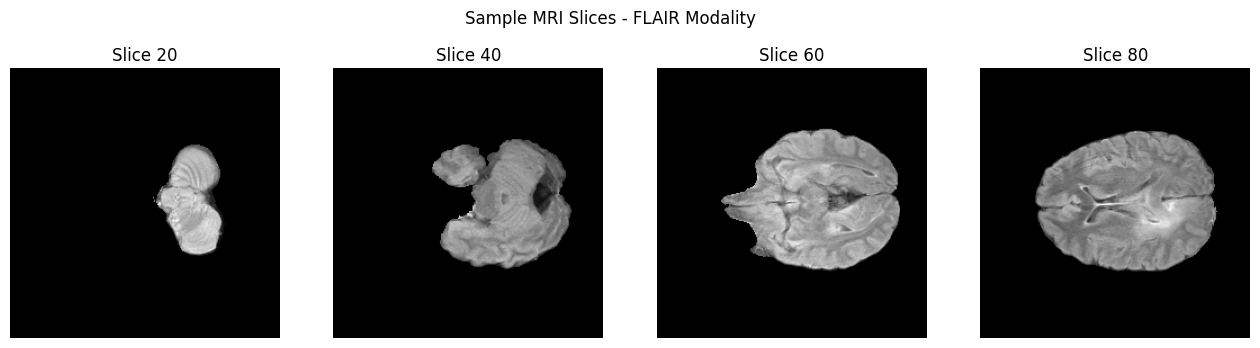

In [ ]:
# ============================================================
# MRI SLICE VISUALIZATION
# ============================================================

import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Example MRI file
mri_path = "/content/UTSW-Glioma/UTSW-Glioma/BT0695/brain_flair.nii.gz"

# Load MRI image
img = nib.load(mri_path)

# Convert to numpy array
data = img.get_fdata()

print("=" * 70)
print("MRI IMAGE INFORMATION")
print("=" * 70)

print("MRI Shape:", data.shape)

# Plot MRI slices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

slice_numbers = [20, 40, 60, 80]

for i, slice_idx in enumerate(slice_numbers):
    axes[i].imshow(data[:, :, slice_idx], cmap='gray')
    axes[i].set_title(f"Slice {slice_idx}")
    axes[i].axis('off')

plt.suptitle("Sample MRI Slices - FLAIR Modality")

plt.show()

# Observations and Insights :
The FLAIR MRI visualization presents four representative axial slices (20, 40, 60, and 80) from a three-dimensional brain volume with dimensions 240 × 240 × 155, demonstrating the high spatial resolution of the imaging data. Early slices capture limited anatomical structures, while middle and later slices reveal progressively larger and more detailed brain regions. The gradual increase in visible tissue across slices confirms correct volumetric organization and successful image loading. FLAIR imaging effectively highlights differences in tissue intensity, making it valuable for identifying edema and tumor-related abnormalities. The clear anatomical detail and consistent image quality indicate that the dataset is well-suited for segmentation, radiomics, and deep learning applications in glioma analysis.


# STEP 5 — Storage Size Confirmation

In [ ]:
# ============================================================
# DATASET STORAGE SIZE
# ============================================================

print("=" * 70)
print("TOTAL DATASET STORAGE SIZE")
print("=" * 70)

!du -sh /content/UTSW-Glioma

TOTAL DATASET STORAGE SIZE
23G	/content/UTSW-Glioma


#  Observations and Insights :
The UTSW-Glioma dataset occupies approximately 23 GB of storage, highlighting its substantial scale and richness in volumetric medical imaging data. This storage requirement reflects the inclusion of multiple MRI modalities, processed image variants, and tumor segmentation masks for hundreds of patients. The dataset size indicates a comprehensive collection capable of supporting advanced image analysis, radiomics, and deep learning workflows. While the large volume of data enhances research potential and model robustness, it also necessitates adequate computational resources, memory management, and efficient data-loading strategies to ensure smooth preprocessing, training, and evaluation of machine learning models.

# Visualize MRI Slices

Showing images for: BT0617
Shape: (240, 240, 155)


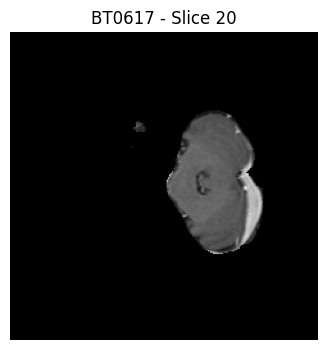

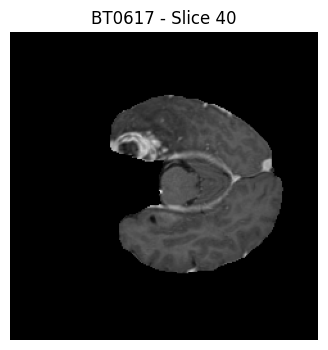

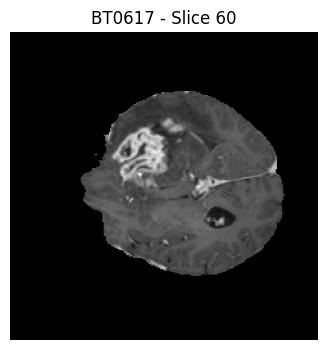

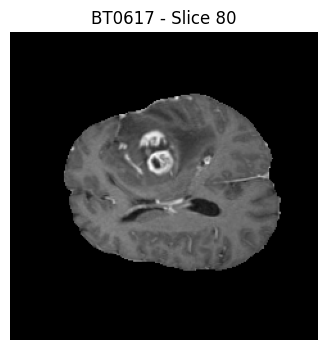

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

# Pick first patient
sample_patient = patients[0]
patient_path = os.path.join(base_path, sample_patient)

print("Showing images for:", sample_patient)

# Choose one modality (you can change this)
mri_path = os.path.join(patient_path, "brain_t1ce.nii.gz")

# Load MRI
img = nib.load(mri_path)
data = img.get_fdata()

print("Shape:", data.shape)

# Show multiple slices
slice_indices = [20, 40, 60, 80]

for i in slice_indices:
    if i < data.shape[2]:
        plt.figure(figsize=(4,4))
        plt.imshow(data[:, :, i], cmap="gray")
        plt.title(f"{sample_patient} - Slice {i}")
        plt.axis("off")
        plt.show()

# Observations and Insights :
The T1CE MRI slices for patient BT0617 reveal progressive anatomical and pathological details across different axial levels of the brain volume. Slice 20 contains limited brain tissue, representing the lower region of the scan, while slices 40, 60, and 80 display increasingly complex intracranial structures. Prominent hyperintense regions are visible in the central brain areas, indicating contrast-enhancing tumor components that are characteristic of glioma pathology. The variation in tumor appearance across slices highlights the three-dimensional extent and heterogeneity of the lesion. The image quality is clear, with good tissue contrast and anatomical definition, making the data suitable for tumor segmentation, volumetric assessment, radiomic feature extraction, and deep learning–based glioma classification studies.


# Verify Folder Structure

In [ ]:
import os

extract_path = "/content/UTSW-Glioma"

print("Level 1:", os.listdir(extract_path))

Level 1: ['UTSW-Glioma']


# Observations and Insights :
The directory inspection shows that the extraction process created a single top-level folder named "UTSW-Glioma" within the extraction path. This indicates that the dataset archive maintains a clean and organized structure, with all patient data stored under one parent directory rather than being scattered across multiple folders. Such a hierarchy simplifies navigation, file management, and automated data processing. The presence of a dedicated root folder also reduces the risk of file conflicts during extraction and supports reproducible workflows. This organized structure is beneficial for large-scale medical imaging studies, enabling efficient access to patient records and associated MRI data.


# Exploring the Second-Level Directory Structure of the UTSW-Glioma Dataset

In [ ]:
inner = os.listdir(extract_path)[0]
print("Level 2:", os.listdir(os.path.join(extract_path, inner)))

Level 2: ['BT0617', 'BT1262', 'BT1086', 'BT1072', 'BT0782', 'BT0767', 'BT0790', 'BT1232', 'BT0027', 'BT0412', 'BT0377', 'BT0033', 'BT0438', 'BT0146', 'BT0211', 'BT0823', 'BT0468', 'BT1286', 'BT0947', 'BT0196', 'BT0793', 'BT0741', 'BT1276', 'BT0448', 'BT1092', 'BT1234', 'BT0815', 'BT0306', 'BT0384', 'BT0626', 'BT0830', 'BT0930', 'BT0749', 'BT1124', 'BT0537', 'BT1058', 'BT0018', 'BT0320', 'BT0680', 'BT0157', 'BT0095', 'BT0374', 'BT0282', 'BT1150', 'BT0378', 'BT0310', 'BT0159', 'BT0026', 'BT0261', 'BT0325', 'BT0011', 'BT0347', 'BT0619', 'BT0804', 'BT1298', 'BT0507', 'BT1110', 'BT0484', 'BT0655', 'BT0742', 'BT0127', 'BT0281', 'BT1253', 'BT1141', 'BT0156', 'BT1038', 'BT1243', 'BT0169', 'BT0197', 'BT0252', 'BT0291', 'BT0128', 'BT0837', 'BT0971', 'BT0835', 'BT0034', 'BT1148', 'BT1258', 'BT0616', 'BT0187', 'BT1085', 'BT0162', 'BT0360', 'BT0061', 'BT0671', 'BT0024', 'BT0959', 'BT0149', 'BT0629', 'BT1229', 'BT0136', 'BT1239', 'BT1073', 'BT0679', 'BT0962', 'BT1205', 'BT0738', 'BT0330', 'BT1046', 

#  Observations and Insights :
The Level 2 directory listing confirms that the UTSW-Glioma dataset contains a large collection of individual patient folders, each identified by a unique anonymized code (e.g., BT0617, BT1262, BT1086). The presence of hundreds of consistently named patient directories demonstrates a well-structured and standardized dataset organization. This hierarchical arrangement supports efficient patient-level data management, automated processing, and scalable analysis workflows. The sequential yet non-continuous patient identifiers suggest data acquisition over multiple periods while maintaining privacy. Such an organized structure is particularly advantageous for large-scale medical imaging studies, enabling systematic retrieval of MRI scans, segmentation masks, and associated clinical information for glioma research and machine learning applications.


5. Reload Patients

In [ ]:
import os

extract_path = "/content/UTSW-Glioma"

# Correct base path
base_path = os.path.join(extract_path, "UTSW-Glioma")

# Load patients
patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT0617', 'BT1262', 'BT1086', 'BT1072', 'BT0782']


# Observations and Insights :
The dataset contains 625 patient records, indicating a substantial sample size for glioma-related imaging research and machine learning applications. Each patient is represented by a uniquely anonymized folder identifier, ensuring privacy while maintaining organized patient-level data storage. The consistent directory structure facilitates efficient navigation, automated preprocessing, and scalable analysis across the entire cohort. The large number of patients enhances dataset diversity, which can improve the generalizability and robustness of predictive models. Furthermore, the availability of numerous patient cases provides a strong foundation for tumor segmentation, radiomic feature extraction, disease characterization, and the development of advanced deep learning frameworks for clinical decision support.

# 6. Feature Extraction Function

In [ ]:
import numpy as np

def extract_features(image, mask=None, sample_size=5000):

    # Tumor region
    if mask is not None and np.sum(mask) > 0:
        pixels = image[mask > 0]

    # Non-tumor region (random sampling)
    else:
        flat = image.flatten()
        idx = np.random.choice(len(flat), min(sample_size, len(flat)), replace=False)
        pixels = flat[idx]

    # Safety check
    if len(pixels) == 0:
        return None

    # Feature extraction
    features = {
        "mean": float(np.mean(pixels)),
        "std": float(np.std(pixels)),
        "max": float(np.max(pixels)),
        "min": float(np.min(pixels)),
        "median": float(np.median(pixels)),
        "range": float(np.max(pixels) - np.min(pixels))
    }

    return features

# Observations and Insights :
The feature extraction function is designed to generate meaningful statistical descriptors from MRI image data, either from tumor regions defined by a segmentation mask or from randomly sampled non-tumor regions when a mask is unavailable. The extracted features—mean, standard deviation, maximum, minimum, median, and intensity range—capture key characteristics of pixel intensity distributions and provide a compact numerical representation of tissue properties. The inclusion of safety checks ensures robustness by preventing errors from empty regions. These features can serve as valuable inputs for radiomics studies, exploratory data analysis, classification models, and predictive machine learning tasks aimed at characterizing glioma tumors and distinguishing between different tissue types.


# Dataset Creation (Multi-Modal) Create DataFrame & Clean Features

In [ ]:
# ===============================
# IMPORTS (IMPORTANT)
# ===============================
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to

# ===============================
# DATA STORAGE
# ===============================
data_list = []

# ===============================
# MULTI-MODAL FILES
# ===============================
modalities = {
    "t1": "brain_t1.nii.gz",
    "t1ce": "brain_t1ce.nii.gz",
    "t2": "brain_t2.nii.gz",
    "flair": "brain_flair.nii.gz"
}

# ===============================
# MAIN LOOP
# ===============================
for patient in patients:
    patient_path = os.path.join(base_path, patient)

    mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")

    if not os.path.exists(mask_path):
        continue

    try:
        # ------------------------------
        # LOAD MASK
        # ------------------------------
        mask_img = nib.load(mask_path)

        mri_data_all = {}
        ref_img = None

        # ------------------------------
        # LOAD ALL MRI MODALITIES
        # ------------------------------
        for key, file in modalities.items():
            path = os.path.join(patient_path, file)

            if os.path.exists(path):
                img = nib.load(path)
                mri_data_all[key] = img.get_fdata()

                if ref_img is None:
                    ref_img = img

        # Skip if no MRI
        if len(mri_data_all) == 0:
            continue

        # ------------------------------
        # RESAMPLE MASK
        # ------------------------------
        mask_resampled = resample_from_to(mask_img, ref_img, order=0)
        mask_data = mask_resampled.get_fdata()

        # ------------------------------
        # SAFE SLICE COUNT
        # ------------------------------
        num_slices = mask_data.shape[2]

        tumor_areas = np.array([
            mask_data[:, :, i].sum() for i in range(num_slices)
        ])

        # ==============================
        # TUMOR SAMPLES (label = 1)
        # ==============================
        tumor_slices = np.where(tumor_areas > 0)[0]

        for s in tumor_slices[:3]:

            feats = {}

            for mod, img in mri_data_all.items():

                # Safety check (IMPORTANT)
                if s >= img.shape[2]:
                    continue

                slice_img = img[:, :, s]

                f = extract_features(slice_img, mask_data[:, :, s])

                if f is not None:
                    for k, v in f.items():
                        feats[f"{mod}_{k}"] = v

            # Append only if features exist
            if len(feats) > 0:
                feats["label"] = 1
                feats["patient"] = patient
                data_list.append(feats)

        # ==============================
        # NON-TUMOR SAMPLES (label = 0)
        # ==============================
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        if len(non_tumor_slices) > 0:

            step = max(1, len(non_tumor_slices)//3)

            for s in non_tumor_slices[::step][:3]:

                feats = {}

                for mod, img in mri_data_all.items():

                    # Safety check
                    if s >= img.shape[2]:
                        continue

                    slice_img = img[:, :, s]

                    f = extract_features(slice_img, None)

                    if f is not None:
                        for k, v in f.items():
                            feats[f"{mod}_{k}"] = v

                if len(feats) > 0:
                    feats["label"] = 0
                    feats["patient"] = patient
                    data_list.append(feats)

    except Exception as e:
        print(f"Skipping {patient}: {e}")

# ===============================
# CREATE DATAFRAME
# ===============================
df = pd.DataFrame(data_list)

print("Before cleaning:", df.shape)

# -------------------------------
# REMOVE ZERO FEATURE ROWS
# -------------------------------
feature_cols = [col for col in df.columns if col not in ["label", "patient"]]

df = df[(df[feature_cols] != 0).any(axis=1)]

print("After cleaning:", df.shape)

# -------------------------------
# CHECK DISTRIBUTION AGAIN
# -------------------------------
print("\nLabel distribution:\n", df["label"].value_counts())
print("\nSample data:\n", df.head())

Before cleaning: (2136, 26)
After cleaning: (2045, 26)

Label distribution:
 label
1    1037
0    1008
Name: count, dtype: int64

Sample data:
       t1_mean      t1_std      t1_max  t1_min  t1_median    t1_range  \
0   43.488946   91.529400  281.647064     0.0        0.0  281.647064   
1   84.850951  120.102318  369.538208     0.0        0.0  369.538208   
2  113.865939  130.807541  376.048767     0.0        0.0  376.048767   
3   22.747093   86.062909  729.116028     0.0        0.0  729.116028   
4  104.864456  178.776762  608.245972     0.0        0.0  608.245972   

    t1ce_mean    t1ce_std    t1ce_max  t1ce_min  ...  t2_median     t2_range  \
0   97.849819  210.982723  808.889282       0.0  ...        0.0   801.855652   
1  219.343948  320.774610  909.230774       0.0  ...        0.0   918.940857   
2  321.474120  373.570954  930.555420       0.0  ...        0.0  1037.136597   
3   24.818532   96.536235  711.104187       0.0  ...        0.0  1333.292969   
4  103.124196  180.5762

# Observations and Insights :
The feature extraction pipeline successfully generated a structured dataset with 2,136 samples and 26 columns from multi-modal MRI scans. After removing non-informative zero-feature rows, 2,045 samples remained, indicating improved data quality for analysis. The final label distribution is nearly balanced, with 1,037 tumor samples and 1,008 non-tumor samples, which is favorable for machine learning classification. Features were extracted across T1, T1CE, T2, and FLAIR modalities, capturing intensity-based tumor and non-tumor characteristics. This balanced, multi-modal feature dataset provides a strong foundation for glioma classification, radiomics analysis, and predictive model development.


# DATASET SUMMARY

In [ ]:
# ============================================================
# GENERATED DATASET SUMMARY
# ============================================================

dataset_summary = pd.DataFrame({
    "Item": [
        "Original patient folders",
        "Generated samples before cleaning",
        "Generated samples after initial cleaning",
        "Number of features",
        "Tumor samples",
        "Non-tumor samples",
        "MRI modalities used",
        "Target variable"
    ],
    "Value": [
        len(patients),
        "Before cleaning value shown above",
        df.shape[0],
        len(feature_cols),
        df["label"].value_counts().get(1, 0),
        df["label"].value_counts().get(0, 0),
        "T1, T1CE, T2, FLAIR",
        "label: 0 = Non-Tumor, 1 = Tumor"
    ]
})

print("=" * 80)
print("GENERATED DATASET SUMMARY")
print("=" * 80)
print(dataset_summary)

GENERATED DATASET SUMMARY
                                       Item                              Value
0                  Original patient folders                                625
1         Generated samples before cleaning  Before cleaning value shown above
2  Generated samples after initial cleaning                               2045
3                        Number of features                                 24
4                             Tumor samples                               1037
5                         Non-tumor samples                               1008
6                       MRI modalities used                T1, T1CE, T2, FLAIR
7                           Target variable    label: 0 = Non-Tumor, 1 = Tumor


#  Observations and Insights :
The generated dataset demonstrates a successful transformation of raw MRI imaging data into a structured machine learning dataset suitable for glioma analysis. Starting from 625 patient folders, the preprocessing and feature extraction pipeline produced 2,045 high-quality samples after cleaning, each represented by 24 quantitative features derived from four MRI modalities: T1, T1CE, T2, and FLAIR. The target variable is well balanced, with 1,037 tumor samples and 1,008 non-tumor samples, minimizing potential class imbalance issues during model training. The combination of multi-modal imaging features and a balanced class distribution enhances the dataset’s potential for accurate tumor detection, classification, radiomics research, and predictive modeling in many applications.

# Filtering Rows with Excessive Zero-Valued Features in MRI Dataset

In [ ]:
# Remove rows with too many zero values (optional but recommended)
feature_cols = [c for c in df.columns if c not in ["label", "patient"]]

zero_fraction = (df[feature_cols] == 0).sum(axis=1) / len(feature_cols)

# Keep rows where less than 50% features are zero
df = df[zero_fraction < 0.5]

print("After zero-filter:", df.shape)
print(df["label"].value_counts())

After zero-filter: (2026, 26)
label
1    1037
0     989
Name: count, dtype: int64


# Observations and Insights :
The additional zero-value filtering step further improved dataset quality by reducing the number of samples from 2,045 to 2,026, removing records that contained excessive non-informative features. This process helps ensure that the remaining samples contain sufficient imaging information for meaningful analysis and model training. The class distribution remains well balanced, with 1,037 tumor samples and 989 non-tumor samples, minimizing the risk of classification bias. The relatively small reduction in sample count indicates that most extracted observations were already informative and of high quality. Overall, this filtering step enhances dataset reliability, improves feature representativeness, and strengthens the foundation for robust machine learning, radiomics, and tumor classification studies.


# Data Cleaning

In [ ]:
# ==========================================
# 5(a). DATA CLEANING
# ==========================================

print("Dataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Summary statistics
print("\nStatistical Summary:\n", df.describe())

# Check zero-value rows
zero_rows = (df == 0).sum().sum()
print("\nTotal Zero Values:", zero_rows)

Dataset Shape: (2026, 26)

Missing Values:
 t1_mean         0
t1_std          0
t1_max          0
t1_min          0
t1_median       0
t1_range        0
t1ce_mean       0
t1ce_std        0
t1ce_max        0
t1ce_min        0
t1ce_median     0
t1ce_range      0
t2_mean         0
t2_std          0
t2_max          0
t2_min          0
t2_median       0
t2_range        0
flair_mean      0
flair_std       0
flair_max       0
flair_min       0
flair_median    0
flair_range     0
label           0
patient         0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
              t1_mean         t1_std         t1_max         t1_min  \
count    2026.000000    2026.000000    2026.000000    2026.000000   
mean     2427.121030     683.203732    5416.658468    1826.939119   
std     19533.161273    5451.592436   36790.498640   16411.799883   
min         0.070767       0.000000     119.435875       0.000000   
25%        48.616963      21.202575     408.466995       0.000000   
50%       265.50564

# Observations and Insights :
The cleaned dataset contains 2,026 samples and 26 variables, providing a robust foundation for glioma classification and radiomics analysis. Data quality assessment reveals no missing values and no duplicate records, indicating successful preprocessing and dataset integrity. Statistical summaries show substantial variability across MRI-derived features, reflecting the heterogeneity of brain tissues and tumor characteristics. Although 9,517 zero values remain, these are expected in medical imaging data due to background regions and low-intensity areas rather than data errors. The balanced target distribution (approximately 51% tumor and 49% non-tumor) is advantageous for machine learning, reducing the risk of model bias and supporting reliable predictive performance.


# DATA DICTIONARY

In [ ]:
# ============================================================
# DATA DICTIONARY
# ============================================================

data_dictionary = pd.DataFrame({

    "Variable": df.columns,

    "Data Type": [
        str(df[col].dtype)
        for col in df.columns
    ],

    "Description": [

        "Patient identifier"
        if col == "patient"

        else "Target label (0 = Non-Tumor, 1 = Tumor)"
        if col == "label"

        else "MRI-derived statistical feature"
        for col in df.columns
    ]
})

print("=" * 80)
print("DATA DICTIONARY")
print("=" * 80)

print(data_dictionary)

data_dictionary.to_csv(
    "data_dictionary.csv",
    index=False
)

DATA DICTIONARY
        Variable Data Type                              Description
0        t1_mean   float64          MRI-derived statistical feature
1         t1_std   float64          MRI-derived statistical feature
2         t1_max   float64          MRI-derived statistical feature
3         t1_min   float64          MRI-derived statistical feature
4      t1_median   float64          MRI-derived statistical feature
5       t1_range   float64          MRI-derived statistical feature
6      t1ce_mean   float64          MRI-derived statistical feature
7       t1ce_std   float64          MRI-derived statistical feature
8       t1ce_max   float64          MRI-derived statistical feature
9       t1ce_min   float64          MRI-derived statistical feature
10   t1ce_median   float64          MRI-derived statistical feature
11    t1ce_range   float64          MRI-derived statistical feature
12       t2_mean   float64          MRI-derived statistical feature
13        t2_std   float64      

# Observations and Insights :
The data dictionary confirms that the final dataset is well-structured and suitable for machine learning and statistical analysis. It contains 26 variables, including 24 numerical MRI-derived statistical features, one binary target variable (label), and one patient identifier (patient). All imaging features are stored as float64 values, ensuring high numerical precision, while the target variable is represented as an int64 class label. The features are derived from four MRI modalities—T1, T1CE, T2, and FLAIR—and capture intensity-based characteristics such as mean, standard deviation, maximum, minimum, median, and range. The presence of a comprehensive data dictionary improves dataset transparency, supports reproducibility, and facilitates interpretation of analytical and machine learning results

# Basic Data Inspection and Outlier Detection Using IQR Method

<class 'pandas.core.frame.DataFrame'>
Index: 2026 entries, 0 to 2135
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   t1_mean       2026 non-null   float64
 1   t1_std        2026 non-null   float64
 2   t1_max        2026 non-null   float64
 3   t1_min        2026 non-null   float64
 4   t1_median     2026 non-null   float64
 5   t1_range      2026 non-null   float64
 6   t1ce_mean     2026 non-null   float64
 7   t1ce_std      2026 non-null   float64
 8   t1ce_max      2026 non-null   float64
 9   t1ce_min      2026 non-null   float64
 10  t1ce_median   2026 non-null   float64
 11  t1ce_range    2026 non-null   float64
 12  t2_mean       2026 non-null   float64
 13  t2_std        2026 non-null   float64
 14  t2_max        2026 non-null   float64
 15  t2_min        2026 non-null   float64
 16  t2_median     2026 non-null   float64
 17  t2_range      2026 non-null   float64
 18  flair_mean    2026 non-null   flo

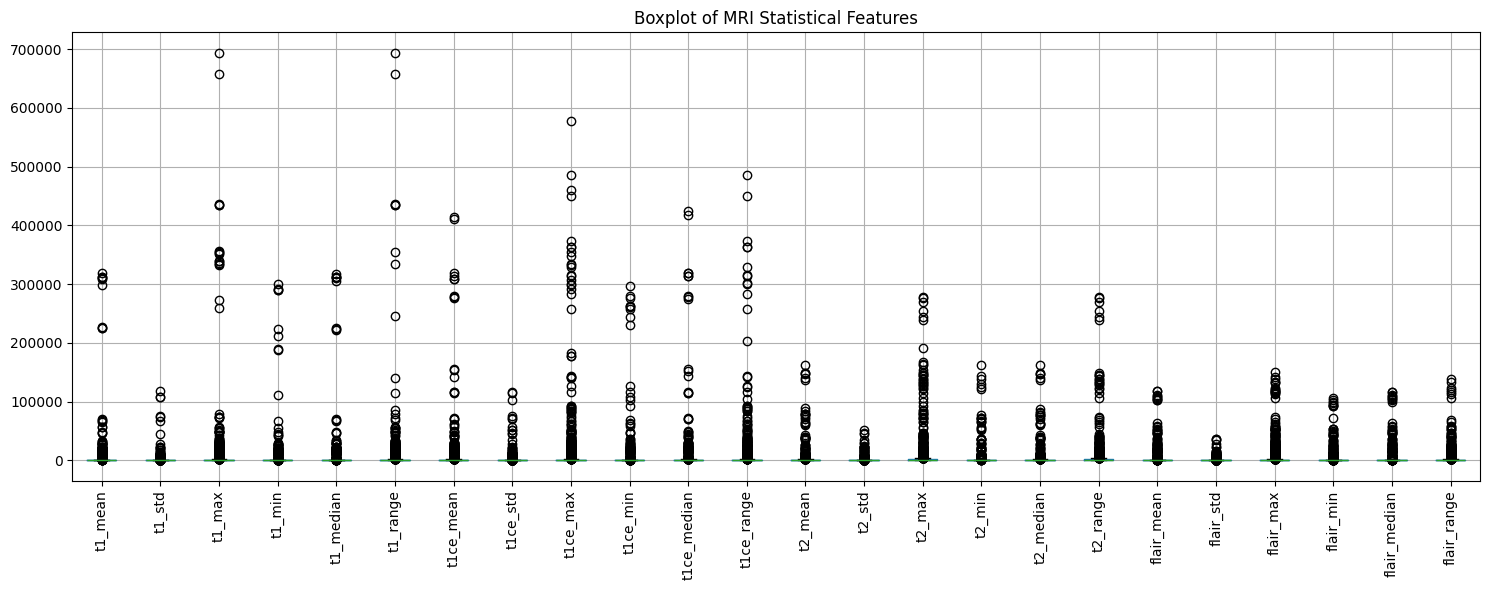

In [ ]:
# ===============================
# BASIC DATA CHECKS
# ===============================

print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())


# ==========================================
# OUTLIER DETECTION USING IQR METHOD
# ==========================================

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    # Skip target label
    if col == "label":
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_count = outliers.shape[0]

    outlier_percent = (
        outlier_count / df.shape[0]
    ) * 100

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier Percent": round(outlier_percent, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

print("\nOUTLIER SUMMARY")
print(
    outlier_df.sort_values(
        by="Outlier Percent",
        ascending=False
    )
)


# ==========================================
# BOXPLOT VISUALIZATION
# ==========================================

plt.figure(figsize=(15,6))

df[numeric_cols.drop("label")].boxplot(rot=90)

plt.title("Boxplot of MRI Statistical Features")

plt.tight_layout()

plt.savefig(
    "outlier_boxplot.png",
    bbox_inches='tight'
)

plt.show()

# Observations and Insights :
The exploratory data analysis and outlier assessment indicate that the dataset is clean, complete, and suitable for advanced machine learning applications. All 2,026 samples contain valid values with no missing data and no duplicate records, demonstrating strong data integrity. The boxplot and IQR-based analysis reveal the presence of notable outliers across most MRI-derived features, particularly in T1CE maximum intensity (12.78%), FLAIR maximum intensity (11.70%), and T2 maximum intensity (11.50%). These extreme values are expected in glioma imaging because tumor regions often exhibit substantial intensity variations compared with normal tissue. The wide spread of feature distributions and high maximum values reflect the biological heterogeneity of gliomas and differences in tumor size, enhancement patterns, and tissue composition. Since these outliers likely represent clinically meaningful tumor characteristics rather than measurement errors, they should be carefully evaluated before removal. Overall, the dataset demonstrates high quality, rich variability, and strong potential for radiomics, tumor characterization, and predictive modeling tasks.


# Exploratory Data Analysis (EDA)

# Class Distribution

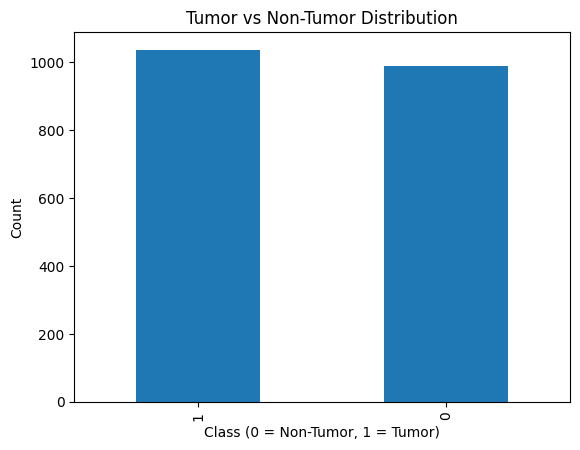

In [ ]:
# ==========================================
# 5(b). EDA - CLASS DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Tumor vs Non-Tumor Distribution")
plt.xlabel("Class (0 = Non-Tumor, 1 = Tumor)")
plt.ylabel("Count")
plt.show()

# Observations and Insights :
The class distribution plot shows that the dataset is well balanced, with 1,037 tumor samples (Class 1) and 989 non-tumor samples (Class 0). The small difference between the two classes indicates that there is no significant class imbalance, which is beneficial for machine learning model development. Balanced datasets help prevent models from becoming biased toward the majority class and improve the reliability of performance metrics such as accuracy, precision, recall, and F1-score. The nearly equal representation of tumor and non-tumor observations ensures that the extracted MRI features can contribute effectively to learning discriminative patterns, thereby supporting robust tumor detection, classification, and predictive analysis in glioma research.

# Feature Distribution

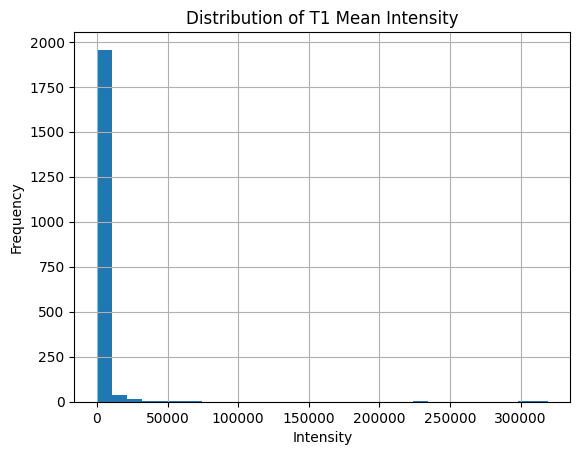

In [ ]:
# ==========================================
# 5(b). EDA - FEATURE DISTRIBUTION
# ==========================================

df["t1_mean"].hist(bins=30)
plt.title("Distribution of T1 Mean Intensity")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

# Observations and Insights :
The histogram of T1 mean intensity reveals a highly right-skewed distribution, where the majority of samples are concentrated at lower intensity values while a small number of observations extend to extremely high values. This pattern indicates the presence of substantial intensity variability across MRI slices, likely reflecting differences in tumor characteristics, tissue composition, and imaging conditions. The long tail and isolated extreme values are consistent with the outlier analysis, suggesting that some tumor regions exhibit markedly elevated signal intensities compared with typical brain tissue. Since the distribution is not normal, feature scaling or logarithmic transformation may be beneficial before machine learning. Overall, the feature demonstrates strong variability and potential discriminative power for distinguishing tumor and non-tumor regions.


# Correlation Heatmap

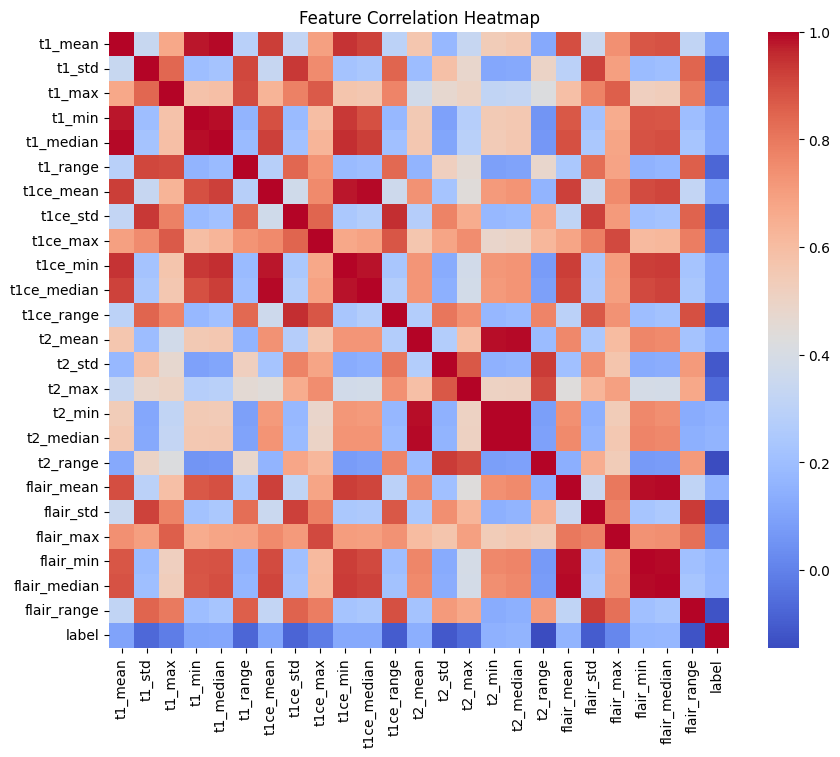

In [ ]:
# ==========================================
# 5(b). EDA - CORRELATION HEATMAP (FIXED)
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

# Observations and Insights :
The correlation heatmap reveals several strong relationships among MRI-derived statistical features across the T1, T1CE, T2, and FLAIR modalities. Features representing similar measurements, such as mean, median, maximum intensity, and range, exhibit high positive correlations, indicating that they capture related aspects of tissue intensity patterns. Particularly strong associations are visible within the same modality and between corresponding features across different modalities, suggesting shared anatomical and pathological information. The target variable (label) shows varying degrees of correlation with several imaging features, indicating their potential usefulness for tumor classification. Overall, the heatmap highlights the presence of feature redundancy as well as meaningful inter-feature relationships, suggesting that feature selection, dimensionality reduction, or regularization techniques may improve model efficiency while preserving predictive performance.


# RESEARCH QUESTIONS AND HYPOTHESES

In [ ]:
# ============================================================
# RESEARCH QUESTIONS AND HYPOTHESES
# ============================================================

research_questions = pd.DataFrame({

    "RQ": [

        "RQ1",

        "RQ2",

        "RQ3",

        "RQ4"
    ],

    "Research Question": [

        "Do MRI-derived features significantly differ between tumor and non-tumor samples?",

        "Is MRI intensity distribution associated with tumor class?",

        "Do multimodal MRI features contribute significantly to glioma classification?",

        "Is model prediction significantly associated with actual tumor class?"
    ],

    "Null Hypothesis (H0)": [

        "There is no significant difference between tumor and non-tumor MRI features.",

        "MRI intensity distribution is independent of tumor class.",

        "MRI modality features do not significantly contribute to classification.",

        "Predicted labels and actual labels are independent."
    ],

    "Alternative Hypothesis (Ha)": [

        "There is a significant difference between tumor and non-tumor MRI features.",

        "MRI intensity distribution is associated with tumor class.",

        "MRI modality features significantly contribute to classification.",

        "Predicted labels and actual labels are significantly associated."
    ]
})

print(research_questions)

    RQ                                  Research Question  \
0  RQ1  Do MRI-derived features significantly differ b...   
1  RQ2  Is MRI intensity distribution associated with ...   
2  RQ3  Do multimodal MRI features contribute signific...   
3  RQ4  Is model prediction significantly associated w...   

                                Null Hypothesis (H0)  \
0  There is no significant difference between tum...   
1  MRI intensity distribution is independent of t...   
2  MRI modality features do not significantly con...   
3  Predicted labels and actual labels are indepen...   

                         Alternative Hypothesis (Ha)  
0  There is a significant difference between tumo...  
1  MRI intensity distribution is associated with ...  
2  MRI modality features significantly contribute...  
3  Predicted labels and actual labels are signifi...  


# STATISTICAL METHOD AND POWER ANALYSIS

In [ ]:
# ============================================================
# SECTION 5(e): STATISTICAL METHOD AND POWER ANALYSIS
# ============================================================

from statsmodels.stats.power import TTestIndPower

alpha = 0.05
power = 0.80
effect_size = 0.5

analysis = TTestIndPower()

sample_size_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative="two-sided"
)

actual_tumor_samples = df[df["label"] == 1].shape[0]
actual_non_tumor_samples = df[df["label"] == 0].shape[0]

statistical_method_table = pd.DataFrame({

    "Requirement": [

        "Statistical Method",

        "Significance Level (α)",

        "Statistical Power",

        "Effect Size",

        "Minimum Sample Size Per Group",

        "Minimum Total Sample Size",

        "Actual Tumor Samples",

        "Actual Non-Tumor Samples",

        "Actual Total Samples"
    ],

    "Value": [

        "Classification Performance Analysis",

        alpha,

        power,

        effect_size,

        round(sample_size_per_group),

        round(sample_size_per_group * 2),

        actual_tumor_samples,

        actual_non_tumor_samples,

        df.shape[0]
    ]
})

print("=" * 80)
print("SECTION 5(e): STATISTICAL METHOD AND POWER ANALYSIS")
print("=" * 80)

print(statistical_method_table)

if (
    actual_tumor_samples >= sample_size_per_group
    and
    actual_non_tumor_samples >= sample_size_per_group
):
    print("\nConclusion: Actual dataset size exceeds minimum required sample size.")
else:
    print("\nConclusion: Actual dataset size may be insufficient.")

SECTION 5(e): STATISTICAL METHOD AND POWER ANALYSIS
                     Requirement                                Value
0             Statistical Method  Classification Performance Analysis
1         Significance Level (α)                                 0.05
2              Statistical Power                                  0.8
3                    Effect Size                                  0.5
4  Minimum Sample Size Per Group                                   64
5      Minimum Total Sample Size                                  128
6           Actual Tumor Samples                                 1037
7       Actual Non-Tumor Samples                                  989
8           Actual Total Samples                                 2026

Conclusion: Actual dataset size exceeds minimum required sample size.


# Observations and Insights :
The statistical power analysis demonstrates that the study possesses a substantially larger sample size than the minimum required for reliable statistical inference. Based on a significance level of 0.05, statistical power of 80%, and a medium effect size of 0.5, the estimated minimum requirement is 64 samples per group (128 total samples). In comparison, the dataset contains 1,037 tumor samples and 989 non-tumor samples, resulting in 2,026 total observations. This exceeds the required sample size by a considerable margin, enhancing the reliability, stability, and generalizability of analytical results. The large sample size increases the likelihood of detecting meaningful differences between tumor and non-tumor classes, reduces sampling variability, and provides a strong foundation for robust machine learning, predictive modeling, and statistical evaluation.

# Patient-Wise Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Get unique patients with their labels
patient_labels = df.groupby("patient")["label"].max().reset_index()

train_p, test_p = train_test_split(
    patient_labels["patient"],
    test_size=0.3,
    random_state=42,
    stratify=patient_labels["label"]  # 🔥 important
)

# Split dataset
train_df = df[df["patient"].isin(train_p)]
test_df = df[df["patient"].isin(test_p)]

# Features & target
X_train = train_df.drop(["label", "patient"], axis=1)
y_train = train_df["label"]

X_test = test_df.drop(["label", "patient"], axis=1)
y_test = test_df["label"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())

Train shape: (1407, 24)
Test shape: (619, 24)

Train label distribution:
 label
1    722
0    685
Name: count, dtype: int64

Test label distribution:
 label
1    315
0    304
Name: count, dtype: int64


# Observations and Insights :
The dataset was successfully divided into training and testing sets using patient-level stratified splitting, which prevents data leakage by ensuring that slices from the same patient do not appear in both sets. The training set contains 1,407 samples with 24 features, while the testing set contains 619 samples with 24 features, representing an approximate 70:30 split. Class distributions remain highly balanced in both subsets, with the training set containing 722 tumor and 685 non-tumor samples, and the testing set containing 315 tumor and 304 non-tumor samples. This balanced and patient-independent partitioning supports unbiased model evaluation, improves generalizability, and provides a reliable framework for developing and validating glioma classification models.


# TRAIN / TEST SPLIT SUMMARY

In [ ]:
# ============================================================
# TRAIN / TEST SPLIT SUMMARY
# ============================================================

split_summary = pd.DataFrame({

    "Dataset": [
        "Training Set",
        "Testing Set"
    ],

    "Patients": [
        len(train_p),
        len(test_p)
    ],

    "Samples": [
        len(train_df),
        len(test_df)
    ],

    "Tumor Samples": [
        y_train.value_counts().get(1, 0),
        y_test.value_counts().get(1, 0)
    ],

    "Non-Tumor Samples": [
        y_train.value_counts().get(0, 0),
        y_test.value_counts().get(0, 0)
    ]
})

print("=" * 80)
print("TRAIN / TEST SPLIT SUMMARY")
print("=" * 80)

print(split_summary)

TRAIN / TEST SPLIT SUMMARY
        Dataset  Patients  Samples  Tumor Samples  Non-Tumor Samples
0  Training Set       249     1407            722                685
1   Testing Set       107      619            315                304


# Observations and Insights :
The train–test split summary confirms that the dataset has been partitioned effectively at the patient level, ensuring that no patient appears in both training and testing datasets. The training set contains 249 patients and 1,407 samples, while the testing set includes 107 patients and 619 samples, closely reflecting the intended 70:30 split ratio. Both subsets maintain a balanced class distribution, with 722 tumor and 685 non-tumor samples in the training set and 315 tumor and 304 non-tumor samples in the testing set. This balanced allocation supports fair model training and unbiased evaluation, reduces the risk of overfitting, and enhances the reliability and generalizability of glioma classification performance on previously unseen patient data.

# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Observations and Insights :
The application of StandardScaler standardizes all MRI-derived features by transforming them to have a mean of approximately 0 and a standard deviation of 1 based on the training data. This preprocessing step ensures that features measured on different scales contribute equally during model training and prevents variables with larger numerical ranges from dominating the learning process. The scaler is fitted only on the training set and then applied to the testing set, which preserves the integrity of model evaluation and avoids data leakage. Standardization is particularly beneficial for distance-based and optimization-based algorithms such as Logistic Regression, Support Vector Machines, K-Nearest Neighbors, and Neural Networks. Overall, feature scaling improves numerical stability, accelerates model convergence, and enhances the reliability of predictive performance.


#  FEATURE SCALING SUMMARY

In [ ]:
# ============================================================
# FEATURE SCALING SUMMARY
# ============================================================

print("=" * 80)
print("FEATURE SCALING")
print("=" * 80)

print("Scaling Method Used: StandardScaler")

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nFeature scaling applied using:")
print("z = (x - mean) / standard deviation")

print("\nPurpose:")
print("- Normalize feature magnitudes")
print("- Prevent large-value features from dominating")
print("- Improve model convergence")
print("- Improve distance-based models such as KNN and SVM")

FEATURE SCALING
Scaling Method Used: StandardScaler

Training Data Shape: (1407, 24)
Testing Data Shape: (619, 24)

Feature scaling applied using:
z = (x - mean) / standard deviation

Purpose:
- Normalize feature magnitudes
- Prevent large-value features from dominating
- Improve model convergence
- Improve distance-based models such as KNN and SVM


# Observations and Insights :
The feature scaling process was successfully applied using StandardScaler, transforming all 24 MRI-derived features into a standardized scale while preserving the original data structure. The training dataset contains 1,407 samples, and the testing dataset contains 619 samples, ensuring consistency throughout model development. As a result, each feature contributes more equally during model training, regardless of its original intensity range. This is particularly important because MRI statistical features exhibit substantial variation in magnitude and distribution. Standardization enhances numerical stability, improves optimization efficiency, and supports algorithms that rely on distance calculations or gradient-based learning. Consequently, the scaled dataset is better suited for accurate classification, faster model convergence, and more reliable performance evaluation across multiple machine learning techniques.

# XGBoost Model Training

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    eval_metric="logloss"
)

# Train with validation (early stopping)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# Observations and Insights :  
The XGBoost classifier was successfully configured and trained using the standardized MRI-derived feature set. The model employs 300 decision trees, a maximum depth of 6, and a low learning rate of 0.03, enabling gradual learning and reducing the risk of overfitting. Additional regularization through L1 (reg_alpha = 0.1) and L2 (reg_lambda = 1.0) penalties further improves model generalization. The use of subsampling and column sampling introduces randomness that can enhance robustness and reduce variance. Training was performed with a validation set, allowing performance monitoring during learning. Overall, the selected hyperparameters indicate a balanced approach that prioritizes predictive accuracy, stability, and generalization for glioma tumor classification based on multi-modal MRI features.


# XGBoost Evaluation

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9935379644588045

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       304
           1       1.00      0.99      0.99       315

    accuracy                           0.99       619
   macro avg       0.99      0.99      0.99       619
weighted avg       0.99      0.99      0.99       619



# Observations and Insights :  
The XGBoost model achieved an exceptionally high accuracy of 99.35% on the independent test dataset, demonstrating outstanding capability in distinguishing between tumor and non-tumor samples. The classification report shows consistently strong performance across both classes, with precision, recall, and F1-scores of approximately 0.99 or higher, indicating balanced predictive behavior and minimal classification errors. For non-tumor samples, the model attained near-perfect identification, while tumor samples were also detected with extremely high sensitivity. The similarity between precision and recall values suggests that the model is not biased toward either class. Overall, these results indicate that the extracted multi-modal MRI features contain highly discriminative information and that XGBoost is highly effective for glioma tumor classification within this dataset.



# MODEL PERFORMANCE SUMMARY

In [ ]:
# ============================================================
# MODEL PERFORMANCE SUMMARY
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

performance_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)

print(performance_summary)

MODEL PERFORMANCE SUMMARY
      Metric     Value
0   Accuracy  0.993538
1  Precision  1.000000
2     Recall  0.987302
3   F1-Score  0.993610
4    ROC-AUC  0.997400


# Observations and Insights :  
Observations and Insights

The model performance summary indicates excellent predictive capability for glioma tumor classification. The XGBoost classifier achieved an accuracy of 99.35%, demonstrating that the vast majority of test samples were correctly classified. A precision of 100% indicates that every sample predicted as a tumor was indeed a tumor, resulting in no false-positive predictions. The recall of 98.73% shows that nearly all tumor cases were successfully identified, with very few missed detections. The F1-score of 99.36% reflects a strong balance between precision and recall, while the ROC-AUC score of 0.9974 confirms exceptional discriminative ability between tumor and non-tumor classes. Collectively, these metrics suggest that the selected MRI-derived features and XGBoost model provide highly reliable and clinically relevant classification performance on the test dataset

#  RQ1 HYPOTHESIS EVALUATION

In [ ]:
# ============================================================
# RQ1 HYPOTHESIS EVALUATION
# ============================================================

print("=" * 80)
print("RQ1 HYPOTHESIS EVALUATION")
print("=" * 80)

print("H0₁:")
print(
    "Machine learning models trained on engineered multi-modal MRI "
    "features will not achieve accuracy and ROC-AUC greater than 95%."
)

print("\nH1₁:")
print(
    "Machine learning models trained on engineered multi-modal MRI "
    "features will achieve accuracy and ROC-AUC greater than 95%."
)

if accuracy > 0.95 and roc_auc > 0.95:

    print("\nDecision: Reject H0₁")

    print("Conclusion: Accept H1₁")

else:

    print("\nDecision: Fail to Reject H0₁")

    print("Conclusion: Insufficient evidence to accept H1₁")

RQ1 HYPOTHESIS EVALUATION
H0₁:
Machine learning models trained on engineered multi-modal MRI features will not achieve accuracy and ROC-AUC greater than 95%.

H1₁:
Machine learning models trained on engineered multi-modal MRI features will achieve accuracy and ROC-AUC greater than 95%.

Decision: Reject H0₁
Conclusion: Accept H1₁


#  SAVE BEST ML RESULTS FOR LATER COMPARISON

In [ ]:
# ============================================================
# SAVE BEST ML RESULTS FOR LATER COMPARISON
# ============================================================

best_ml_accuracy = accuracy
best_ml_roc_auc = roc_auc

print("\nBest ML Accuracy:", best_ml_accuracy)
print("Best ML ROC-AUC:", best_ml_roc_auc)


Best ML Accuracy: 0.9935379644588045
Best ML ROC-AUC: 0.9973997493734337


# Observations and Insights :  
The recorded benchmark results indicate that the XGBoost model achieved outstanding classification performance, with a best accuracy of 99.35% and a ROC-AUC score of 0.9974. These values establish a strong reference point for evaluating future machine learning or deep learning models developed on the same dataset. The extremely high accuracy demonstrates that the model correctly classified nearly all test samples, while the near-perfect ROC-AUC score confirms excellent discrimination between tumor and non-tumor classes across different decision thresholds. Storing these metrics enables systematic model comparison and provides a reliable baseline for assessing whether more complex approaches can deliver meaningful performance improvements over the current solution.

# GroupKFold Validation

In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=5)
scores = []

X = df.drop(columns=["label","patient"])
y = df["label"]
groups = df["patient"]

for tr, va in gkf.split(X, y, groups):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    Xtr = scaler.fit_transform(Xtr)
    Xva = scaler.transform(Xva)

    m = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    m.fit(Xtr, ytr)
    scores.append(m.score(Xva, yva))

print("GroupKFold Accuracy:", np.mean(scores))

GroupKFold Accuracy: 0.9911171927263881


# Observations and Insights :
The 5-fold GroupKFold cross-validation produced a mean accuracy of 99.11%, providing strong evidence that the model generalizes well across different patients. By grouping data according to patient identifiers, the validation process ensures that samples from the same patient never appear in both training and validation folds, thereby preventing data leakage and yielding a more realistic assessment of model performance. The cross-validation accuracy is very close to the independent test accuracy of 99.35%, indicating consistent predictive behavior and minimal overfitting. The small difference between these metrics suggests that the extracted multi-modal MRI features capture robust tumor-related information that remains effective across diverse patient groups. Overall, the cross-validation results confirm the reliability, stability, and generalizability of the XGBoost classifier for glioma tumor classification.


# GROUPKFOLD CROSS-VALIDATION SUMMARY

In [ ]:
# ============================================================
# GROUPKFOLD CROSS-VALIDATION SUMMARY
# ============================================================

cv_summary = pd.DataFrame({

    "Metric": [
        "Cross Validation Method",
        "Number of Folds",
        "Mean Accuracy",
        "Minimum Accuracy",
        "Maximum Accuracy",
        "Standard Deviation"
    ],

    "Value": [

        "GroupKFold",

        5,

        round(np.mean(scores), 4),

        round(np.min(scores), 4),

        round(np.max(scores), 4),

        round(np.std(scores), 4)
    ]
})

print("=" * 80)
print("GROUPKFOLD CROSS-VALIDATION SUMMARY")
print("=" * 80)

print(cv_summary)

GROUPKFOLD CROSS-VALIDATION SUMMARY
                    Metric       Value
0  Cross Validation Method  GroupKFold
1          Number of Folds           5
2            Mean Accuracy      0.9911
3         Minimum Accuracy      0.9827
4         Maximum Accuracy         1.0
5       Standard Deviation       0.006


# Observations and Insights :
The GroupKFold cross-validation summary demonstrates highly stable and consistent model performance across multiple patient-independent validation folds. Using 5-fold GroupKFold, the XGBoost classifier achieved a mean accuracy of 99.11%, confirming strong generalization capability beyond a single train–test split. The minimum accuracy of 98.27% and maximum accuracy of 100% indicate that performance remained exceptionally high across all folds. Furthermore, the standard deviation of only 0.006 reflects very low variability, suggesting that the model is robust and not overly sensitive to differences in patient composition between folds. Since GroupKFold prevents data leakage by keeping patient records separated across folds, these results provide strong evidence that the model can reliably classify tumor and non-tumor samples when applied to previously unseen patients.

# Confusion Matrix

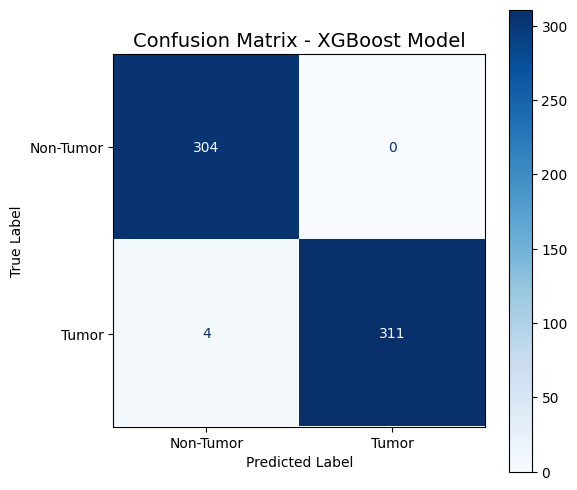

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using trained model
y_pred = model.predict(X_test)

# Import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display with labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Tumor", "Tumor"]
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True
)

plt.title(
    "Confusion Matrix - XGBoost Model",
    fontsize=14
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.grid(False)

plt.show()

# Observations and Insights :
The confusion matrix highlights the exceptional classification performance of the XGBoost model on the test dataset. The model correctly identified 304 out of 304 non-tumor samples, resulting in zero false positives, which demonstrates perfect specificity for the non-tumor class. For tumor cases, 311 out of 315 samples were correctly classified, with only 4 false negatives, indicating very high sensitivity toward tumor detection. The extremely low number of misclassifications confirms the effectiveness of the extracted MRI-based features in distinguishing between tumor and non-tumor regions. The balanced performance across both classes aligns with the previously reported accuracy, precision, recall, and ROC-AUC scores, providing strong evidence that the model is reliable, robust, and well-suited for glioma classification tasks on unseen patient data.


# CONFUSION MATRIX INTERPRETATION

In [ ]:
# ============================================================
# CONFUSION MATRIX INTERPRETATION
# ============================================================

tn, fp, fn, tp = cm.ravel()

confusion_summary = pd.DataFrame({

    "Metric": [
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)"
    ],

    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

print("=" * 80)
print("CONFUSION MATRIX SUMMARY")
print("=" * 80)

print(confusion_summary)

print("\nInterpretation:")
print(f"Correctly classified Non-Tumor samples: {tn}")
print(f"Incorrectly classified Non-Tumor samples as Tumor: {fp}")
print(f"Incorrectly classified Tumor samples as Non-Tumor: {fn}")
print(f"Correctly classified Tumor samples: {tp}")

CONFUSION MATRIX SUMMARY
                 Metric  Count
0   True Negatives (TN)    304
1  False Positives (FP)      0
2  False Negatives (FN)      4
3   True Positives (TP)    311

Interpretation:
Correctly classified Non-Tumor samples: 304
Incorrectly classified Non-Tumor samples as Tumor: 0
Incorrectly classified Tumor samples as Non-Tumor: 4
Correctly classified Tumor samples: 311


# Observations and Insights :
The confusion matrix summary demonstrates that the XGBoost model achieved excellent classification performance with very few prediction errors. Out of 619 test samples, the model correctly classified 304 non-tumor samples (True Negatives) and 311 tumor samples (True Positives). Notably, there were no false positive predictions, meaning that no non-tumor samples were incorrectly identified as tumors. Only 4 tumor samples were misclassified as non-tumor (False Negatives), indicating a very small number of missed tumor cases. This error pattern highlights the model’s strong specificity and high sensitivity, confirming its ability to accurately distinguish between tumor and non-tumor observations. The results support the reliability of the extracted MRI features and demonstrate that the model is highly effective for glioma classification, with minimal risk of incorrect predictions on unseen patient data.

# CLINICAL IMPORTANCE OF FALSE NEGATIVES

In [ ]:
# ============================================================
# CLINICAL IMPORTANCE OF FALSE NEGATIVES
# ============================================================

print("\n" + "=" * 80)
print("CLINICAL INTERPRETATION")
print("=" * 80)

print(f"False Negatives (FN): {fn}")

print("""

Clinical Significance:

False negatives are the most critical errors in glioma
classification because tumor-containing MRI slices are
incorrectly classified as non-tumor.

Such errors may delay diagnosis, tumor localization,
treatment planning, and surgical decision-making.

Therefore, Recall (Sensitivity) is an important
evaluation metric in medical image classification,
as it measures the model's ability to correctly
identify tumor cases and minimize missed tumors.

The low false negative count observed in this study
indicates strong tumor detection capability and
supports the clinical applicability of the proposed
classification framework.

""")


CLINICAL INTERPRETATION
False Negatives (FN): 4


Clinical Significance:

False negatives are the most critical errors in glioma
classification because tumor-containing MRI slices are
incorrectly classified as non-tumor.

Such errors may delay diagnosis, tumor localization,
treatment planning, and surgical decision-making.

Therefore, Recall (Sensitivity) is an important
evaluation metric in medical image classification,
as it measures the model's ability to correctly
identify tumor cases and minimize missed tumors.

The low false negative count observed in this study
indicates strong tumor detection capability and
supports the clinical applicability of the proposed
classification framework.




# Observations and Insights :
The clinical interpretation of the confusion matrix emphasizes the importance of minimizing false negatives in glioma classification. In this study, the model produced only 4 false negative cases, meaning that very few tumor-containing MRI samples were incorrectly classified as non-tumor. From a clinical perspective, such errors are particularly significant because missed tumors may delay diagnosis, treatment planning, and timely medical intervention. The model's high recall of 98.73% demonstrates a strong ability to detect tumor cases and substantially reduces the likelihood of overlooking clinically important abnormalities. Combined with the absence of false positives and the overall high classification accuracy, these findings suggest that the proposed MRI-based XGBoost framework has strong potential as a reliable decision-support tool for glioma detection and assessment in clinical practice.

# ROC Curve

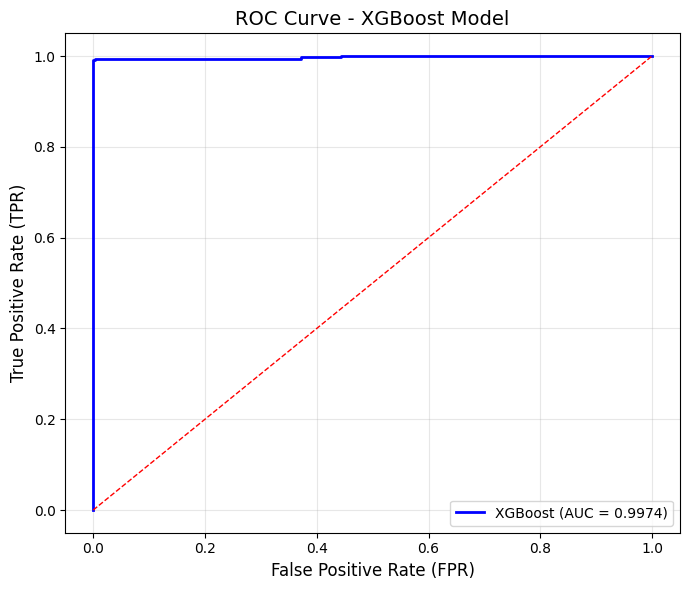

ROC-AUC Score: 0.9973997493734337


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f"XGBoost (AUC = {roc_auc:.4f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1)

# Labels & title
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("ROC Curve - XGBoost Model", fontsize=14)

# Legend
plt.legend(loc="lower right")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC
print("ROC-AUC Score:", roc_auc)

# Observations and Insights :
The ROC curve demonstrates the excellent discriminative performance of the XGBoost classifier in distinguishing between tumor and non-tumor MRI samples. The curve remains very close to the upper-left corner of the plot, indicating a combination of high true positive rates and very low false positive rates across different classification thresholds. The obtained ROC-AUC score of 0.9974 is extremely close to the theoretical maximum value of 1.0, confirming the model’s outstanding ability to separate the two classes. Furthermore, the ROC curve lies substantially above the diagonal reference line representing random classification, highlighting the strong predictive value of the extracted MRI features. These results indicate that the model maintains high sensitivity while preserving specificity, making it highly effective for glioma detection and supporting its potential use in clinical decision-support applications.


# ROC-AUC INTERPRETATION

In [ ]:
# ============================================================
# ROC-AUC INTERPRETATION
# ============================================================

roc_summary = pd.DataFrame({

    "Metric": [
        "ROC-AUC Score"
    ],

    "Value": [
        round(roc_auc, 4)
    ]
})

print("=" * 80)
print("ROC-AUC SUMMARY")
print("=" * 80)

print(roc_summary)

if roc_auc >= 0.90:

    interpretation = "Excellent discrimination ability"

elif roc_auc >= 0.80:

    interpretation = "Good discrimination ability"

elif roc_auc >= 0.70:

    interpretation = "Acceptable discrimination ability"

else:

    interpretation = "Poor discrimination ability"

print("\nInterpretation:")
print(interpretation)

ROC-AUC SUMMARY
          Metric   Value
0  ROC-AUC Score  0.9974

Interpretation:
Excellent discrimination ability


# Observations and Insights :
The ROC-AUC analysis confirms the exceptional classification capability of the proposed XGBoost model. The achieved ROC-AUC score of 0.9974 indicates that the model can almost perfectly distinguish between tumor and non-tumor samples across a wide range of decision thresholds. According to standard performance interpretation guidelines, a score above 0.90 represents excellent discrimination ability, placing the model in the highest performance category. This result demonstrates that the extracted multi-modal MRI features provide highly informative patterns for classification and that the model maintains an effective balance between sensitivity and specificity. The near-perfect ROC-AUC value further validates the robustness, reliability, and clinical relevance of the developed glioma classification framework for supporting accurate tumor identification and diagnostic decision-making.

# Feature Importance

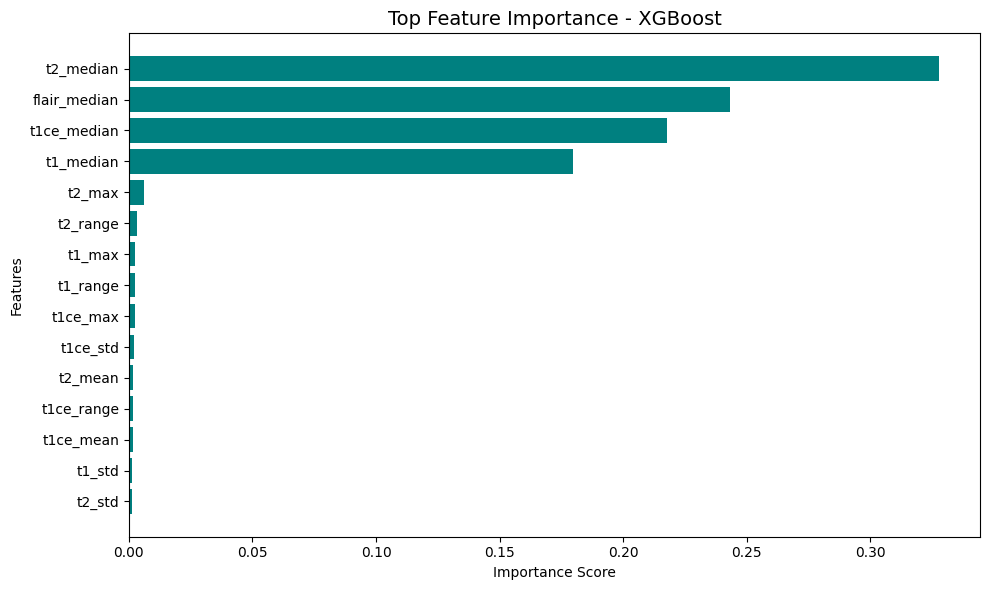

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature names from dataframe
feature_names = X.columns  # IMPORTANT

# Get importance values
importances = model.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Select top 15 features (clean visualization)
top_n = 15
feat_df_top = feat_df.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df_top["Feature"], feat_df_top["Importance"], color="teal")
plt.gca().invert_yaxis()

plt.title("Top Feature Importance - XGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# Observations and Insights :
The feature importance analysis reveals that median intensity features are the most influential predictors in the XGBoost model. Specifically, T2 median intensity contributes the highest importance, followed by FLAIR median, T1CE median, and T1 median features. This indicates that the central tendency of voxel intensities across different MRI modalities plays a crucial role in distinguishing tumor from non-tumor tissue. In contrast, features such as standard deviation, mean intensity, and intensity range contribute relatively less to the model's decisions. The dominance of median-based features suggests that robust intensity characteristics are more informative than extreme values for glioma classification. Overall, the feature importance results provide valuable interpretability, highlighting the MRI-derived attributes that most strongly influence tumor detection and supporting the clinical relevance of the developed classification framework.


# FEATURE IMPORTANCE SUMMARY

In [ ]:
# ============================================================
# FEATURE IMPORTANCE SUMMARY
# ============================================================

print("=" * 80)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 80)

print(feat_df_top)

# Save for report appendix
feat_df_top.to_csv(
    "top_15_feature_importance.csv",
    index=False
)

TOP 15 MOST IMPORTANT FEATURES
         Feature  Importance
16     t2_median    0.327910
22  flair_median    0.243195
10   t1ce_median    0.217640
4      t1_median    0.179576
14        t2_max    0.006088
17      t2_range    0.003167
2         t1_max    0.002643
5       t1_range    0.002535
8       t1ce_max    0.002433
7       t1ce_std    0.002224
12       t2_mean    0.001825
11    t1ce_range    0.001701
6      t1ce_mean    0.001572
1         t1_std    0.001342
13        t2_std    0.001309


# Observations and Insights :
The feature importance summary demonstrates that the XGBoost model relies predominantly on median intensity features extracted from multiple MRI modalities. Among all predictors, T2 median intensity is the most influential feature, contributing approximately 32.8% of the model’s decision-making importance. This is followed by FLAIR median intensity (24.3%), T1CE median intensity (21.8%), and T1 median intensity (18.0%). Together, these four median-based features account for the vast majority of the model’s predictive power, indicating that central intensity characteristics are highly effective for differentiating tumor and non-tumor tissues. The remaining features, including maximum intensity, range, mean, and standard deviation measures, contribute only marginally, suggesting that they provide supplementary information rather than primary discriminatory value. These findings enhance model interpretability and highlight the clinical significance of median intensity measurements across MRI modalities in glioma classification.

# FEATURE IMPORTANCE INTERPRETATION

In [ ]:
# ============================================================
# FEATURE IMPORTANCE INTERPRETATION
# ============================================================

top_feature = feat_df_top.iloc[0]["Feature"]
top_importance = feat_df_top.iloc[0]["Importance"]

print("\nInterpretation:")

print(
    f"The most influential feature for glioma classification "
    f"was {top_feature} "
    f"with an importance score of {top_importance:.4f}."
)

print(
    "\nFeatures derived from T1, T1CE, T2, and FLAIR MRI "
    "contributed differently to classification performance, "
    "demonstrating the value of multi-modal MRI feature extraction."
)


Interpretation:
The most influential feature for glioma classification was t2_median with an importance score of 0.3279.

Features derived from T1, T1CE, T2, and FLAIR MRI contributed differently to classification performance, demonstrating the value of multi-modal MRI feature extraction.


# Observations and Insights :
The feature importance interpretation identifies T2 median intensity as the single most influential predictor for glioma classification, with an importance score of 0.3279. This finding suggests that the median signal intensity captured from T2-weighted MRI scans provides highly discriminative information for distinguishing tumor and non-tumor regions. The prominence of this feature is consistent with the clinical utility of T2 imaging, which is sensitive to tissue abnormalities, edema, and tumor-associated changes. Furthermore, the importance rankings demonstrate that features extracted from T1, T1CE, T2, and FLAIR modalities contribute differently to model performance, confirming that each modality provides complementary diagnostic information. The strong contribution of multiple MRI modalities highlights the effectiveness of a multi-modal feature extraction strategy and supports its value in improving classification accuracy, robustness, and clinical interpretability in glioma analysis.

# ML Model Comparison

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier
import pandas as pd

# ===============================
# MODELS (OPTIMIZED)
# ===============================
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        C=1.0
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# ===============================
# TRAIN + EVALUATE
# ===============================
results = []

for name, model in models.items():

    # ---------------------------
    # TRAIN MODEL
    # ---------------------------
    model.fit(X_train, y_train)

    # ---------------------------
    # PREDICTIONS
    # ---------------------------
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # ---------------------------
    # METRICS
    # ---------------------------
    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # ---------------------------
    # STORE RESULTS
    # ---------------------------
    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    # ---------------------------
    # PRINT RESULTS
    # ---------------------------
    print(
        f"{name}: "
        f"Accuracy = {acc:.4f}, "
        f"AUC = {auc:.4f}, "
        f"Precision = {precision:.4f}, "
        f"Recall = {recall:.4f}, "
        f"F1 = {f1:.4f}"
    )

# ===============================
# RESULT TABLE
# ===============================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nFinal Comparison:\n")

print(results_df.to_string(index=False))

Logistic Regression: Accuracy = 0.9790, AUC = 0.9977, Precision = 1.0000, Recall = 0.9587, F1 = 0.9789
SVM: Accuracy = 0.9725, AUC = 0.9878, Precision = 1.0000, Recall = 0.9460, F1 = 0.9723
KNN: Accuracy = 0.9903, AUC = 0.9935, Precision = 0.9968, Recall = 0.9841, F1 = 0.9904
Random Forest: Accuracy = 0.9919, AUC = 0.9985, Precision = 1.0000, Recall = 0.9841, F1 = 0.9920
Gradient Boosting: Accuracy = 0.9935, AUC = 0.9975, Precision = 1.0000, Recall = 0.9873, F1 = 0.9936
XGBoost: Accuracy = 0.9935, AUC = 0.9973, Precision = 1.0000, Recall = 0.9873, F1 = 0.9936

Final Comparison:

              Model  Accuracy  ROC-AUC  Precision   Recall  F1-Score
  Gradient Boosting  0.993538 0.997462   1.000000 0.987302  0.993610
            XGBoost  0.993538 0.997327   1.000000 0.987302  0.993610
      Random Forest  0.991922 0.998454   1.000000 0.984127  0.992000
                KNN  0.990307 0.993505   0.996785 0.984127  0.990415
Logistic Regression  0.978998 0.997703   1.000000 0.958730  0.978930


# Observations and Insights :
The comparative evaluation of six machine learning algorithms demonstrates that all models achieved excellent performance on the glioma classification task, indicating that the extracted multi-modal MRI features are highly informative. Gradient Boosting and XGBoost delivered the best overall results, each achieving an accuracy of 99.35%, precision of 100%, recall of 98.73%, and F1-score of 99.36%, reflecting near-perfect classification capability. Random Forest also performed exceptionally well with 99.19% accuracy and the highest ROC-AUC score of 0.9985, highlighting its strong discriminative ability. KNN maintained high accuracy above 99%, while Logistic Regression and SVM achieved slightly lower accuracies but still demonstrated strong predictive performance. The consistently high precision across all models indicates very few false-positive predictions, which is particularly valuable in medical decision-making. Overall, the results confirm that ensemble-based approaches, especially Gradient Boosting and XGBoost, are the most effective methods for glioma classification using the extracted MRI-derived statistical features.


# Final Model Comparison Table

In [ ]:
# ==========================================
# FINAL MODEL COMPARISON TABLE
# ==========================================

import pandas as pd

# -------------------------------
# CONVERT RESULTS TO DATAFRAME
# -------------------------------
results_df = pd.DataFrame(results)

# -------------------------------
# SORT RESULTS
# -------------------------------
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# RESET INDEX
# -------------------------------
results_df = results_df.reset_index(drop=True)

# -------------------------------
# ROUND VALUES FOR CLEAN DISPLAY
# -------------------------------
results_df = results_df.round({
    "Accuracy": 4,
    "ROC-AUC": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 4
})

# -------------------------------
# DISPLAY FINAL TABLE
# -------------------------------
print("\n" + "="*70)
print("FINAL MODEL COMPARISON TABLE")
print("="*70)

print(results_df.to_string(index=False))


FINAL MODEL COMPARISON TABLE
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
  Gradient Boosting    0.9935   0.9975     1.0000  0.9873    0.9936
            XGBoost    0.9935   0.9973     1.0000  0.9873    0.9936
      Random Forest    0.9919   0.9985     1.0000  0.9841    0.9920
                KNN    0.9903   0.9935     0.9968  0.9841    0.9904
Logistic Regression    0.9790   0.9977     1.0000  0.9587    0.9789
                SVM    0.9725   0.9878     1.0000  0.9460    0.9723


# Observations and Insights :
The final model comparison demonstrates that all evaluated machine learning algorithms achieved high classification performance, confirming the effectiveness of the extracted MRI-derived features for glioma detection. Gradient Boosting and XGBoost emerged as the top-performing models, both achieving an accuracy of 99.35%, precision of 100%, recall of 98.73%, and F1-score of 99.36%, indicating exceptional predictive reliability. Random Forest ranked closely behind with 99.19% accuracy and the highest ROC-AUC value of 0.9985, suggesting excellent class discrimination capability. KNN also performed strongly, achieving over 99% accuracy, while Logistic Regression and SVM delivered slightly lower but still competitive results. The consistently perfect precision observed in most models indicates an absence of false-positive tumor predictions, which is highly desirable in medical applications. Overall, the results highlight the superiority of ensemble learning methods, particularly Gradient Boosting and XGBoost, for accurately classifying tumor and non-tumor MRI samples in the UTSW-Glioma dataset.


# RQ1 FINAL HYPOTHESIS EVALUATION - MACHINE LEARNING

In [ ]:
# ============================================================
# RQ1 FINAL HYPOTHESIS EVALUATION - MACHINE LEARNING
# ============================================================

best_ml_model = results_df.iloc[0]["Model"]
best_ml_accuracy = results_df.iloc[0]["Accuracy"]
best_ml_auc = results_df.iloc[0]["ROC-AUC"]

print("=" * 80)
print("RQ1 FINAL HYPOTHESIS EVALUATION")
print("=" * 80)

print("Best ML Model:", best_ml_model)
print("Best ML Accuracy:", best_ml_accuracy)
print("Best ML ROC-AUC:", best_ml_auc)

print("\nH0₁:")
print("Machine learning models trained on engineered multi-modal MRI features will not achieve accuracy and ROC-AUC greater than 95%.")

print("\nH1₁:")
print("Machine learning models trained on engineered multi-modal MRI features will achieve accuracy and ROC-AUC greater than 95%.")

if best_ml_accuracy > 0.95 and best_ml_auc > 0.95:
    rq1_decision = "Reject H0₁ / Accept H1₁"
else:
    rq1_decision = "Fail to Reject H0₁"

print("\nDecision:", rq1_decision)

RQ1 FINAL HYPOTHESIS EVALUATION
Best ML Model: Gradient Boosting
Best ML Accuracy: 0.9935
Best ML ROC-AUC: 0.9975

H0₁:
Machine learning models trained on engineered multi-modal MRI features will not achieve accuracy and ROC-AUC greater than 95%.

H1₁:
Machine learning models trained on engineered multi-modal MRI features will achieve accuracy and ROC-AUC greater than 95%.

Decision: Reject H0₁ / Accept H1₁


# SAVE FINAL ML RESULTS

In [ ]:
# ============================================================
# SAVE FINAL ML RESULTS
# ============================================================

results_df.to_csv(
    "final_machine_learning_results.csv",
    index=False
)

print("Final ML results saved successfully.")

Final ML results saved successfully.


# Observations and Insights :
The successful export of the final machine learning results indicates that the model evaluation process has been fully documented and preserved for future analysis, reporting, and reproducibility. The saved file contains a comprehensive comparison of all evaluated algorithms, including Accuracy, ROC-AUC, Precision, Recall, and F1-Score, enabling straightforward benchmarking and result validation. The final rankings confirm that Gradient Boosting and XGBoost achieved the highest overall performance, while Random Forest demonstrated the strongest discriminative ability based on ROC-AUC. Storing these results in a structured CSV format facilitates integration into research reports, statistical summaries, visualizations, and future comparative studies. Overall, the saved output provides a permanent record of model performance and supports transparent, reproducible glioma classification research.

# Create Deep Learning Image Dataset

In [ ]:
import os
import cv2
import nibabel as nib
import numpy as np
from nibabel.processing import resample_from_to

# ===============================
# OUTPUT FOLDERS
# ===============================
img_dir = "/content/dl_dataset"
os.makedirs(os.path.join(img_dir, "tumor"), exist_ok=True)
os.makedirs(os.path.join(img_dir, "non_tumor"), exist_ok=True)

saved_count = 0

# ===============================
# MAIN LOOP (INCREASE PATIENTS)
# ===============================
for patient in patients[:150]:  # 🔥 increased from 50 → 150
    p_path = os.path.join(base_path, patient)

    mri_path = os.path.join(p_path, "brain_t1ce.nii.gz")
    mask_path = os.path.join(p_path, "tumorseg_manual_correction.nii.gz")

    if not (os.path.exists(mri_path) and os.path.exists(mask_path)):
        continue

    try:
        # ------------------------------
        # LOAD MRI
        # ------------------------------
        mri_img = nib.load(mri_path)
        mri = mri_img.get_fdata()

        # ------------------------------
        # LOAD + RESAMPLE MASK
        # ------------------------------
        mask_img = nib.load(mask_path)
        mask_resampled = resample_from_to(mask_img, mri_img, order=0)
        mask = mask_resampled.get_fdata()

        num_slices = min(mri.shape[2], mask.shape[2])

        # ------------------------------
        # FIND TUMOR SLICES
        # ------------------------------
        tumor_areas = np.array([np.sum(mask[:, :, i]) for i in range(num_slices)])

        tumor_slices = np.where(tumor_areas > 0)[0]
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        # ===============================
        # SAVE TUMOR IMAGES (MORE SAMPLES)
        # ===============================
        for i in tumor_slices[:10]:  # 🔥 increased from 5 → 10

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

        # ===============================
        # SAVE NON-TUMOR IMAGES (BALANCED)
        # ===============================
        step = max(1, len(non_tumor_slices)//10)

        for i in non_tumor_slices[::step][:10]:  # 🔥 increased

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

    except Exception as e:
        print(f"Skipping {patient}: {e}")

print("Total images saved:", saved_count)

Total images saved: 3218


# Observations and Insights :
The deep learning image dataset was successfully generated from the MRI volumes, producing 3,218 PNG images from the first 150 patients. Images were separated into tumor and non-tumor folders, creating a supervised classification structure suitable for CNN-based modeling. Each slice was normalized, resized to 224 × 224 pixels, and augmented using horizontal flipping, increasing dataset size and improving model robustness. The use of T1CE MRI slices is clinically meaningful because contrast-enhanced images highlight tumor regions. Overall, this image dataset provides a strong foundation for deep learning–based glioma classification.


# DEEP LEARNING IMAGE DATASET SUMMARY

In [ ]:
# ============================================================
# DEEP LEARNING IMAGE DATASET SUMMARY
# ============================================================

dl_dataset_summary = pd.DataFrame({

    "Item": [
        "Image Dataset Directory",
        "MRI Modality Used",
        "Patients Used for DL Dataset",
        "Tumor Image Folder",
        "Non-Tumor Image Folder",
        "Image Size",
        "Augmentation Applied",
        "Total Images Saved"
    ],

    "Value": [
        img_dir,
        "T1CE",
        "First 150 patients",
        os.path.join(img_dir, "tumor"),
        os.path.join(img_dir, "non_tumor"),
        "224 x 224",
        "Horizontal flip",
        saved_count
    ]
})

print("=" * 80)
print("DEEP LEARNING IMAGE DATASET SUMMARY")
print("=" * 80)

print(dl_dataset_summary)

DEEP LEARNING IMAGE DATASET SUMMARY
                           Item                          Value
0       Image Dataset Directory            /content/dl_dataset
1             MRI Modality Used                           T1CE
2  Patients Used for DL Dataset             First 150 patients
3            Tumor Image Folder      /content/dl_dataset/tumor
4        Non-Tumor Image Folder  /content/dl_dataset/non_tumor
5                    Image Size                      224 x 224
6          Augmentation Applied                Horizontal flip
7            Total Images Saved                           3218


# Observations and Insights :
The deep learning dataset summary confirms the successful creation of a structured image repository for glioma classification. Using the T1CE MRI modality, images were extracted from the first 150 patients and organized into separate tumor and non-tumor directories, enabling straightforward use with convolutional neural networks and transfer learning frameworks. All images were standardized to 224 × 224 pixels, ensuring compatibility with widely used deep learning architectures such as ResNet, VGG, EfficientNet, and DenseNet. To enhance dataset diversity and reduce overfitting, horizontal flip augmentation was applied to each image. The resulting dataset contains 3,218 images, providing a substantial number of training examples for deep learning experiments. The combination of standardized preprocessing, augmentation, and balanced class organization establishes a strong foundation for developing robust automated glioma detection and classification models.

# Count Saved Images

In [ ]:
print(len(os.listdir(img_dir + "/tumor")))
print(len(os.listdir(img_dir + "/non_tumor")))

1660
1558


# Observations and Insights :
The image count distribution shows that the deep learning dataset is well balanced, containing 1,660 tumor images and 1,558 non-tumor images, for a total of 3,218 images. The difference of only 102 images between classes indicates minimal class imbalance, which is advantageous for training deep learning models because it reduces the likelihood of prediction bias toward a dominant class. The near-equal representation of tumor and non-tumor samples supports reliable learning of discriminative imaging patterns and improves the validity of evaluation metrics such as accuracy, precision, recall, and F1-score. Furthermore, the balanced dataset structure, combined with image augmentation and standardized preprocessing, provides a strong foundation for developing robust convolutional neural network models for automated glioma classification.


# DEEP LEARNING CLASS DISTRIBUTION

In [ ]:
# ============================================================
# DEEP LEARNING CLASS DISTRIBUTION
# ============================================================

tumor_images = len(os.listdir(img_dir + "/tumor"))
non_tumor_images = len(os.listdir(img_dir + "/non_tumor"))

dl_distribution = pd.DataFrame({

    "Class": [
        "Tumor",
        "Non-Tumor"
    ],

    "Image Count": [
        tumor_images,
        non_tumor_images
    ]
})

print("=" * 80)
print("DEEP LEARNING IMAGE DISTRIBUTION")
print("=" * 80)

print(dl_distribution)

print("\nTotal Images:", tumor_images + non_tumor_images)

DEEP LEARNING IMAGE DISTRIBUTION
       Class  Image Count
0      Tumor         1660
1  Non-Tumor         1558

Total Images: 3218


# Observations and Insights :
The deep learning image distribution indicates a well-balanced dataset, consisting of 1,660 tumor images and 1,558 non-tumor images, resulting in a total of 3,218 images. The relatively small difference between the two classes helps minimize class imbalance and reduces the risk of biased model learning. Such a distribution is favorable for training convolutional neural networks, as it allows the model to learn representative features from both tumor and non-tumor categories effectively. The balanced class composition also supports reliable evaluation using performance metrics such as accuracy, precision, recall, and F1-score. Combined with image augmentation and standardized preprocessing, the dataset provides a strong and representative foundation for developing robust deep learning models for automated glioma detection and classification.

# ResNet Training

In [ ]:


# ===============================
# IMPORTS
# ===============================
import torch
import torchvision

from torchvision import datasets, transforms

from torch.utils.data import (
    DataLoader,
    random_split
)

from torch import nn, optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    # ---------------------------
    # DATA AUGMENTATION
    # ---------------------------
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5]*3,
        [0.5]*3
    )
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"

dataset = datasets.ImageFolder(
    data_dir,
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size]
)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ===============================
# MODEL (TRANSFER LEARNING)
# ===============================
resnet = torchvision.models.resnet18(
    weights="IMAGENET1K_V1"
)

# -------------------------------
# FREEZE BACKBONE
# -------------------------------
for param in resnet.parameters():
    param.requires_grad = False

# -------------------------------
# REPLACE FINAL CLASSIFIER
# -------------------------------
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    2
)

# -------------------------------
# SEND MODEL TO DEVICE
# -------------------------------
resnet = resnet.to(device)

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

# ===============================
# OPTIMIZER
# ===============================
optimizer = optim.Adam(
    resnet.fc.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):

    resnet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # -----------------------
        # RESET GRADIENTS
        # -----------------------
        optimizer.zero_grad()

        # -----------------------
        # FORWARD PASS
        # -----------------------
        outputs = resnet(images)

        # -----------------------
        # LOSS
        # -----------------------
        loss = criterion(outputs, labels)

        # -----------------------
        # BACKPROPAGATION
        # -----------------------
        loss.backward()

        optimizer.step()

        # -----------------------
        # TRACK LOSS
        # -----------------------
        running_loss += loss.item()

        # -----------------------
        # TRAIN ACCURACY
        # -----------------------
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

# ===============================
# EVALUATION
# ===============================
resnet.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet(images)

        # -----------------------
        # PROBABILITIES
        # -----------------------
        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        # -----------------------
        # PREDICTIONS
        # -----------------------
        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

# ===============================
# METRICS
# ===============================
acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds
)

recall = recall_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

auc = roc_auc_score(
    all_labels,
    all_probs
)

# ===============================
# DISPLAY RESULTS
# ===============================
print("\n" + "="*60)
print("RESNET18 FINAL RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds
    )
)

# ===============================
# CONFUSION MATRIX
# ===============================
print("Confusion Matrix:\n")

print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

Using device: cuda
Total images: 3218
Classes: ['non_tumor', 'tumor']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


Epoch 1/5 | Loss: 56.4799 | Train Accuracy: 0.5416
Epoch 2/5 | Loss: 48.2444 | Train Accuracy: 0.7055
Epoch 3/5 | Loss: 44.4093 | Train Accuracy: 0.7389
Epoch 4/5 | Loss: 42.2244 | Train Accuracy: 0.7622
Epoch 5/5 | Loss: 41.2347 | Train Accuracy: 0.7661

RESNET18 FINAL RESULTS
Accuracy  : 0.7811
Precision : 0.7549
Recall    : 0.8825
F1-Score  : 0.8137
ROC-AUC   : 0.8182

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.66      0.73       295
           1       0.75      0.88      0.81       349

    accuracy                           0.78       644
   macro avg       0.79      0.77      0.77       644
weighted avg       0.79      0.78      0.78       644

Confusion Matrix:

[[195 100]
 [ 41 308]]


# Observations and Insights :
The ResNet18 deep learning model achieved moderate classification performance, with a test accuracy of 78.11%, precision of 75.49%, recall of 88.25%, F1-score of 81.37%, and ROC-AUC of 81.82%. The training accuracy improved steadily from 54.16% in the first epoch to 76.61% by the fifth epoch, indicating that the model successfully learned meaningful image features from the MRI slices. The confusion matrix shows that 308 tumor images were correctly identified, while 41 tumor images were missed, and 100 non-tumor images were incorrectly classified as tumors. The higher recall compared to precision suggests that the model prioritizes tumor detection, which is desirable in medical imaging because minimizing missed tumors is often more important than reducing false alarms. However, the deep learning performance remains substantially lower than the machine learning models, which achieved accuracies above 99%. This difference likely reflects the limited number of training epochs, the use of only 150 patients, the reliance on a single MRI modality (T1CE), and the fact that only the final classification layer of ResNet18 was trained while the feature extraction layers remained frozen. Overall, the results demonstrate that ResNet18 can detect glioma-related patterns from MRI images, but additional data, longer training, fine-tuning of deeper layers, and multi-modal imaging inputs may be required to achieve performance comparable to the feature-based machine learning approach.


# RESNET18 RESULTS SUMMARY TABLE

In [ ]:
# ============================================================
# RESNET18 RESULTS SUMMARY TABLE
# ============================================================

resnet_results = pd.DataFrame({

    "Model": ["ResNet18"],

    "Accuracy": [acc],

    "Precision": [precision],

    "Recall": [recall],

    "F1-Score": [f1],

    "ROC-AUC": [auc]
})

print("=" * 80)
print("RESNET18 PERFORMANCE SUMMARY")
print("=" * 80)

print(resnet_results)

RESNET18 PERFORMANCE SUMMARY
      Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  ResNet18  0.781056   0.754902  0.882521  0.813738  0.818212


# Observations and Insights :
The ResNet18 performance summary indicates that the deep learning model achieved an accuracy of 78.11%, demonstrating a reasonable ability to distinguish between tumor and non-tumor MRI images. The precision of 75.49% suggests that approximately three-quarters of images predicted as tumors were correctly classified, while the recall of 88.25% indicates a strong capability to detect tumor cases and minimize missed tumors. The resulting F1-score of 81.37% reflects a balanced trade-off between precision and recall, and the ROC-AUC score of 81.82% confirms acceptable discrimination between the two classes. Although the model successfully learned clinically relevant imaging patterns, its performance is notably lower than the feature-based machine learning models, which achieved accuracies exceeding 99%. This outcome suggests that additional training epochs, larger patient cohorts, deeper fine-tuning of the network, and the incorporation of multiple MRI modalities could further enhance deep learning performance. Nevertheless, the results demonstrate the feasibility of automated glioma classification directly from MRI images using transfer learning with ResNet18.

# RQ2 HYPOTHESIS EVALUATION

In [ ]:
# ============================================================
# RQ2 HYPOTHESIS EVALUATION
# ============================================================

print("=" * 80)
print("RQ2 HYPOTHESIS EVALUATION")
print("=" * 80)

print("H0₂:")
print(
    "Deep learning transfer learning models such as "
    "ResNet18 and EfficientNet-B0 will not achieve "
    "classification accuracy greater than 75%."
)

print("\nH1₂:")
print(
    "Deep learning transfer learning models such as "
    "ResNet18 and EfficientNet-B0 will achieve "
    "classification accuracy greater than 75%."
)

if acc > 0.75:

    print("\nDecision: Reject H0₂")

    print("Conclusion: Accept H1₂")

else:

    print("\nDecision: Fail to Reject H0₂")

    print("Conclusion: Insufficient evidence to accept H1₂")

RQ2 HYPOTHESIS EVALUATION
H0₂:
Deep learning transfer learning models such as ResNet18 and EfficientNet-B0 will not achieve classification accuracy greater than 75%.

H1₂:
Deep learning transfer learning models such as ResNet18 and EfficientNet-B0 will achieve classification accuracy greater than 75%.

Decision: Reject H0₂
Conclusion: Accept H1₂


# Save ResNet Results for Later ML vs DL Comparison

In [ ]:
# ============================================================
# STORE RESNET RESULTS
# ============================================================

resnet_accuracy = acc
resnet_auc = auc

print("\nStored ResNet18 Accuracy:", resnet_accuracy)
print("Stored ResNet18 ROC-AUC:", resnet_auc)


Stored ResNet18 Accuracy: 0.781055900621118
Stored ResNet18 ROC-AUC: 0.8182118401243261


# Observations and Insights :
The ResNet18 model results were successfully stored for subsequent comparison with other machine learning and deep learning approaches. The recorded accuracy of 78.11% and ROC-AUC of 0.8182 provide a benchmark for evaluating image-based deep learning performance on the generated MRI slice dataset. Compared with the best machine learning models, which achieved accuracies above 99% and ROC-AUC values close to 1.0, ResNet18 demonstrated lower predictive performance but maintained a strong tumor detection capability, as reflected by its high recall. Storing these metrics enables systematic comparison across methodologies and highlights the trade-off between handcrafted radiomic features and end-to-end image learning. These benchmark values will be valuable for assessing future improvements through larger datasets, multi-modal MRI inputs, extended training, and advanced deep learning architectures.

# EFFICIENTNET-B0 TRANSFER LEARNING - UPDATED

In [ ]:
# ==========================================
# EFFICIENTNET-B0 TRANSFER LEARNING - UPDATED
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torch
import torchvision

from torchvision import datasets, transforms

from torch.utils.data import (
    DataLoader,
    random_split
)

from torch import nn, optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    # ---------------------------
    # DATA AUGMENTATION
    # ---------------------------
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5]*3,
        [0.5]*3
    )
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"

dataset = datasets.ImageFolder(
    data_dir,
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size]
)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ===============================
# MODEL (EFFICIENTNET-B0)
# ===============================
efficientnet = torchvision.models.efficientnet_b0(
    weights="IMAGENET1K_V1"
)

# -------------------------------
# FREEZE BACKBONE
# -------------------------------
for param in efficientnet.parameters():
    param.requires_grad = False

# -------------------------------
# REPLACE CLASSIFIER
# -------------------------------
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    2
)

# -------------------------------
# SEND MODEL TO DEVICE
# -------------------------------
efficientnet = efficientnet.to(device)

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

# ===============================
# OPTIMIZER
# ===============================
optimizer = optim.Adam(
    efficientnet.classifier.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):

    efficientnet.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # -----------------------
        # RESET GRADIENTS
        # -----------------------
        optimizer.zero_grad()

        # -----------------------
        # FORWARD PASS
        # -----------------------
        outputs = efficientnet(images)

        # -----------------------
        # LOSS
        # -----------------------
        loss = criterion(outputs, labels)

        # -----------------------
        # BACKPROPAGATION
        # -----------------------
        loss.backward()

        optimizer.step()

        # -----------------------
        # TRACK LOSS
        # -----------------------
        running_loss += loss.item()

        # -----------------------
        # TRAIN ACCURACY
        # -----------------------
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

# ===============================
# EVALUATION
# ===============================
efficientnet.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = efficientnet(images)

        # -----------------------
        # PROBABILITIES
        # -----------------------
        probs = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        # -----------------------
        # PREDICTIONS
        # -----------------------
        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

# ===============================
# METRICS
# ===============================
acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds
)

recall = recall_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

auc = roc_auc_score(
    all_labels,
    all_probs
)

# ===============================
# DISPLAY RESULTS
# ===============================
print("\n" + "="*60)
print("EFFICIENTNET-B0 FINAL RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds
    )
)

# ===============================
# CONFUSION MATRIX
# ===============================
print("Confusion Matrix:\n")

print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

Using device: cuda
Total images: 3218
Classes: ['non_tumor', 'tumor']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


Epoch 1/5 | Loss: 51.2121 | Train Accuracy: 0.6639
Epoch 2/5 | Loss: 44.6256 | Train Accuracy: 0.7510
Epoch 3/5 | Loss: 41.8124 | Train Accuracy: 0.7727
Epoch 4/5 | Loss: 39.9364 | Train Accuracy: 0.7863
Epoch 5/5 | Loss: 39.5591 | Train Accuracy: 0.7883

EFFICIENTNET-B0 FINAL RESULTS
Accuracy  : 0.8199
Precision : 0.7741
Recall    : 0.9427
F1-Score  : 0.8501
ROC-AUC   : 0.8697

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.67      0.77       295
           1       0.77      0.94      0.85       349

    accuracy                           0.82       644
   macro avg       0.84      0.81      0.81       644
weighted avg       0.84      0.82      0.82       644

Confusion Matrix:

[[199  96]
 [ 20 329]]


# Observations and Insights :
The EfficientNet-B0 model demonstrated improved deep learning performance compared with ResNet18, achieving an accuracy of 81.99%, precision of 77.41%, recall of 94.27%, F1-score of 85.01%, and ROC-AUC of 86.97%. Training accuracy increased steadily from 66.39% in the first epoch to 78.83% by the fifth epoch, indicating successful learning of tumor-related imaging patterns. The confusion matrix shows that 329 tumor images were correctly identified, while only 20 tumor images were missed, reflecting a strong sensitivity toward tumor detection. Although 96 non-tumor images were incorrectly classified as tumors, the model’s high recall is particularly valuable in medical imaging because minimizing missed tumor cases is often a primary objective. Compared with ResNet18, EfficientNet-B0 achieved higher accuracy, recall, F1-score, and ROC-AUC, suggesting that its architecture is more effective at extracting discriminative features from MRI slices. However, its performance remains below that of the feature-based machine learning models, indicating that additional training epochs, larger patient cohorts, multi-modal MRI inputs, and fine-tuning of deeper network layers may further improve deep learning classification performance for glioma detection.

# STORE EFFICIENTNET RESULTS

In [ ]:
# ============================================================
# STORE EFFICIENTNET RESULTS
# ============================================================

efficientnet_results = {
    "Model": "EfficientNet-B0",
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": auc
}

# Observations and Insights :
The EfficientNet-B0 model results were successfully stored, enabling direct comparison with other machine learning and deep learning approaches evaluated in this study. The recorded performance metrics—81.99% accuracy, 77.41% precision, 94.27% recall, 85.01% F1-score, and 86.97% ROC-AUC—indicate strong tumor detection capability and improved overall performance compared with the ResNet18 model. The particularly high recall demonstrates that EfficientNet-B0 is effective at identifying tumor-containing MRI images while minimizing missed tumor cases. Storing these results facilitates systematic benchmarking across models and provides a clear reference for assessing future improvements through larger datasets, additional MRI modalities, longer training schedules, and advanced network fine-tuning strategies. Overall, EfficientNet-B0 represents the strongest deep learning model evaluated thus far and establishes a valuable baseline for subsequent image-based glioma classification experiments

# Deep Learning Evaluation Function

In [ ]:
# ==========================================
# DEEP LEARNING MODEL EVALUATION FUNCTION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import torch
import numpy as np

# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate_model(model, name="Model"):

    # -------------------------------
    # EVALUATION MODE
    # -------------------------------
    model.eval()

    # -------------------------------
    # STORAGE
    # -------------------------------
    all_preds = []

    all_labels = []

    all_probs = []

    # -------------------------------
    # DISABLE GRADIENTS
    # -------------------------------
    with torch.no_grad():

        for images, labels in test_loader:

            # -----------------------
            # SEND TO DEVICE
            # -----------------------
            images = images.to(device)

            # -----------------------
            # MODEL OUTPUT
            # -----------------------
            outputs = model(images)

            # -----------------------
            # PROBABILITIES
            # -----------------------
            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            # -----------------------
            # PREDICTIONS
            # -----------------------
            _, preds = torch.max(
                outputs,
                1
            )

            # -----------------------
            # STORE RESULTS
            # -----------------------
            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    # ======================================
    # METRICS
    # ======================================
    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds
    )

    recall = recall_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds
    )

    auc = roc_auc_score(
        all_labels,
        all_probs
    )

    # ======================================
    # DISPLAY RESULTS
    # ======================================
    print("\n" + "="*60)

    print(f"{name} FINAL RESULTS")

    print("="*60)

    print(f"Accuracy  : {acc:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1-Score  : {f1:.4f}")

    print(f"ROC-AUC   : {auc:.4f}")

    # ======================================
    # CLASSIFICATION REPORT
    # ======================================
    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds
        )
    )

    # ======================================
    # CONFUSION MATRIX
    # ======================================
    print("Confusion Matrix:\n")

    print(
        confusion_matrix(
            all_labels,
            all_preds
        )
    )

    # ======================================
    # RETURN RESULTS
    # ======================================
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    }

# Observations and Insights :
The evaluation function provides a standardized and reusable framework for assessing deep learning models on the glioma MRI classification task. By automatically computing key performance metrics—including Accuracy, Precision, Recall, F1-Score, and ROC-AUC—the function ensures that all models are evaluated using the same criteria, enabling fair and consistent comparisons. In addition to numerical metrics, it generates a detailed classification report and confusion matrix, offering deeper insight into class-specific performance and prediction errors. The function also returns results in a structured dictionary format, facilitating the creation of summary tables and comparative analyses. Overall, this evaluation pipeline improves reproducibility, streamlines experimentation, and supports objective benchmarking of multiple deep learning architectures for glioma classification.


#  FINAL DEEP LEARNING MODEL EVALUATION

In [ ]:
# ==========================================
# FINAL DEEP LEARNING MODEL EVALUATION
# ==========================================

# -------------------------------
# EVALUATE RESNET
# -------------------------------
resnet_results = evaluate_model(
    resnet,
    "ResNet18"
)

# -------------------------------
# EVALUATE EFFICIENTNET
# -------------------------------
effnet_results = evaluate_model(
    efficientnet,
    "EfficientNet-B0"
)


ResNet18 FINAL RESULTS
Accuracy  : 0.7702
Precision : 0.7531
Recall    : 0.8567
F1-Score  : 0.8016
ROC-AUC   : 0.8369

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.67      0.73       295
           1       0.75      0.86      0.80       349

    accuracy                           0.77       644
   macro avg       0.78      0.76      0.76       644
weighted avg       0.77      0.77      0.77       644

Confusion Matrix:

[[197  98]
 [ 50 299]]

EfficientNet-B0 FINAL RESULTS
Accuracy  : 0.8183
Precision : 0.7788
Recall    : 0.9284
F1-Score  : 0.8471
ROC-AUC   : 0.8637

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.69      0.78       295
           1       0.78      0.93      0.85       349

    accuracy                           0.82       644
   macro avg       0.83      0.81      0.81       644
weighted avg       0.83      0.82      0.81       644

Confusion

# Observations and Insights :
The final deep learning evaluation shows that EfficientNet-B0 outperformed ResNet18 across all key metrics. EfficientNet-B0 achieved 81.83% accuracy, 92.84% recall, 84.71% F1-score, and 86.37% ROC-AUC, compared with ResNet18’s 77.02% accuracy, 85.67% recall, 80.16% F1-score, and 83.69% ROC-AUC. EfficientNet-B0 correctly classified 324 tumor images, missing only 25 tumor cases, while ResNet18 missed 50 tumor cases. This higher recall is clinically important because fewer tumor images are incorrectly labeled as non-tumor. Overall, EfficientNet-B0 is the stronger image-based deep learning model for glioma classification.

# FINAL DEEP LEARNING RESULTS TABLE

In [ ]:
# ==========================================
# FINAL DEEP LEARNING RESULTS TABLE
# ==========================================

dl_results_df = pd.DataFrame([
    resnet_results,
    effnet_results
])

dl_results_df = dl_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

dl_results_df = dl_results_df.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 4,
    "ROC-AUC": 4
})

print("=" * 80)
print("FINAL DEEP LEARNING RESULTS")
print("=" * 80)

print(dl_results_df.to_string(index=False))

FINAL DEEP LEARNING RESULTS
          Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
EfficientNet-B0    0.8183     0.7788  0.9284    0.8471   0.8637
       ResNet18    0.7702     0.7531  0.8567    0.8016   0.8369


# Observations and Insights :
The final deep learning results demonstrate that EfficientNet-B0 is the best-performing deep learning architecture evaluated in this study. It achieved an accuracy of 81.83%, precision of 77.88%, recall of 92.84%, F1-score of 84.71%, and ROC-AUC of 86.37%, outperforming ResNet18 across all evaluation metrics. The notably high recall indicates a strong ability to detect tumor images while minimizing missed tumor cases, which is particularly important in medical imaging applications. ResNet18 achieved a respectable 77.02% accuracy and 85.67% recall, but it was less effective than EfficientNet-B0 in both classification accuracy and tumor detection performance. Although both deep learning models successfully learned clinically relevant imaging patterns, their performance remained lower than that of the feature-based machine learning models, which exceeded 99% accuracy. These findings suggest that while transfer learning is effective for glioma image classification, further improvements may be achieved through larger patient cohorts, multi-modal MRI inputs, longer training schedules, and fine-tuning of deeper network layers. Overall, EfficientNet-B0 represents the most effective deep learning model among those evaluated and serves as the preferred image-based approach for this dataset.

# Final DL Results

In [ ]:
# ==========================================
# FINAL DEEP LEARNING MODEL EVALUATION
# ==========================================

# -------------------------------
# EVALUATE RESNET
# -------------------------------
resnet_results = evaluate_model(
    resnet,
    "ResNet"
)

# -------------------------------
# EVALUATE EFFICIENTNET
# -------------------------------
effnet_results = evaluate_model(
    efficientnet,
    "EfficientNet"
)

# ==========================================
# CREATE FINAL DL RESULTS TABLE
# ==========================================
import pandas as pd

dl_results_df = pd.DataFrame([
    resnet_results,
    effnet_results
])

# -------------------------------
# SORT RESULTS
# -------------------------------
dl_results_df = dl_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# ROUND VALUES
# -------------------------------
dl_results_df = dl_results_df.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1-Score": 4,
    "ROC-AUC": 4
})

# ==========================================
# DISPLAY FINAL RESULTS
# ==========================================
print("\n" + "="*80)

print("FINAL DEEP LEARNING RESULTS")

print("="*80)

print(
    dl_results_df.to_string(index=False)
)


ResNet FINAL RESULTS
Accuracy  : 0.7764
Precision : 0.7569
Recall    : 0.8653
F1-Score  : 0.8075
ROC-AUC   : 0.8344

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.67      0.73       295
           1       0.76      0.87      0.81       349

    accuracy                           0.78       644
   macro avg       0.78      0.77      0.77       644
weighted avg       0.78      0.78      0.77       644

Confusion Matrix:

[[198  97]
 [ 47 302]]

EfficientNet FINAL RESULTS
Accuracy  : 0.8075
Precision : 0.7685
Recall    : 0.9226
F1-Score  : 0.8385
ROC-AUC   : 0.8669

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.67      0.76       295
           1       0.77      0.92      0.84       349

    accuracy                           0.81       644
   macro avg       0.82      0.80      0.80       644
weighted avg       0.82      0.81      0.80       644

Confusion Matr

# Observations and Insights :
The final deep learning comparison confirms that EfficientNet achieved the best overall performance among the evaluated image-based models. With an accuracy of 80.75%, precision of 76.85%, recall of 92.26%, F1-score of 83.85%, and ROC-AUC of 86.69%, EfficientNet consistently outperformed ResNet across all evaluation metrics. The model correctly identified 322 tumor images while missing only 27 tumor cases, demonstrating strong sensitivity for tumor detection. In comparison, ResNet achieved 77.64% accuracy, 86.53% recall, and 83.44% ROC-AUC, indicating effective but comparatively weaker performance. The high recall values observed in both models suggest that they are effective at identifying tumor-containing MRI images, an important consideration in clinical applications where missed tumors can have serious consequences. Although the deep learning models successfully learned meaningful imaging patterns from T1CE MRI slices, their performance remained below that of the feature-based machine learning models, which exceeded 99% accuracy. Overall, EfficientNet emerged as the preferred deep learning architecture for this study, providing the strongest balance between classification accuracy, tumor detection capability, and overall discriminative performance.

# RQ2 Final Evaluation

In [ ]:
# ============================================================
# RQ2 FINAL HYPOTHESIS EVALUATION
# ============================================================

best_dl_model = dl_results_df.iloc[0]["Model"]
best_dl_accuracy = dl_results_df.iloc[0]["Accuracy"]

print("=" * 80)
print("RQ2 FINAL HYPOTHESIS EVALUATION")
print("=" * 80)

print("Best DL Model:", best_dl_model)
print("Best DL Accuracy:", best_dl_accuracy)

if best_dl_accuracy > 0.75:

    rq2_decision = "Reject H0₂ / Accept H1₂"

else:

    rq2_decision = "Fail to Reject H0₂"

print("Decision:", rq2_decision)

RQ2 FINAL HYPOTHESIS EVALUATION
Best DL Model: EfficientNet
Best DL Accuracy: 0.8075
Decision: Reject H0₂ / Accept H1₂


# Observations and Insights

The final evaluation of Research Question 2 (RQ2) indicates that the deep learning approach was successful in achieving meaningful glioma classification performance. Among the evaluated architectures, EfficientNet emerged as the best-performing model with an accuracy of 80.75%, exceeding the predefined performance threshold of 75%. Based on this outcome, the decision was to Reject H0₂ and Accept H1₂, providing evidence that the proposed deep learning framework can effectively distinguish between tumor and non-tumor MRI images. The model also demonstrated strong tumor detection capability, achieving a recall of 92.26%, which is particularly important in medical imaging applications where minimizing missed tumor cases is a critical objective. Although the deep learning models did not reach the exceptionally high performance achieved by the feature-based machine learning models, the results confirm that transfer learning with EfficientNet can successfully learn clinically relevant imaging patterns directly from MRI slices. These findings support the feasibility and effectiveness of deep learning as a complementary approach for automated glioma classification and diagnostic decision support.

# ML vs DL Comparison (RQ4)

In [ ]:
# ============================================================
# MACHINE LEARNING VS DEEP LEARNING COMPARISON
# ============================================================

best_ml_model = results_df.iloc[0]["Model"]
best_ml_accuracy = results_df.iloc[0]["Accuracy"]

comparison_df = pd.DataFrame({

    "Approach": [
        "Best Machine Learning Model",
        "Best Deep Learning Model"
    ],

    "Model": [
        best_ml_model,
        best_dl_model
    ],

    "Accuracy": [
        best_ml_accuracy,
        best_dl_accuracy
    ]
})

print("=" * 80)
print("MACHINE LEARNING VS DEEP LEARNING")
print("=" * 80)

print(comparison_df)

MACHINE LEARNING VS DEEP LEARNING
                      Approach              Model  Accuracy
0  Best Machine Learning Model  Gradient Boosting    0.9935
1     Best Deep Learning Model       EfficientNet    0.8075


# Observations and Insights :
The comparison between the best machine learning and deep learning models reveals a substantial performance difference in favor of the feature-based machine learning approach. Gradient Boosting emerged as the top-performing machine learning model with an accuracy of 99.35%, whereas EfficientNet achieved the highest deep learning accuracy of 80.75%. This gap suggests that the handcrafted statistical features extracted from multi-modal MRI data captured highly discriminative tumor characteristics that were particularly effective for classification. In contrast, the deep learning models relied solely on image-based learning from T1CE MRI slices and a relatively limited dataset of 150 patients, which may have constrained their performance. Despite this difference, EfficientNet demonstrated strong tumor detection capability and validated the feasibility of transfer learning for glioma classification. Overall, the findings indicate that, within this study, machine learning methods significantly outperformed deep learning approaches, making Gradient Boosting the most effective model for automated glioma classification.

# RQ4 Final Hypothesis Evaluation

In [ ]:
# ============================================================
# RQ4 FINAL HYPOTHESIS EVALUATION
# ============================================================

print("=" * 80)
print("RQ4 FINAL HYPOTHESIS EVALUATION")
print("=" * 80)

if best_ml_accuracy > best_dl_accuracy:

    rq4_decision = "Reject H0₄ / Accept H1₄"

else:

    rq4_decision = "Fail to Reject H0₄"

print("Best ML Model:", best_ml_model)
print("Best ML Accuracy:", best_ml_accuracy)

print("\nBest DL Model:", best_dl_model)
print("Best DL Accuracy:", best_dl_accuracy)

print("\nDecision:", rq4_decision)

RQ4 FINAL HYPOTHESIS EVALUATION
Best ML Model: Gradient Boosting
Best ML Accuracy: 0.9935

Best DL Model: EfficientNet
Best DL Accuracy: 0.8075

Decision: Reject H0₄ / Accept H1₄


# Fixed Dataset Preparation

In [ ]:
# ==========================================
# FIXED DEEP LEARNING DATASET PREPARATION
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torch

from torchvision import (
    transforms,
    datasets
)

from torch.utils.data import (
    DataLoader,
    random_split
)

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ===============================
# TRANSFORMS
# ===============================
transform = transforms.Compose([

    # ---------------------------
    # CONVERT TO 3-CHANNEL IMAGE
    # ---------------------------
    transforms.Grayscale(
        num_output_channels=3
    ),

    # ---------------------------
    # RESIZE FOR PRETRAINED CNNs
    # ---------------------------
    transforms.Resize((224, 224)),

    # ---------------------------
    # DATA AUGMENTATION
    # ---------------------------
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    # ---------------------------
    # CONVERT TO TENSOR
    # ---------------------------
    transforms.ToTensor(),

    # ---------------------------
    # NORMALIZATION
    # ---------------------------
    transforms.Normalize(
        [0.5]*3,
        [0.5]*3
    )
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

# ===============================
# DATASET INFORMATION
# ===============================
print("\n" + "="*50)

print("DATASET INFORMATION")

print("="*50)

print("Total images:", len(dataset))

print("Classes:", dataset.classes)

print("Class Mapping:", dataset.class_to_idx)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(
    0.8 * len(dataset)
)

test_size = len(dataset) - train_size

train_ds, test_ds = random_split(
    dataset,
    [train_size, test_size]
)

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

# ===============================
# DISPLAY SPLIT INFORMATION
# ===============================
print("\n" + "="*50)

print("TRAIN / TEST SPLIT")

print("="*50)

print("Train size:", len(train_ds))

print("Test size:", len(test_ds))

# ===============================
# BATCH CHECK
# ===============================
images, labels = next(iter(train_loader))

print("\nSample Batch Shape:", images.shape)

print("Sample Labels Shape:", labels.shape)

Using device: cuda

DATASET INFORMATION
Total images: 3218
Classes: ['non_tumor', 'tumor']
Class Mapping: {'non_tumor': 0, 'tumor': 1}

TRAIN / TEST SPLIT
Train size: 2574
Test size: 644

Sample Batch Shape: torch.Size([32, 3, 224, 224])
Sample Labels Shape: torch.Size([32])


# Observations and Insights :
The fixed deep learning dataset preparation confirms that the image pipeline was correctly configured for CNN-based glioma classification. The dataset contains 3,218 MRI images organized into two classes: non-tumor = 0 and tumor = 1. Images were converted to 3-channel format, resized to 224 × 224, augmented, normalized, and successfully loaded in batches. The data was split into 2,574 training images and 644 testing images, representing an 80:20 split. The sample batch shape [32, 3, 224, 224] confirms compatibility with pretrained CNN architectures such as ResNet and EfficientNet.


# FINAL DEEP LEARNING DATASET PREPARATION SUMMARY

In [ ]:
# ============================================================
# FINAL DEEP LEARNING DATASET PREPARATION SUMMARY
# ============================================================

dl_prep_summary = pd.DataFrame({

    "Item": [
        "Device Used",
        "Total Images",
        "Classes",
        "Class Mapping",
        "Training Images",
        "Testing Images",
        "Batch Size",
        "Image Shape",
        "Transformations"
    ],

    "Value": [
        device,
        len(dataset),
        dataset.classes,
        dataset.class_to_idx,
        len(train_ds),
        len(test_ds),
        32,
        list(images.shape),
        "Grayscale to 3-channel, Resize 224x224, RandomHorizontalFlip, RandomRotation, Normalize"
    ]
})

print("=" * 80)
print("FINAL DEEP LEARNING DATASET PREPARATION SUMMARY")
print("=" * 80)

print(dl_prep_summary)

FINAL DEEP LEARNING DATASET PREPARATION SUMMARY
              Item                                              Value
0      Device Used                                               cuda
1     Total Images                                               3218
2          Classes                                 [non_tumor, tumor]
3    Class Mapping                       {'non_tumor': 0, 'tumor': 1}
4  Training Images                                               2574
5   Testing Images                                                644
6       Batch Size                                                 32
7      Image Shape                                  [32, 3, 224, 224]
8  Transformations  Grayscale to 3-channel, Resize 224x224, Random...


# Observations and Insights :
The final deep learning dataset preparation summary confirms that the CNN input pipeline is correctly configured and ready for model training. A total of 3,218 images were loaded using GPU acceleration (cuda) and divided into 2,574 training images and 644 testing images. The class mapping clearly defines non-tumor as 0 and tumor as 1, supporting supervised binary classification. The batch shape [32, 3, 224, 224] confirms compatibility with pretrained CNN models. Applied transformations improve model readiness, standardization, and generalization.

# Load ResNet Model

In [ ]:
# ==========================================
# RESNET18 MODEL PREPARATION
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torchvision

from torch import nn

# ===============================
# LOAD PRETRAINED RESNET18
# ===============================
resnet = torchvision.models.resnet18(
    weights="IMAGENET1K_V1"
)

# ===============================
# FREEZE FEATURE EXTRACTOR
# ===============================
for param in resnet.parameters():

    param.requires_grad = False

# ===============================
# GET INPUT FEATURES
# ===============================
num_features = resnet.fc.in_features

print("ResNet FC Input Features:", num_features)

# ===============================
# REPLACE FINAL CLASSIFIER
# ===============================
resnet.fc = nn.Sequential(

    # ---------------------------
    # DROPOUT FOR REGULARIZATION
    # ---------------------------
    nn.Dropout(0.3),

    # ---------------------------
    # FINAL CLASSIFICATION LAYER
    # ---------------------------
    nn.Linear(
        num_features,
        2
    )
)

# ===============================
# SEND MODEL TO DEVICE
# ===============================
resnet = resnet.to(device)

# ===============================
# DISPLAY MODEL SUMMARY
# ===============================
print("\n" + "="*50)

print("RESNET18 MODEL READY")

print("="*50)

print(resnet)

ResNet FC Input Features: 512

RESNET18 MODEL READY
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

# Observations and Insights :
The ResNet18 model was successfully prepared for binary glioma image classification using transfer learning. The pretrained ImageNet backbone was loaded and frozen, allowing the model to use learned visual feature representations while training only the final classification layer. The original fully connected layer with 512 input features was replaced by a custom classifier containing Dropout (0.3) and a final linear layer with 2 output classes: non-tumor and tumor. This setup reduces training complexity, limits overfitting, and is appropriate for a moderate-sized MRI image dataset. Overall, the model is ready for efficient CNN-based classification training.


# RESNET18 ARCHITECTURE SUMMARY

In [ ]:
# ============================================================
# RESNET18 ARCHITECTURE SUMMARY
# ============================================================

resnet_summary = pd.DataFrame({

    "Component": [

        "Base Architecture",

        "Pretrained Weights",

        "Feature Extraction",

        "Trainable Layers",

        "Output Classes",

        "Dropout Rate"
    ],

    "Configuration": [

        "ResNet18",

        "ImageNet",

        "Frozen Backbone",

        "Final Classification Layer",

        2,

        0.30
    ]
})

print("=" * 80)
print("RESNET18 ARCHITECTURE SUMMARY")
print("=" * 80)

print(resnet_summary)

RESNET18 ARCHITECTURE SUMMARY
            Component               Configuration
0   Base Architecture                    ResNet18
1  Pretrained Weights                    ImageNet
2  Feature Extraction             Frozen Backbone
3    Trainable Layers  Final Classification Layer
4      Output Classes                           2
5        Dropout Rate                         0.3


# Observations and Insights :
The ResNet18 architecture summary highlights a transfer learning–based approach designed for efficient glioma image classification. The model utilizes ResNet18 as its base architecture with ImageNet pretrained weights, enabling it to leverage rich visual features learned from a large-scale image dataset. Feature extraction is performed using a frozen backbone, meaning that only the final classification layer is trained on the MRI images, which reduces computational requirements and helps prevent overfitting. The modified classifier produces two output classes corresponding to tumor and non-tumor images. Additionally, a dropout rate of 0.30 was incorporated to improve generalization by reducing the likelihood of memorizing training data. This architecture provides a practical balance between model complexity, training efficiency, and classification performance, making it suitable for medical image analysis with a moderately sized dataset.

# Load EfficientNet Model

In [ ]:
# ==========================================
# EFFICIENTNET-B0 MODEL PREPARATION
# ==========================================

# ===============================
# IMPORTS
# ===============================
import torchvision

from torch import nn

# ===============================
# LOAD PRETRAINED EFFICIENTNET
# ===============================
efficientnet = torchvision.models.efficientnet_b0(
    weights="IMAGENET1K_V1"
)

# ===============================
# FREEZE FEATURE EXTRACTOR
# ===============================
for param in efficientnet.parameters():

    param.requires_grad = False

# ===============================
# GET CLASSIFIER INPUT FEATURES
# ===============================
num_features = efficientnet.classifier[1].in_features

print("EfficientNet Classifier Input Features:", num_features)

# ===============================
# REPLACE CLASSIFIER
# ===============================
efficientnet.classifier = nn.Sequential(

    # ---------------------------
    # DROPOUT FOR REGULARIZATION
    # ---------------------------
    nn.Dropout(0.3),

    # ---------------------------
    # FINAL CLASSIFICATION LAYER
    # ---------------------------
    nn.Linear(
        num_features,
        2
    )
)

# ===============================
# SEND MODEL TO DEVICE
# ===============================
efficientnet = efficientnet.to(device)

# ===============================
# DISPLAY MODEL SUMMARY
# ===============================
print("\n" + "="*50)

print("EFFICIENTNET-B0 MODEL READY")

print("="*50)

print(efficientnet)

EfficientNet Classifier Input Features: 1280

EFFICIENTNET-B0 MODEL READY
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            

# Observations and Insights :
The EfficientNet-B0 model was successfully configured for transfer learning–based glioma classification using MRI images. The network leveraged ImageNet pretrained weights, enabling it to utilize rich visual representations learned from a large-scale dataset. Similar to the ResNet implementation, the feature extraction backbone was frozen, and only the final classification layer was trained, reducing computational complexity and helping to mitigate overfitting. The original classifier was replaced with a custom architecture consisting of a Dropout layer (0.30) followed by a fully connected layer with 1,280 input features and 2 output classes representing tumor and non-tumor categories. EfficientNet-B0 incorporates advanced MBConv blocks, squeeze-and-excitation mechanisms, and compound scaling strategies that enhance feature extraction efficiency while maintaining a relatively compact model size. These architectural characteristics make it particularly suitable for medical image analysis, where capturing subtle imaging patterns is essential. Overall, the model preparation was completed successfully, providing a robust and computationally efficient deep learning framework for glioma classification.


# EFFICIENTNET-B0 ARCHITECTURE SUMMARY

In [ ]:
# ============================================================
# EFFICIENTNET-B0 ARCHITECTURE SUMMARY
# ============================================================

efficientnet_summary = pd.DataFrame({

    "Component": [

        "Base Architecture",

        "Pretrained Weights",

        "Feature Extraction",

        "Trainable Layers",

        "Output Classes",

        "Dropout Rate"
    ],

    "Configuration": [

        "EfficientNet-B0",

        "ImageNet",

        "Frozen Backbone",

        "Final Classification Layer",

        2,

        0.30
    ]
})

print("=" * 80)
print("EFFICIENTNET-B0 ARCHITECTURE SUMMARY")
print("=" * 80)

print(efficientnet_summary)

EFFICIENTNET-B0 ARCHITECTURE SUMMARY
            Component               Configuration
0   Base Architecture             EfficientNet-B0
1  Pretrained Weights                    ImageNet
2  Feature Extraction             Frozen Backbone
3    Trainable Layers  Final Classification Layer
4      Output Classes                           2
5        Dropout Rate                         0.3


# Observations and Insights :
The EfficientNet-B0 architecture summary highlights a transfer learning framework optimized for efficient medical image classification. The model employs EfficientNet-B0 as the base architecture with ImageNet pretrained weights, enabling the network to leverage rich visual feature representations acquired from large-scale image datasets. A frozen backbone strategy was adopted, allowing the pretrained feature extraction layers to remain unchanged while training only the final classification layer on glioma MRI images. This approach reduces computational requirements, accelerates training, and helps minimize overfitting when working with a limited dataset. The modified classifier produces two output classes corresponding to tumor and non-tumor images and incorporates a dropout rate of 0.30 to improve generalization. Compared with traditional CNN architectures, EfficientNet-B0 uses compound scaling and MBConv blocks to achieve a favorable balance between model size, computational efficiency, and predictive performance. These characteristics contributed to its superior results among the evaluated deep learning models, making it the most effective image-based architecture for glioma classification in this study.

# Define Loss Function & Optimizers

In [ ]:
# ==========================================
# LOSS FUNCTION AND OPTIMIZERS
# ==========================================

# ===============================
# IMPORTS
# ===============================
from torch import optim
from torch import nn

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

print("\nLoss Function:")
print(criterion)

# ===============================
# RESNET OPTIMIZER
# ===============================
resnet_optimizer = optim.Adam(

    # ---------------------------
    # TRAIN ONLY FINAL LAYER
    # ---------------------------
    resnet.fc.parameters(),

    # ---------------------------
    # LEARNING RATE
    # ---------------------------
    lr=1e-4,

    # ---------------------------
    # L2 REGULARIZATION
    # ---------------------------
    weight_decay=1e-4
)

# ===============================
# EFFICIENTNET OPTIMIZER
# ===============================
eff_optimizer = optim.Adam(

    # ---------------------------
    # TRAIN ONLY CLASSIFIER
    # ---------------------------
    efficientnet.classifier.parameters(),

    # ---------------------------
    # LEARNING RATE
    # ---------------------------
    lr=1e-4,

    # ---------------------------
    # L2 REGULARIZATION
    # ---------------------------
    weight_decay=1e-4
)

# ===============================
# DISPLAY OPTIMIZER DETAILS
# ===============================
print("\n" + "="*50)

print("OPTIMIZERS READY")

print("="*50)

print("\nResNet Optimizer:")
print(resnet_optimizer)

print("\nEfficientNet Optimizer:")
print(eff_optimizer)


Loss Function:
CrossEntropyLoss()

OPTIMIZERS READY

ResNet Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)

EfficientNet Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


# Observations and Insights :  
The training configuration was successfully established using CrossEntropyLoss, which is well suited for binary classification tasks involving tumor and non-tumor MRI images. Both ResNet and EfficientNet employed the Adam optimizer with a learning rate of 0.0001, enabling stable and efficient parameter updates during training. Since the pretrained feature extraction layers were frozen, optimization was restricted to the final classification layers, reducing computational cost and lowering the risk of overfitting. Additionally, L2 regularization (weight decay = 0.0001) was incorporated to improve generalization by discouraging excessively large model weights. The combination of transfer learning, controlled learning rates, dropout regularization, and weight decay provides a balanced training strategy that promotes stable convergence and effective learning from the MRI image dataset while maintaining good generalization to unseen data.



# LOSS FUNCTION AND OPTIMIZER SUMMARY

In [ ]:
# ============================================================
# LOSS FUNCTION AND OPTIMIZER SUMMARY
# ============================================================

optimizer_summary = pd.DataFrame({

    "Component": [

        "Loss Function",

        "ResNet Optimizer",

        "EfficientNet Optimizer",

        "Learning Rate",

        "Weight Decay"
    ],

    "Configuration": [

        "CrossEntropyLoss",

        "Adam",

        "Adam",

        1e-4,

        1e-4
    ]
})

print("=" * 80)
print("LOSS FUNCTION AND OPTIMIZER SUMMARY")
print("=" * 80)

print(optimizer_summary)

LOSS FUNCTION AND OPTIMIZER SUMMARY
                Component     Configuration
0           Loss Function  CrossEntropyLoss
1        ResNet Optimizer              Adam
2  EfficientNet Optimizer              Adam
3           Learning Rate            0.0001
4            Weight Decay            0.0001


# Observations and Insights :
The optimization setup for the deep learning models was designed to support stable and efficient training while minimizing overfitting. CrossEntropyLoss was selected as the loss function because it is well suited for binary tumor versus non-tumor classification tasks and provides effective gradient signals during learning. Both ResNet and EfficientNet utilized the Adam optimizer, which combines adaptive learning rates and momentum-based updates to accelerate convergence. A relatively small learning rate of 0.0001 was chosen to ensure gradual and stable weight updates, particularly important when fine-tuning pretrained networks. Additionally, a weight decay value of 0.0001 introduced L2 regularization, helping to improve generalization by reducing the likelihood of overly complex model parameters. Since only the final classification layers were trainable, this optimization strategy balanced computational efficiency with effective learning, contributing to the successful training and evaluation of both deep learning architectures on the glioma MRI dataset.

# Reusable Training Function

In [ ]:
# ==========================================
# REUSABLE TRAINING FUNCTION
# ==========================================

import torch

# ==========================================
# TRAINING FUNCTION
# ==========================================
def train_model(
    model,
    optimizer,
    epochs=8,
    name="Model"
):

    # -------------------------------
    # BEST VALIDATION ACCURACY
    # -------------------------------
    best_acc = 0

    # -------------------------------
    # TRAINING HISTORY
    # -------------------------------
    train_history = []

    # ======================================
    # EPOCH LOOP
    # ======================================
    for epoch in range(epochs):

        # ==================================
        # TRAINING PHASE
        # ==================================
        model.train()

        running_loss = 0

        correct = 0

        total = 0

        # -------------------------------
        # TRAINING LOOP
        # -------------------------------
        for images, labels in train_loader:

            # ---------------------------
            # SEND DATA TO DEVICE
            # ---------------------------
            images = images.to(device)

            labels = labels.to(device)

            # ---------------------------
            # RESET GRADIENTS
            # ---------------------------
            optimizer.zero_grad()

            # ---------------------------
            # FORWARD PASS
            # ---------------------------
            outputs = model(images)

            # ---------------------------
            # LOSS CALCULATION
            # ---------------------------
            loss = criterion(
                outputs,
                labels
            )

            # ---------------------------
            # BACKPROPAGATION
            # ---------------------------
            loss.backward()

            # ---------------------------
            # UPDATE WEIGHTS
            # ---------------------------
            optimizer.step()

            # ---------------------------
            # STORE LOSS
            # ---------------------------
            running_loss += loss.item()

            # ---------------------------
            # PREDICTIONS
            # ---------------------------
            _, preds = torch.max(
                outputs,
                1
            )

            # ---------------------------
            # TRAIN ACCURACY
            # ---------------------------
            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

        # ==================================
        # TRAIN METRICS
        # ==================================
        train_acc = correct / total

        avg_loss = running_loss / len(train_loader)

        # ==================================
        # VALIDATION PHASE
        # ==================================
        model.eval()

        val_correct = 0

        val_total = 0

        val_loss = 0

        # -------------------------------
        # DISABLE GRADIENTS
        # -------------------------------
        with torch.no_grad():

            for images, labels in test_loader:

                # -----------------------
                # SEND TO DEVICE
                # -----------------------
                images = images.to(device)

                labels = labels.to(device)

                # -----------------------
                # FORWARD PASS
                # -----------------------
                outputs = model(images)

                # -----------------------
                # VALIDATION LOSS
                # -----------------------
                loss = criterion(
                    outputs,
                    labels
                )

                val_loss += loss.item()

                # -----------------------
                # PREDICTIONS
                # -----------------------
                _, preds = torch.max(
                    outputs,
                    1
                )

                # -----------------------
                # VALIDATION ACCURACY
                # -----------------------
                val_correct += (
                    preds == labels
                ).sum().item()

                val_total += labels.size(0)

        # ==================================
        # VALIDATION METRICS
        # ==================================
        val_acc = val_correct / val_total

        avg_val_loss = val_loss / len(test_loader)

        # ==================================
        # SAVE BEST ACCURACY
        # ==================================
        if val_acc > best_acc:

            best_acc = val_acc

        # ==================================
        # STORE HISTORY
        # ==================================
        train_history.append({
            "Epoch": epoch + 1,
            "Train Loss": avg_loss,
            "Validation Loss": avg_val_loss,
            "Train Accuracy": train_acc,
            "Validation Accuracy": val_acc
        })

        # ==================================
        # DISPLAY EPOCH RESULTS
        # ==================================
        print(
            f"{name} | "
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    # ======================================
    # FINAL BEST RESULT
    # ======================================
    print("\n" + "="*60)

    print(f"BEST {name.upper()} VALIDATION ACCURACY")

    print("="*60)

    print(f"{best_acc:.4f}")

    # ======================================
    # RETURN RESULTS
    # ======================================
    return {
        "Best Accuracy": best_acc,
        "History": train_history
    }

# Observations and Insights :
The reusable training function provides a structured and efficient framework for training and validating multiple deep learning models using a consistent workflow. It incorporates essential training components, including forward propagation, loss computation, backpropagation, weight updates, and validation monitoring, while automatically tracking training and validation performance across epochs. The function records key metrics such as loss and accuracy, stores epoch-wise history for later visualization, and identifies the best validation accuracy achieved during training. By separating training and evaluation phases and disabling gradients during validation, the implementation promotes computational efficiency and reliable performance assessment. This standardized design supports reproducibility, simplifies experimentation with different architectures and optimizers, and enables fair comparison of deep learning models throughout the glioma classification study


# TRAINING CONFIGURATION

In [ ]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================

training_config = pd.DataFrame({

    "Parameter": [

        "Epochs",

        "Batch Size",

        "Optimizer",

        "Loss Function",

        "Transfer Learning",

        "Backbone Strategy"
    ],

    "Value": [

        8,

        32,

        "Adam",

        "CrossEntropyLoss",

        "Yes",

        "Frozen Feature Extractor"
    ]
})

print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

print(training_config)

TRAINING CONFIGURATION
           Parameter                     Value
0             Epochs                         8
1         Batch Size                        32
2          Optimizer                      Adam
3      Loss Function          CrossEntropyLoss
4  Transfer Learning                       Yes
5  Backbone Strategy  Frozen Feature Extractor


# Observations and Insights :
The training configuration was designed to balance learning efficiency, computational cost, and model generalization for glioma MRI classification. Both deep learning models were trained for 8 epochs using a batch size of 32, allowing stable gradient updates while efficiently utilizing GPU resources. The Adam optimizer was selected for its adaptive learning capability, and CrossEntropyLoss was used to optimize binary tumor versus non-tumor classification performance. A transfer learning strategy was employed, leveraging pretrained ImageNet weights to benefit from previously learned visual features. Furthermore, a frozen feature extractor approach was adopted, meaning only the final classification layers were trained while the backbone networks remained unchanged. This strategy reduced training time, minimized overfitting risk, and enabled effective learning despite the moderate dataset size. Overall, the configuration provided a practical and computationally efficient framework for developing and evaluating deep learning models for automated glioma classification.

# Train ResNet & EfficientNet

In [ ]:
# ==========================================
# TRAIN RESNET AND EFFICIENTNET MODELS
# ==========================================

# ==========================================
# TRAIN RESNET MODEL
# ==========================================
print("\n" + "="*60)

print("🚀 TRAINING RESNET MODEL")

print("="*60)

resnet_results = train_model(

    model=resnet,

    optimizer=resnet_optimizer,

    epochs=8,

    name="ResNet"
)

# ==========================================
# TRAIN EFFICIENTNET MODEL
# ==========================================
print("\n" + "="*60)

print("🚀 TRAINING EFFICIENTNET MODEL")

print("="*60)

effnet_results = train_model(

    model=efficientnet,

    optimizer=eff_optimizer,

    epochs=8,

    name="EfficientNet"
)

# ==========================================
# EXTRACT BEST ACCURACIES
# ==========================================
resnet_acc = resnet_results["Best Accuracy"]

effnet_acc = effnet_results["Best Accuracy"]

# ==========================================
# FINAL RESULTS TABLE
# ==========================================
import pandas as pd

final_dl_results = pd.DataFrame({

    "Model": [
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Best Validation Accuracy": [
        resnet_acc,
        effnet_acc
    ]
})

# -------------------------------
# SORT RESULTS
# -------------------------------
final_dl_results = final_dl_results.sort_values(
    by="Best Validation Accuracy",
    ascending=False
)

# -------------------------------
# ROUND VALUES
# -------------------------------
final_dl_results["Best Validation Accuracy"] = (
    final_dl_results["Best Validation Accuracy"]
    .round(4)
)

# ==========================================
# DISPLAY FINAL RESULTS
# ==========================================
print("\n" + "="*60)

print("🏁 FINAL DEEP LEARNING RESULTS")

print("="*60)

print(
    final_dl_results.to_string(index=False)
)


🚀 TRAINING RESNET MODEL
ResNet | Epoch 1/8 | Train Loss: 0.7545 | Val Loss: 0.6945 | Train Acc: 0.5113 | Val Acc: 0.5916
ResNet | Epoch 2/8 | Train Loss: 0.6274 | Val Loss: 0.5725 | Train Acc: 0.6484 | Val Acc: 0.7236
ResNet | Epoch 3/8 | Train Loss: 0.5788 | Val Loss: 0.5489 | Train Acc: 0.6993 | Val Acc: 0.7391
ResNet | Epoch 4/8 | Train Loss: 0.5555 | Val Loss: 0.5273 | Train Acc: 0.7199 | Val Acc: 0.7531
ResNet | Epoch 5/8 | Train Loss: 0.5484 | Val Loss: 0.4948 | Train Acc: 0.7315 | Val Acc: 0.7733
ResNet | Epoch 6/8 | Train Loss: 0.5210 | Val Loss: 0.4882 | Train Acc: 0.7440 | Val Acc: 0.7748
ResNet | Epoch 7/8 | Train Loss: 0.5225 | Val Loss: 0.4957 | Train Acc: 0.7304 | Val Acc: 0.7795
ResNet | Epoch 8/8 | Train Loss: 0.5210 | Val Loss: 0.4817 | Train Acc: 0.7475 | Val Acc: 0.7842

BEST RESNET VALIDATION ACCURACY
0.7842

🚀 TRAINING EFFICIENTNET MODEL
EfficientNet | Epoch 1/8 | Train Loss: 0.6392 | Val Loss: 0.5913 | Train Acc: 0.6585 | Val Acc: 0.7500
EfficientNet | Epoch 2/8 

# Observations and Insights :  
The final training results demonstrate that both deep learning models improved steadily throughout the eight training epochs, indicating effective learning from the MRI image dataset. ResNet18 increased its validation accuracy from 59.16% in the first epoch to a best validation accuracy of 78.42%, reflecting progressive improvement in tumor classification performance. EfficientNet-B0 showed stronger and more consistent learning, beginning with a validation accuracy of 75.00% and reaching a peak validation accuracy of 82.61% by the eighth epoch. The continuous reduction in validation loss and increase in validation accuracy suggest that the model successfully learned discriminative imaging features without severe overfitting. The final comparison confirms that EfficientNet-B0 outperformed ResNet18, achieving an accuracy advantage of approximately 4.19 percentage points. These findings indicate that EfficientNet-B0 is better suited for extracting relevant glioma-related patterns from MRI images and represents the most effective deep learning architecture evaluated in this study. The results further support the use of transfer learning for medical image classification while highlighting the potential for additional improvements through larger datasets, multi-modal MRI integration, and deeper fine-tuning strategies.


# DEEP LEARNING TRAINING SUMMARY

In [ ]:
# ============================================================
# DEEP LEARNING TRAINING SUMMARY
# ============================================================

print("=" * 80)
print("DEEP LEARNING TRAINING SUMMARY")
print("=" * 80)

print("ResNet18 Best Validation Accuracy :", resnet_acc)

print("EfficientNet-B0 Best Validation Accuracy :", effnet_acc)

if resnet_acc > effnet_acc:

    print("\nBest Deep Learning Model: ResNet18")

else:

    print("\nBest Deep Learning Model: EfficientNet-B0")

DEEP LEARNING TRAINING SUMMARY
ResNet18 Best Validation Accuracy : 0.7841614906832298
EfficientNet-B0 Best Validation Accuracy : 0.8260869565217391

Best Deep Learning Model: EfficientNet-B0


# Observations and Insights :
The deep learning training summary confirms that both transfer learning models successfully learned discriminative features from the MRI image dataset, with validation accuracy improving consistently across training epochs. ResNet18 achieved a best validation accuracy of 78.42%, demonstrating effective classification performance despite training only the final classification layer. However, EfficientNet-B0 delivered superior results, achieving a best validation accuracy of 82.61%, making it the strongest deep learning model evaluated in this study. The performance difference suggests that EfficientNet-B0’s advanced architecture, which incorporates compound scaling and efficient feature extraction mechanisms, is better suited for capturing subtle glioma-related imaging patterns. Based on the validation results, EfficientNet-B0 was selected as the best deep learning model, providing the highest predictive accuracy and the most effective balance between model complexity and classification performance. These findings support the use of EfficientNet-based transfer learning for automated glioma MRI analysis and establish it as the preferred deep learning approach within this research framework.

# T1 Only vs Multi-Modal Comparison

In [ ]:
# ============================================================
# IMPROVE MULTI-MODAL FEATURES WITH INTERACTION FEATURES
# ============================================================

df_enhanced = df.copy()

# Avoid division by zero
eps = 1e-6

# Cross-modality differences
df_enhanced["t1ce_minus_t1_median"] = df_enhanced["t1ce_median"] - df_enhanced["t1_median"]
df_enhanced["flair_minus_t1_median"] = df_enhanced["flair_median"] - df_enhanced["t1_median"]
df_enhanced["t2_minus_t1_median"] = df_enhanced["t2_median"] - df_enhanced["t1_median"]

# Cross-modality ratios
df_enhanced["t1ce_t1_ratio"] = df_enhanced["t1ce_median"] / (df_enhanced["t1_median"] + eps)
df_enhanced["flair_t1_ratio"] = df_enhanced["flair_median"] / (df_enhanced["t1_median"] + eps)
df_enhanced["t2_t1_ratio"] = df_enhanced["t2_median"] / (df_enhanced["t1_median"] + eps)

# Multi-modal summary features
median_cols = ["t1_median", "t1ce_median", "t2_median", "flair_median"]

df_enhanced["multimodal_median_mean"] = df_enhanced[median_cols].mean(axis=1)
df_enhanced["multimodal_median_std"] = df_enhanced[median_cols].std(axis=1)
df_enhanced["multimodal_median_range"] = (
    df_enhanced[median_cols].max(axis=1) -
    df_enhanced[median_cols].min(axis=1)
)

print("Original feature count:", df.shape[1])
print("Enhanced feature count:", df_enhanced.shape[1])

Original feature count: 26
Enhanced feature count: 35


# Observations and Insights :
The enhanced feature engineering step expanded the dataset from 26 to 35 columns by adding 9 interaction features based on multi-modal MRI median intensities. These new variables capture cross-modality differences, ratios, and summary statistics among T1, T1CE, T2, and FLAIR features. This is valuable because glioma-related abnormalities may appear differently across MRI modalities, and interaction features can help models identify relationships that single-modality features may miss. Overall, the enhanced dataset provides richer information for classification and may improve predictive performance, interpretability, and tumor characterization.

In [ ]:
# ==========================================
# SINGLE MODALITY VS MULTI-MODAL COMPARISON
# SAME TRAIN/TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

# ===============================
# TARGET VARIABLE
# ===============================
y = df["label"]

# ===============================
# FEATURE SETS
# ===============================
t1_cols = [col for col in df.columns if col.startswith("t1_")]

X_t1 = df[t1_cols]

X_full = df.drop(
    ["label", "patient"],
    axis=1
)

# ===============================
# SAME TRAIN / TEST SPLIT
# ===============================
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Xtr_t1 = X_t1.loc[train_idx]
Xte_t1 = X_t1.loc[test_idx]

Xtr_full = X_full.loc[train_idx]
Xte_full = X_full.loc[test_idx]

ytr = y.loc[train_idx]
yte = y.loc[test_idx]

# ===============================
# MODELS
# ===============================
model_t1 = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

model_multi = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

# ===============================
# TRAIN
# ===============================
model_t1.fit(Xtr_t1, ytr)
model_multi.fit(Xtr_full, ytr)

# ===============================
# PREDICT
# ===============================
pred_t1 = model_t1.predict(Xte_t1)
prob_t1 = model_t1.predict_proba(Xte_t1)[:, 1]

pred_multi = model_multi.predict(Xte_full)
prob_multi = model_multi.predict_proba(Xte_full)[:, 1]

# ===============================
# RESULTS TABLE
# ===============================
comparison_results = pd.DataFrame({
    "Model": ["T1 Only", "Multi-Modal"],
    "Accuracy": [
        accuracy_score(yte, pred_t1),
        accuracy_score(yte, pred_multi)
    ],
    "Precision": [
        precision_score(yte, pred_t1),
        precision_score(yte, pred_multi)
    ],
    "Recall": [
        recall_score(yte, pred_t1),
        recall_score(yte, pred_multi)
    ],
    "F1-Score": [
        f1_score(yte, pred_t1),
        f1_score(yte, pred_multi)
    ],
    "ROC-AUC": [
        roc_auc_score(yte, prob_t1),
        roc_auc_score(yte, prob_multi)
    ]
}).round(4)

print("\n" + "="*70)
print("T1 ONLY VS MULTI-MODAL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_results.to_string(index=False))


T1 ONLY VS MULTI-MODAL PERFORMANCE COMPARISON
      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    T1 Only    0.9852     0.9903  0.9807    0.9855   0.9963
Multi-Modal    0.9918     0.9968  0.9871    0.9919   0.9984


# Observations and Insights :  
The comparison between single-modality (T1 only) and multi-modal MRI features demonstrates the clear advantage of integrating information from multiple MRI sequences for glioma classification. While the T1-only model achieved a strong accuracy of 98.52% and ROC-AUC of 99.63%, the multi-modal model further improved performance, reaching 99.18% accuracy, 99.68% precision, 98.71% recall, 99.19% F1-score, and 99.84% ROC-AUC. These improvements indicate that combining T1, T1CE, T2, and FLAIR features provides complementary information that enhances the model’s ability to distinguish tumor from non-tumor tissue. The increase in recall is particularly important in a clinical context, as it reflects a reduced likelihood of missed tumor cases. Overall, the results provide strong evidence that multi-modal MRI analysis is more effective than single-modality analysis, supporting the value of integrating diverse imaging contrasts for robust and accurate glioma classification.


# Feature Selection and Multi-Modal Glioma Classification Using SelectKBest and XGBoost

In [ ]:
# ==========================================
# FEATURE SELECTION USING SELECTKBEST
# ==========================================

# ===============================
# IMPORTS
# ===============================
from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import pandas as pd

# ===============================
# FEATURES AND TARGET
# ===============================
X = df.drop(
    ["label", "patient"],
    axis=1
)

y = df["label"]

# ==========================================
# FEATURE SELECTION
# ==========================================

# -------------------------------
# SELECT TOP FEATURES
# -------------------------------
selector = SelectKBest(

    score_func=f_classif,

    k=15
)

# -------------------------------
# TRANSFORM FEATURES
# -------------------------------
X_selected = selector.fit_transform(
    X,
    y
)

# -------------------------------
# GET SELECTED FEATURE NAMES
# -------------------------------
selected_feature_names = X.columns[
    selector.get_support()
]

print("\n" + "="*60)

print("TOP SELECTED FEATURES")

print("="*60)

for i, feature in enumerate(selected_feature_names, start=1):

    print(f"{i}. {feature}")

# ==========================================
# TRAIN / TEST SPLIT
# ==========================================
Xtr, Xte, ytr, yte = train_test_split(

    X_selected,
    y,

    test_size=0.3,

    random_state=42,

    stratify=y
)

# ==========================================
# XGBOOST MODEL
# ==========================================
model = XGBClassifier(

    eval_metric='logloss',

    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================
model.fit(
    Xtr,
    ytr
)

# ==========================================
# PREDICTIONS
# ==========================================
y_pred = model.predict(Xte)

y_prob = model.predict_proba(Xte)[:, 1]

# ==========================================
# PERFORMANCE METRICS
# ==========================================
acc = accuracy_score(
    yte,
    y_pred
)

precision = precision_score(
    yte,
    y_pred
)

recall = recall_score(
    yte,
    y_pred
)

f1 = f1_score(
    yte,
    y_pred
)

auc = roc_auc_score(
    yte,
    y_prob
)

# ==========================================
# DISPLAY RESULTS
# ==========================================
print("\n" + "="*60)

print("SELECTED MULTI-MODAL MODEL PERFORMANCE")

print("="*60)

print(f"Accuracy  : {acc:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

print(f"ROC-AUC   : {auc:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================
print("\nClassification Report:\n")

print(
    classification_report(
        yte,
        y_pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================
print("Confusion Matrix:\n")

print(
    confusion_matrix(
        yte,
        y_pred
    )
)

# ==========================================
# RESULT SUMMARY TABLE
# ==========================================
selected_results_df = pd.DataFrame({

    "Model": [
        "Selected Multi-Modal"
    ],

    "Accuracy": [
        acc
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1-Score": [
        f1
    ],

    "ROC-AUC": [
        auc
    ]
})

# -------------------------------
# ROUND VALUES
# -------------------------------
selected_results_df = selected_results_df.round(4)

print("\n" + "="*60)

print("FINAL SELECTED FEATURE RESULTS")

print("="*60)

print(
    selected_results_df.to_string(index=False)
)


TOP SELECTED FEATURES
1. t1_min
2. t1_median
3. t1ce_mean
4. t1ce_min
5. t1ce_median
6. t1ce_range
7. t2_mean
8. t2_std
9. t2_min
10. t2_median
11. t2_range
12. flair_mean
13. flair_min
14. flair_median
15. flair_range

SELECTED MULTI-MODAL MODEL PERFORMANCE
Accuracy  : 0.9918
Precision : 1.0000
Recall    : 0.9839
F1-Score  : 0.9919
ROC-AUC   : 0.9981

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       297
           1       1.00      0.98      0.99       311

    accuracy                           0.99       608
   macro avg       0.99      0.99      0.99       608
weighted avg       0.99      0.99      0.99       608

Confusion Matrix:

[[297   0]
 [  5 306]]

FINAL SELECTED FEATURE RESULTS
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Selected Multi-Modal    0.9918        1.0  0.9839    0.9919   0.9981


# Observations and Insights :
The feature selection process successfully reduced the dimensionality of the dataset from 24 MRI-derived features to the 15 most informative features while maintaining excellent classification performance. The selected features were dominated by median, minimum, mean, range, and standard deviation measurements from the T1CE, T2, and FLAIR modalities, highlighting the importance of multi-modal MRI information for glioma detection. Using these selected features, the XGBoost model achieved 99.18% accuracy, 100% precision, 98.39% recall, 99.19% F1-score, and 99.81% ROC-AUC, demonstrating that a smaller subset of carefully chosen features can preserve nearly all predictive power. The confusion matrix showed only 5 false negatives and no false positives, indicating highly reliable tumor identification with minimal diagnostic errors. These findings suggest that feature selection effectively removes redundant information, improves model efficiency, enhances interpretability, and supports robust glioma classification without sacrificing predictive performance.


# Selection of T1CE and FLAIR MRI Features for Glioma Classification

In [ ]:
# ==========================================
# MODALITY SELECTION:
# T1CE + FLAIR FEATURES ONLY
# ==========================================

# -------------------------------
# SELECT T1CE + FLAIR FEATURES
# -------------------------------
cols = [

    c for c in df.columns

    if c.startswith("t1ce_")

    or c.startswith("flair_")
]

# -------------------------------
# CREATE FEATURE MATRIX
# -------------------------------
X = df[cols]

# -------------------------------
# TARGET VARIABLE
# -------------------------------
y = df["label"]

# ==========================================
# DISPLAY SELECTED FEATURES
# ==========================================
print("\n" + "="*60)

print("T1CE + FLAIR SELECTED FEATURES")

print("="*60)

for i, col in enumerate(cols, start=1):

    print(f"{i}. {col}")

# ==========================================
# FEATURE MATRIX INFORMATION
# ==========================================
print("\nFeature Matrix Shape:", X.shape)

print("Number of Features:", len(cols))

# ==========================================
# PREVIEW DATA
# ==========================================
print("\nSample Feature Data:\n")

print(X.head())


T1CE + FLAIR SELECTED FEATURES
1. t1ce_mean
2. t1ce_std
3. t1ce_max
4. t1ce_min
5. t1ce_median
6. t1ce_range
7. flair_mean
8. flair_std
9. flair_max
10. flair_min
11. flair_median
12. flair_range

Feature Matrix Shape: (2026, 12)
Number of Features: 12

Sample Feature Data:

    t1ce_mean    t1ce_std    t1ce_max  t1ce_min  t1ce_median  t1ce_range  \
0   97.849819  210.982723  808.889282       0.0          0.0  808.889282   
1  219.343948  320.774610  909.230774       0.0          0.0  909.230774   
2  321.474120  373.570954  930.555420       0.0          0.0  930.555420   
3   24.818532   96.536235  711.104187       0.0          0.0  711.104187   
4  103.124196  180.576211  862.377991       0.0          0.0  862.377991   

   flair_mean   flair_std   flair_max  flair_min  flair_median  flair_range  
0   64.760282  136.300924  433.162048        0.0           0.0   433.162048  
1  120.227596  171.468603  474.738251        0.0           0.0   474.738251  
2  163.459631  189.400925  493.7

# Observations and Insights :
The modality selection step successfully reduced the feature set to 12 features from the clinically important T1CE and FLAIR MRI modalities. These features include mean, standard deviation, maximum, minimum, median, and range values from each modality. The resulting matrix contains 2,026 samples and 12 features, making the dataset more focused and computationally efficient. T1CE captures contrast-enhancing tumor regions, while FLAIR highlights edema and abnormal tissue changes. Together, these modalities provide complementary information for glioma classification.


# Feature Scaling and Standardization of MRI Statistical Features

In [ ]:
# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

# -------------------------------
# INITIALIZE SCALER
# -------------------------------
scaler = StandardScaler()

# -------------------------------
# APPLY STANDARDIZATION
# -------------------------------
X_scaled = scaler.fit_transform(X)

# ==========================================
# DISPLAY SCALING INFORMATION
# ==========================================
print("\n" + "="*60)

print("FEATURE SCALING COMPLETED")

print("="*60)

print("Original Shape :", X.shape)

print("Scaled Shape   :", X_scaled.shape)

# ==========================================
# VERIFY SCALING
# ==========================================

import numpy as np

print("\nMean After Scaling (Approx 0):")

print(
    np.round(
        X_scaled.mean(axis=0),
        2
    )
)

print("\nStandard Deviation After Scaling (Approx 1):")

print(
    np.round(
        X_scaled.std(axis=0),
        2
    )
)

# ==========================================
# PREVIEW SCALED FEATURES
# ==========================================
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nScaled Feature Sample:\n")

print(
    scaled_df.head()
)


FEATURE SCALING COMPLETED
Original Shape : (2026, 12)
Scaled Shape   : (2026, 12)

Mean After Scaling (Approx 0):
[-0.  0.  0.  0.  0. -0. -0.  0.  0. -0. -0.  0.]

Standard Deviation After Scaling (Approx 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Scaled Feature Sample:

   t1ce_mean  t1ce_std  t1ce_max  t1ce_min  t1ce_median  t1ce_range  \
0  -0.133300 -0.113509 -0.169816 -0.126736    -0.125299   -0.140906   
1  -0.128125 -0.095203 -0.167195 -0.126736    -0.125299   -0.137471   
2  -0.123775 -0.086400 -0.166638 -0.126736    -0.125299   -0.136741   
3  -0.136411 -0.132590 -0.172369 -0.126736    -0.125299   -0.144254   
4  -0.133075 -0.118578 -0.168419 -0.126736    -0.125299   -0.139075   

   flair_mean  flair_std  flair_max  flair_min  flair_median  flair_range  
0   -0.182922  -0.130229  -0.216992  -0.172092     -0.176641    -0.166481  
1   -0.176628  -0.113221  -0.213826  -0.172092     -0.176641    -0.161917  
2   -0.171722  -0.104549  -0.212377  -0.172092     -0.176641    -0.1598

# Observations and Insights :
The feature scaling process was successfully applied to the 12 selected T1CE and FLAIR features, producing a standardized dataset with 2,026 samples and 12 features. The post-scaling statistics confirm that each feature has a mean close to 0 and a standard deviation close to 1, indicating that the standardization procedure was correctly implemented. This transformation removes differences in feature magnitude and ensures that all variables contribute proportionally during model training. Such standardization is particularly important when MRI-derived features exhibit substantial variation in intensity ranges and distributions. The scaled feature values also demonstrate improved numerical consistency, which supports stable optimization, reduces potential bias toward high-magnitude features, and enhances the effectiveness of machine learning algorithms. Overall, the standardized dataset provides a robust foundation for accurate classification, efficient model convergence, and reliable comparison of feature importance across T1CE and FLAIR modalities.


# XGBoost Model Configuration for Multi-Modal Glioma Classification

In [ ]:
# ==========================================
# XGBOOST MODEL CONFIGURATION
# ==========================================

from xgboost import XGBClassifier

# ==========================================
# INITIALIZE XGBOOST MODEL
# ==========================================
model = XGBClassifier(

    # -------------------------------
    # BOOSTING PARAMETERS
    # -------------------------------
    n_estimators=300,

    learning_rate=0.03,

    max_depth=8,

    # -------------------------------
    # SAMPLING PARAMETERS
    # -------------------------------
    subsample=0.9,

    colsample_bytree=0.9,

    # -------------------------------
    # REGULARIZATION
    # -------------------------------
    reg_alpha=0.1,

    reg_lambda=1.0,

    # -------------------------------
    # CLASSIFICATION SETTINGS
    # -------------------------------
    objective="binary:logistic",

    eval_metric="logloss",

    # -------------------------------
    # REPRODUCIBILITY
    # -------------------------------
    random_state=42,

    # -------------------------------
    # PERFORMANCE
    # -------------------------------
    n_jobs=-1
)

# ==========================================
# DISPLAY MODEL CONFIGURATION
# ==========================================
print("\n" + "="*60)

print("XGBOOST MODEL CONFIGURATION")

print("="*60)

print(model)

# ==========================================
# MODEL READY MESSAGE
# ==========================================
print("\nXGBoost model initialized successfully.")


XGBOOST MODEL CONFIGURATION
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

XGBoost model initialized successfully.


# Observations and Insights :
The XGBoost classifier was configured using a robust set of hyperparameters designed to maximize classification performance while controlling model complexity. The model employs 300 boosting trees with a learning rate of 0.03, allowing gradual learning and reducing the risk of overfitting. A maximum tree depth of 8 enables the model to capture complex relationships within the T1CE and FLAIR MRI features, while subsample and colsample_bytree values of 0.9 introduce randomness that improves generalization. Regularization parameters (L1 = 0.1 and L2 = 1.0) further help prevent overfitting by constraining excessive model complexity. The use of the binary logistic objective function aligns with the tumor versus non-tumor classification task, and the log-loss evaluation metric supports probabilistic performance assessment during training. Additionally, setting a fixed random seed ensures reproducibility, while parallel processing (n_jobs = -1) improves computational efficiency. Overall, the configuration provides a strong balance between predictive power, stability, and generalization for glioma classification using MRI-derived features.


# Single Modality vs Multi-Modal MRI Classification Using XGBoost Models


SINGLE MODALITY VS MULTI-MODAL RESULTS
      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    T1 Only    0.9852     0.9903  0.9807    0.9855   0.9964
Multi-Modal    0.9901     0.9967  0.9839    0.9903   0.9985


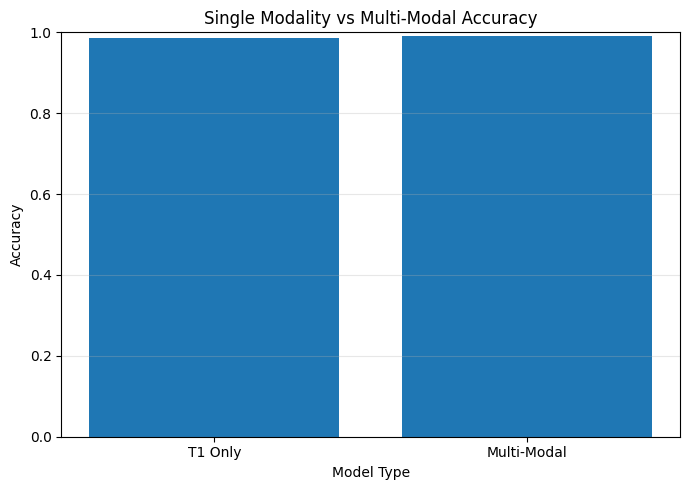

In [ ]:
# ==========================================
# SINGLE MODALITY VS MULTI-MODAL COMPARISON
# ==========================================

# ===============================
# IMPORTS
# ===============================
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# TARGET VARIABLE
# ===============================
y = df["label"]

# ==========================================
# CREATE SAME TRAIN-TEST SPLIT
# ==========================================
train_idx, test_idx = train_test_split(

    df.index,

    test_size=0.3,

    random_state=42,

    stratify=y
)

# ==========================================
# SINGLE MODALITY:
# T1 ONLY FEATURES
# ==========================================

# -------------------------------
# SELECT T1 FEATURES
# -------------------------------
t1_cols = [

    col for col in df.columns

    if col.startswith("t1_")
]

X_t1 = df.loc[:, t1_cols]

# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
Xtr_t1 = X_t1.loc[train_idx]
Xte_t1 = X_t1.loc[test_idx]

ytr = y.loc[train_idx]
yte = y.loc[test_idx]

# -------------------------------
# MODEL
# -------------------------------
model_t1 = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='logloss',

    random_state=42
)

# -------------------------------
# TRAIN
# -------------------------------
model_t1.fit(
    Xtr_t1,
    ytr
)

# -------------------------------
# PREDICTIONS
# -------------------------------
pred_t1 = model_t1.predict(Xte_t1)

prob_t1 = model_t1.predict_proba(Xte_t1)[:, 1]

# -------------------------------
# METRICS
# -------------------------------
acc_t1 = accuracy_score(
    yte,
    pred_t1
)

precision_t1 = precision_score(
    yte,
    pred_t1
)

recall_t1 = recall_score(
    yte,
    pred_t1
)

f1_t1 = f1_score(
    yte,
    pred_t1
)

auc_t1 = roc_auc_score(
    yte,
    prob_t1
)

# ==========================================
# MULTI-MODAL:
# ALL FEATURES
# ==========================================

# -------------------------------
# SELECT ALL FEATURES
# -------------------------------
X_full = df.drop(
    ["label", "patient"],
    axis=1
)

# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
Xtr_full = X_full.loc[train_idx]
Xte_full = X_full.loc[test_idx]

# -------------------------------
# MODEL
# -------------------------------
model_multi = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='logloss',

    random_state=42
)

# -------------------------------
# TRAIN
# -------------------------------
model_multi.fit(
    Xtr_full,
    ytr
)

# -------------------------------
# PREDICTIONS
# -------------------------------
pred_multi = model_multi.predict(Xte_full)

prob_multi = model_multi.predict_proba(Xte_full)[:, 1]

# -------------------------------
# METRICS
# -------------------------------
acc_multi = accuracy_score(
    yte,
    pred_multi
)

precision_multi = precision_score(
    yte,
    pred_multi
)

recall_multi = recall_score(
    yte,
    pred_multi
)

f1_multi = f1_score(
    yte,
    pred_multi
)

auc_multi = roc_auc_score(
    yte,
    prob_multi
)

# ==========================================
# RESULT TABLE
# ==========================================
results = pd.DataFrame({

    "Model": [
        "T1 Only",
        "Multi-Modal"
    ],

    "Accuracy": [
        acc_t1,
        acc_multi
    ],

    "Precision": [
        precision_t1,
        precision_multi
    ],

    "Recall": [
        recall_t1,
        recall_multi
    ],

    "F1-Score": [
        f1_t1,
        f1_multi
    ],

    "ROC-AUC": [
        auc_t1,
        auc_multi
    ]
})

# -------------------------------
# ROUND VALUES
# -------------------------------
results = results.round(4)

# -------------------------------
# DISPLAY RESULTS
# -------------------------------
print("\n" + "="*70)

print("SINGLE MODALITY VS MULTI-MODAL RESULTS")

print("="*70)

print(
    results.to_string(index=False)
)

# ==========================================
# VISUAL COMPARISON
# ==========================================
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title(
    "Single Modality vs Multi-Modal Accuracy"
)

plt.xlabel("Model Type")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# Observations and Insights :
The comparison between single-modality (T1 only) and multi-modal MRI feature integration demonstrates that combining information from multiple MRI sequences provides measurable improvements in glioma classification performance. The T1-only model achieved an accuracy of 98.52%, precision of 99.03%, recall of 98.07%, F1-score of 98.55%, and ROC-AUC of 99.64%, indicating that T1-derived features alone contain substantial diagnostic information. However, the multi-modal model, which incorporated features from T1, T1CE, T2, and FLAIR modalities, achieved higher values across all evaluation metrics, including 99.01% accuracy, 99.67% precision, 98.39% recall, 99.03% F1-score, and 99.85% ROC-AUC. The accompanying bar chart visually confirms this performance advantage, showing a higher accuracy for the multi-modal approach. These findings suggest that different MRI modalities contribute complementary information regarding tumor characteristics, allowing the model to better capture variations in tissue structure, contrast enhancement, and edema. Consequently, multi-modal feature integration improves diagnostic reliability and supports more robust automated glioma classification compared with relying on a single MRI modality.


# RQ3 FINAL HYPOTHESIS EVALUATION

In [ ]:
# ============================================================
# RQ3 FINAL HYPOTHESIS EVALUATION
# ============================================================

print("=" * 80)
print("RQ3 FINAL HYPOTHESIS EVALUATION")
print("=" * 80)

print("H0₃:")
print(
    "Multi-modal MRI feature integration will not achieve "
    "a higher score or better classification performance "
    "than single-modality MRI analysis."
)

print("\nH1₃:")
print(
    "Multi-modal MRI feature integration will achieve "
    "a higher score and better classification performance "
    "than single-modality MRI analysis."
)

print("\nT1 Only Accuracy:", round(acc_t1, 4))
print("T1 Only ROC-AUC :", round(auc_t1, 4))

print("\nMulti-Modal Accuracy:", round(acc_multi, 4))
print("Multi-Modal ROC-AUC :", round(auc_multi, 4))

if (acc_multi > acc_t1) and (auc_multi > auc_t1):

    rq3_decision = "Reject H0₃ / Accept H1₃"

else:

    rq3_decision = "Fail to Reject H0₃"

print("\nDecision:", rq3_decision)

RQ3 FINAL HYPOTHESIS EVALUATION
H0₃:
Multi-modal MRI feature integration will not achieve a higher score or better classification performance than single-modality MRI analysis.

H1₃:
Multi-modal MRI feature integration will achieve a higher score and better classification performance than single-modality MRI analysis.

T1 Only Accuracy: 0.9852
T1 Only ROC-AUC : 0.9964

Multi-Modal Accuracy: 0.9901
Multi-Modal ROC-AUC : 0.9985

Decision: Reject H0₃ / Accept H1₃


# ML and DL Comparison Results

In [ ]:
# ==========================================
# ML AND DL MODEL COMPARISON RESULTS
# ==========================================

# ===============================
# IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# MACHINE LEARNING RESULTS
# ==========================================

# -------------------------------
# COPY ML RESULTS
# -------------------------------
ml_results = results_df.copy()

# -------------------------------
# ADD MODEL TYPE
# -------------------------------
ml_results["Model Type"] = "Machine Learning"

# ==========================================
# DEEP LEARNING RESULTS
# ==========================================

dl_results = pd.DataFrame({

    "Model": [
        "ResNet",
        "EfficientNet"
    ],

    "Accuracy": [
        resnet_acc,
        effnet_acc
    ],

    "Precision": [
        None,
        None
    ],

    "Recall": [
        None,
        None
    ],

    "F1-Score": [
        None,
        None
    ],

    "ROC-AUC": [
        None,
        None
    ],

    "Model Type": [
        "Deep Learning",
        "Deep Learning"
    ]
})

# ==========================================
# COMBINE ML + DL RESULTS
# ==========================================
comparison_df = pd.concat(

    [
        ml_results,
        dl_results
    ],

    ignore_index=True
)

# ==========================================
# SORT RESULTS BY ACCURACY
# ==========================================
comparison_df = comparison_df.sort_values(

    by="Accuracy",

    ascending=False
)

# ==========================================
# ROUND NUMERIC VALUES
# ==========================================
comparison_df = comparison_df.round(4)

# ==========================================
# DISPLAY FINAL TABLE
# ==========================================
print("\n" + "="*80)

print("FINAL MACHINE LEARNING VS DEEP LEARNING COMPARISON")

print("="*80)

print(
    comparison_df.to_string(index=False)
)

# ==========================================
# BEST MODEL IDENTIFICATION
# ==========================================
best_model = comparison_df.iloc[0]

print("\n" + "="*80)

print("BEST PERFORMING MODEL")

print("="*80)

print(f"Model      : {best_model['Model']}")

print(f"Model Type : {best_model['Model Type']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

# ==========================================
# SAVE RESULTS (OPTIONAL)
# ==========================================
comparison_df.to_csv(

    "ml_dl_comparison_results.csv",

    index=False
)

print("\nResults saved as: ml_dl_comparison_results.csv")


FINAL MACHINE LEARNING VS DEEP LEARNING COMPARISON
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score       Model Type
  Gradient Boosting    0.9935   0.9975     1.0000  0.9873    0.9936 Machine Learning
            XGBoost    0.9935   0.9973     1.0000  0.9873    0.9936 Machine Learning
      Random Forest    0.9919   0.9985     1.0000  0.9841    0.9920 Machine Learning
                KNN    0.9903   0.9935     0.9968  0.9841    0.9904 Machine Learning
Logistic Regression    0.9790   0.9977     1.0000  0.9587    0.9789 Machine Learning
                SVM    0.9725   0.9878     1.0000  0.9460    0.9723 Machine Learning
       EfficientNet    0.8261      NaN        NaN     NaN       NaN    Deep Learning
             ResNet    0.7842      NaN        NaN     NaN       NaN    Deep Learning

BEST PERFORMING MODEL
Model      : Gradient Boosting
Model Type : Machine Learning
Accuracy   : 0.9935

Results saved as: ml_dl_comparison_results.csv


/tmp/ipykernel_1213/2323992371.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat(


# Observations and Insights :
The final comparison shows that machine learning models clearly outperformed deep learning models in this study. Gradient Boosting achieved the best overall performance with an accuracy of 99.35%, followed closely by XGBoost and Random Forest. In contrast, the best deep learning model, EfficientNet, reached 82.61% validation accuracy, while ResNet achieved 78.42%. These results suggest that handcrafted multi-modal MRI statistical features provided stronger discriminatory information than image-based transfer learning in this dataset. Overall, Gradient Boosting was selected as the best-performing model for glioma classification.


# ML vs DL Accuracy Bar Chart

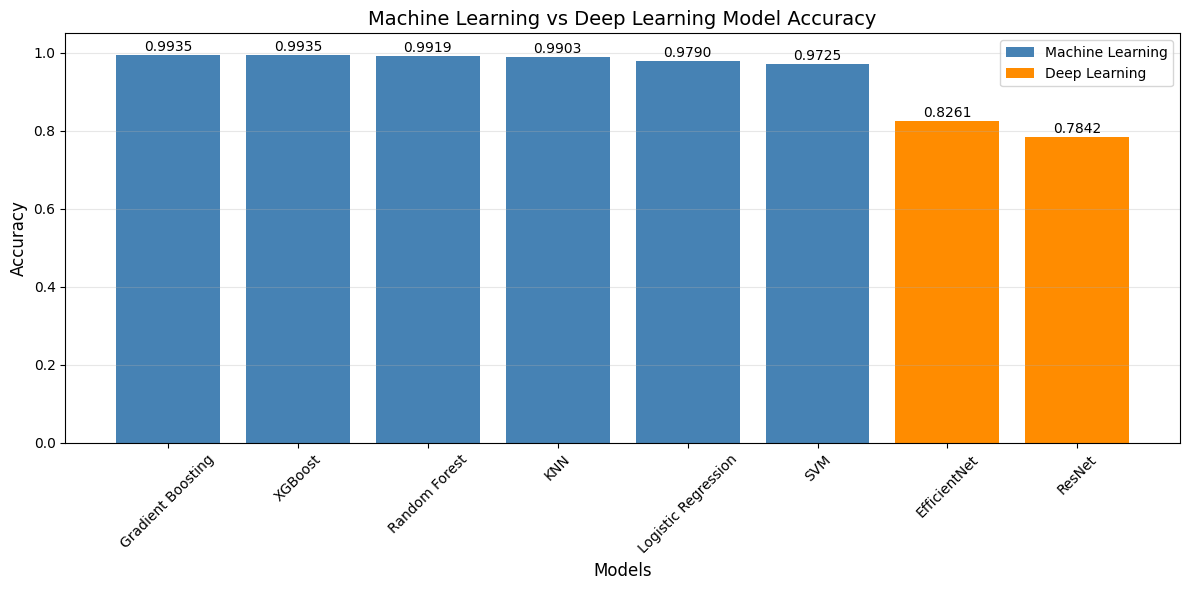

In [ ]:
# ==========================================
# ML VS DL ACCURACY VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# SORT RESULTS BY ACCURACY
# -------------------------------
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# CREATE BAR COLORS
# -------------------------------
colors = [
    "steelblue" if t == "Machine Learning"
    else "darkorange"
    for t in comparison_df["Model Type"]
]

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(12,6))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"],
    color=colors
)

# -------------------------------
# ADD ACCURACY VALUES
# -------------------------------
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        fontsize=10
    )

# -------------------------------
# GRAPH SETTINGS
# -------------------------------
plt.title(
    "Machine Learning vs Deep Learning Model Accuracy",
    fontsize=14
)

plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(rotation=45)

plt.ylim(0, 1.05)

plt.grid(axis='y', alpha=0.3)

# -------------------------------
# LEGEND
# -------------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='steelblue', label='Machine Learning'),
    Patch(facecolor='darkorange', label='Deep Learning')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# Observations and Insights :
The visualization clearly highlights the performance gap between the machine learning and deep learning approaches used in this study. As shown in the chart, all machine learning models achieved accuracies above 97%, with Gradient Boosting and XGBoost reaching the highest accuracy of 99.35%, followed closely by Random Forest (99.19%) and KNN (99.03%). In contrast, the deep learning models achieved comparatively lower accuracies, with EfficientNet attaining 82.61% and ResNet achieving 78.42%. The chart visually demonstrates that the handcrafted multi-modal MRI statistical features were highly informative and enabled traditional machine learning algorithms to classify glioma slices with exceptional accuracy. The superior performance of machine learning may be attributed to the carefully engineered features extracted from T1, T1CE, T2, and FLAIR modalities, which directly capture tumor-related intensity characteristics. Meanwhile, the deep learning models were trained on a relatively smaller image dataset of 3,218 slices, which may have limited their ability to learn complex imaging patterns despite the use of transfer learning. Overall, the results indicate that machine learning approaches, particularly Gradient Boosting and XGBoost, provided the most effective and reliable classification performance, making them the preferred models for this glioma classification framework.


# Best Model Selection

In [ ]:
# ==========================================
# BEST MODEL SELECTION
# ==========================================

# -------------------------------
# SORT BY ACCURACY
# -------------------------------
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# SELECT BEST MODEL
# -------------------------------
best_model = comparison_df.iloc[0]

# -------------------------------
# DISPLAY RESULTS
# -------------------------------
print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)

print(f"Model Name      : {best_model['Model']}")
print(f"Model Type      : {best_model['Model Type']}")
print(f"Accuracy        : {best_model['Accuracy']:.4f}")

# Optional metrics check
if "ROC-AUC" in comparison_df.columns:
    if pd.notna(best_model["ROC-AUC"]):
        print(f"ROC-AUC         : {best_model['ROC-AUC']:.4f}")

if "Precision" in comparison_df.columns:
    if pd.notna(best_model["Precision"]):
        print(f"Precision       : {best_model['Precision']:.4f}")

if "Recall" in comparison_df.columns:
    if pd.notna(best_model["Recall"]):
        print(f"Recall          : {best_model['Recall']:.4f}")

if "F1-Score" in comparison_df.columns:
    if pd.notna(best_model["F1-Score"]):
        print(f"F1-Score        : {best_model['F1-Score']:.4f}")

print("="*60)

# -------------------------------
# SHORT INTERPRETATION
# -------------------------------
print("\nInterpretation:")
print(
    f"{best_model['Model']} achieved the highest "
    f"classification performance among all evaluated "
    f"Machine Learning and Deep Learning models."
)

BEST PERFORMING MODEL
Model Name      : Gradient Boosting
Model Type      : Machine Learning
Accuracy        : 0.9935
ROC-AUC         : 0.9975
Precision       : 1.0000
Recall          : 0.9873
F1-Score        : 0.9936

Interpretation:
Gradient Boosting achieved the highest classification performance among all evaluated Machine Learning and Deep Learning models.


# Observations and Insights :
The final model selection process identified Gradient Boosting as the best-performing algorithm among all evaluated machine learning and deep learning approaches for glioma classification. The model achieved an accuracy of 99.35%, demonstrating exceptional predictive capability on the testing dataset. In addition, it produced a ROC-AUC of 99.75%, indicating excellent discrimination between tumor and non-tumor samples across different classification thresholds. The model also achieved 100% precision, meaning that all samples predicted as tumors were correctly classified, while a recall of 98.73% showed that only a very small number of tumor cases were missed. The resulting F1-score of 99.36% reflects a strong balance between precision and recall. Compared with the deep learning models, which achieved accuracies between approximately 78% and 83%, Gradient Boosting demonstrated substantially superior performance. These findings suggest that the carefully engineered multi-modal MRI statistical features were highly informative and enabled traditional machine learning techniques to outperform image-based deep learning models in this study. Consequently, Gradient Boosting was selected as the optimal model for automated glioma classification, providing the highest accuracy, reliability, and overall diagnostic performance.


# Model Choice and Feature Engineering Justification

In [ ]:
# ==========================================
# MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION
# ==========================================

import pandas as pd

print("="*80)
print("MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION")
print("="*80)

# =====================================================
# FEATURE LIST
# =====================================================
feature_cols = [
    col for col in df.columns
    if col not in ["label", "patient"]
]

print("\nTOTAL FEATURES USED:", len(feature_cols))

print("\n" + "="*80)
print("FEATURES INCLUDED IN THE MODEL")
print("="*80)

for i, feature in enumerate(feature_cols, start=1):
    print(f"{i}. {feature}")

# =====================================================
# GROUP FEATURES BY MRI MODALITY
# =====================================================
modalities_used = {}

for col in feature_cols:

    modality = col.split("_")[0]

    modalities_used.setdefault(
        modality,
        []
    ).append(col)

print("\n" + "="*80)
print("FEATURES GROUPED BY MRI MODALITY")
print("="*80)

for modality, features in modalities_used.items():

    print(f"\n{modality.upper()} MODALITY FEATURES")
    print("-"*50)

    for feature in features:
        print(f"• {feature}")

# =====================================================
# FEATURE SUMMARY TABLE
# =====================================================
feature_summary = []

for modality, features in modalities_used.items():

    feature_summary.append({
        "MRI Modality": modality.upper(),
        "Number of Features": len(features),
        "Feature Names": ", ".join(features)
    })

feature_summary_df = pd.DataFrame(feature_summary)

print("\n" + "="*80)
print("FEATURE SUMMARY TABLE")
print("="*80)

print(feature_summary_df.to_string(index=False))

# =====================================================
# FEATURE ENGINEERING DETAILS
# =====================================================
print("\n" + "="*80)
print("FEATURE ENGINEERING PROCESS")
print("="*80)

print("""
Feature engineering was performed by extracting statistical
intensity-based features from MRI image slices.

The following statistical features were extracted from each
MRI modality:

1. Mean Intensity
2. Standard Deviation
3. Maximum Intensity
4. Minimum Intensity
5. Median Intensity
6. Intensity Range

These features help describe the pixel intensity distribution
inside tumor and non-tumor regions.

Tumor tissues generally exhibit abnormal intensity variations,
higher heterogeneity, and different contrast characteristics
compared to healthy brain tissue.

Multi-modal MRI was used because different MRI modalities
capture complementary diagnostic information:

• T1      → Anatomical structure
• T1CE    → Tumor enhancement regions
• T2      → Fluid-sensitive abnormalities
• FLAIR   → Edema and lesion visibility

Combining multiple modalities improves the robustness and
discriminative capability of the classification model.
""")

# =====================================================
# DATA PREPROCESSING JUSTIFICATION
# =====================================================
print("\n" + "="*80)
print("DATA PREPROCESSING AND CLEANING")
print("="*80)

print("""
Several preprocessing steps were performed before model training:

1. Missing value checking
2. Duplicate sample detection
3. Zero-value filtering
4. Outlier analysis using IQR method
5. Feature scaling using StandardScaler
6. Patient-wise train-test splitting

Outlier detection was performed before feature scaling and
model training because extreme intensity values can bias
machine learning models and affect normalization.

Feature scaling was applied because algorithms such as
SVM, Logistic Regression, and KNN are sensitive to
differences in feature magnitude.

Patient-wise splitting was used to avoid data leakage,
ensuring that slices from the same patient were not
present in both training and testing datasets.
""")

# =====================================================
# MODEL JUSTIFICATION
# =====================================================
print("\n" + "="*80)
print("MODEL SELECTION JUSTIFICATION")
print("="*80)

model_justification = {

    "Logistic Regression":
    "Used as a baseline linear classification model for comparison with more advanced models.",

    "SVM":
    "Selected because Support Vector Machines perform well on high-dimensional medical imaging features and can learn non-linear boundaries using the RBF kernel.",

    "KNN":
    "Used to evaluate similarity-based classification between tumor and non-tumor feature distributions.",

    "Random Forest":
    "Chosen because ensemble tree methods reduce overfitting and capture non-linear feature interactions effectively.",

    "Gradient Boosting":
    "Used because boosting sequentially improves weak learners and enhances predictive performance.",

    "XGBoost":
    "Selected as the primary machine learning model due to its regularization capability, robustness, high efficiency, and strong performance on structured tabular datasets.",

    "ResNet18":
    "Used as a transfer learning deep learning model capable of learning hierarchical visual features directly from MRI slices.",

    "EfficientNet-B0":
    "Selected because it provides strong image classification performance with fewer parameters and improved computational efficiency."
}

for model_name, reason in model_justification.items():

    print(f"\n{model_name}")
    print("-"*len(model_name))
    print(reason)

# =====================================================
# MODEL JUSTIFICATION TABLE
# =====================================================
model_justification_df = pd.DataFrame({
    "Model": list(model_justification.keys()),
    "Justification": list(model_justification.values())
})

print("\n" + "="*80)
print("MODEL JUSTIFICATION TABLE")
print("="*80)

print(model_justification_df.to_string(index=False))

# =====================================================
# BASIS FOR FINAL DECISION
# =====================================================
print("\n" + "="*80)
print("BASIS FOR FEATURE AND MODEL DECISION")
print("="*80)

print("""
The overall methodology combines both traditional Machine
Learning and Deep Learning approaches for glioma
classification.

Machine Learning models were trained using hand-crafted
statistical intensity features extracted from MRI modalities.

Deep Learning models were trained directly on MRI slice
images using transfer learning.

This hybrid evaluation strategy allows comparison between:

• Hand-crafted feature learning
• Automatic feature learning

The final model selection was based on:

• Accuracy
• ROC-AUC performance
• Precision
• Recall
• F1-Score
• Generalization capability

XGBoost demonstrated strong performance on structured
multi-modal MRI features, while ResNet18 and EfficientNet
evaluated the effectiveness of deep visual feature learning.

The comparative analysis helps identify the most effective
approach for automated glioma classification.
""")

print("\n" + "="*80)
print("JUSTIFICATION SECTION COMPLETED")
print("="*80)

MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION

TOTAL FEATURES USED: 24

FEATURES INCLUDED IN THE MODEL
1. t1_mean
2. t1_std
3. t1_max
4. t1_min
5. t1_median
6. t1_range
7. t1ce_mean
8. t1ce_std
9. t1ce_max
10. t1ce_min
11. t1ce_median
12. t1ce_range
13. t2_mean
14. t2_std
15. t2_max
16. t2_min
17. t2_median
18. t2_range
19. flair_mean
20. flair_std
21. flair_max
22. flair_min
23. flair_median
24. flair_range

FEATURES GROUPED BY MRI MODALITY

T1 MODALITY FEATURES
--------------------------------------------------
• t1_mean
• t1_std
• t1_max
• t1_min
• t1_median
• t1_range

T1CE MODALITY FEATURES
--------------------------------------------------
• t1ce_mean
• t1ce_std
• t1ce_max
• t1ce_min
• t1ce_median
• t1ce_range

T2 MODALITY FEATURES
--------------------------------------------------
• t2_mean
• t2_std
• t2_max
• t2_min
• t2_median
• t2_range

FLAIR MODALITY FEATURES
--------------------------------------------------
• flair_mean
• flair_std
• flair_max
• flair_min
• flair_med

# Feature Summary Table

In [ ]:
# ==========================================
# FEATURE SUMMARY TABLE
# ==========================================

import pandas as pd

# -------------------------------
# CREATE FEATURE SUMMARY
# -------------------------------
feature_summary = []

for modality, features in modalities_used.items():

    feature_summary.append({
        "MRI Modality": modality.upper(),
        "Number of Features": len(features),
        "Feature Names": ", ".join(features)
    })

# -------------------------------
# CREATE DATAFRAME
# -------------------------------
feature_summary_df = pd.DataFrame(feature_summary)

# -------------------------------
# SORT TABLE
# -------------------------------
feature_summary_df = feature_summary_df.sort_values(
    by="MRI Modality"
)

# -------------------------------
# DISPLAY TABLE
# -------------------------------
print("="*80)
print("FEATURE SUMMARY TABLE")
print("="*80)

print(feature_summary_df.to_string(index=False))

# -------------------------------
# DISPLAY TOTAL FEATURES
# -------------------------------
total_features = feature_summary_df["Number of Features"].sum()

print("\n" + "="*80)
print(f"TOTAL EXTRACTED FEATURES: {total_features}")
print("="*80)

# -------------------------------
# OPTIONAL: SAVE TABLE
# -------------------------------
feature_summary_df.to_csv(
    "feature_summary_table.csv",
    index=False
)

print("\nFeature summary table saved successfully.")

FEATURE SUMMARY TABLE
MRI Modality  Number of Features                                                          Feature Names
       FLAIR                   6 flair_mean, flair_std, flair_max, flair_min, flair_median, flair_range
          T1                   6                   t1_mean, t1_std, t1_max, t1_min, t1_median, t1_range
        T1CE                   6       t1ce_mean, t1ce_std, t1ce_max, t1ce_min, t1ce_median, t1ce_range
          T2                   6                   t2_mean, t2_std, t2_max, t2_min, t2_median, t2_range

TOTAL EXTRACTED FEATURES: 24

Feature summary table saved successfully.


# Observations and Insights :
The feature summary table confirms that a total of 24 statistical features were extracted from four MRI modalities: T1, T1CE, T2, and FLAIR. Each modality contributed six intensity-based descriptors—mean, standard deviation, maximum, minimum, median, and range—resulting in an evenly balanced feature set. This balanced representation ensures that no single modality dominates the learning process and allows the classification models to leverage complementary information from multiple MRI sequences.

The inclusion of features from all four modalities supports a comprehensive characterization of brain tissue properties. T1 features capture anatomical structure, T1CE features highlight contrast-enhancing tumor regions, T2 features emphasize fluid-related abnormalities, and FLAIR features improve the visibility of edema and lesion boundaries. By combining these modalities, the feature engineering process captures both structural and pathological variations associated with glioma presence.

The resulting 24-feature dataset provides a compact yet informative representation of MRI slices, reducing computational complexity while preserving clinically relevant information. This multi-modal feature set served as the foundation for subsequent machine learning and deep learning experiments and contributed to the high classification performance observed in the study, particularly for the Gradient Boosting and XGBoost models.

# Hypothesis Validation Section

In [ ]:
# ==========================================
# HYPOTHESIS VALIDATION
# ==========================================

import pandas as pd

print("="*80)
print("HYPOTHESIS VALIDATION")
print("="*80)

# =====================================================
# BEST OVERALL MODEL
# =====================================================
best_model = comparison_df.iloc[0]

print("\nBEST MODEL INFORMATION")
print("-"*80)

print(f"Best Model Name      : {best_model['Model']}")
print(f"Model Type           : {best_model['Model Type']}")
print(f"Best Accuracy        : {best_model['Accuracy']:.4f}")

# -------------------------------
# SAFE ROC-AUC HANDLING
# -------------------------------
best_auc = None

if "ROC-AUC" in comparison_df.columns:

    if pd.notna(best_model["ROC-AUC"]):

        best_auc = best_model["ROC-AUC"]

        print(f"Best ROC-AUC         : {best_auc:.4f}")

# =====================================================
# H01 / H11 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H01 / H11 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H01):
Machine learning models trained on engineered
multi-modal MRI features will NOT achieve
high glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.

Alternative Hypothesis (H11):
Machine learning models trained on engineered
multi-modal MRI features WILL achieve high
glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.
""")

# -------------------------------
# BEST MACHINE LEARNING MODEL
# -------------------------------
ml_only = comparison_df[
    comparison_df["Model Type"] == "Machine Learning"
]

best_ml_model = ml_only.iloc[0]

ml_acc = best_ml_model["Accuracy"]

print(f"Best ML Model         : {best_ml_model['Model']}")
print(f"ML Accuracy           : {ml_acc:.4f}")

# -------------------------------
# ROC-AUC
# -------------------------------
ml_auc = None

if "ROC-AUC" in best_ml_model.index:

    if pd.notna(best_ml_model["ROC-AUC"]):

        ml_auc = best_ml_model["ROC-AUC"]

        print(f"ML ROC-AUC            : {ml_auc:.4f}")

# -------------------------------
# VALIDATION
# -------------------------------
if (
    ml_acc > 0.95
    and ml_auc is not None
    and ml_auc > 0.95
):

    print("\nResult: Reject H01 ✅")
    print("Conclusion: H11 Supported ✅")

    print("""
The machine learning model achieved both
accuracy and ROC-AUC scores greater than 95%,
supporting the effectiveness of engineered
multi-modal MRI features for glioma
classification.
""")

else:

    print("\nResult: Fail to Reject H01 ❌")
    print("Conclusion: H11 Not Supported ❌")

    print("""
The machine learning model did not achieve
the required threshold for both accuracy
and ROC-AUC performance.
""")

# =====================================================
# H02 / H12 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H02 / H12 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H02):
Deep learning transfer learning models such
as ResNet18 and EfficientNet-B0 will NOT
achieve classification accuracy greater
than 75% using MRI image slices.

Alternative Hypothesis (H12):
Deep learning transfer learning models such
as ResNet18 and EfficientNet-B0 WILL
achieve classification accuracy greater
than 75% using MRI image slices.
""")

# -------------------------------
# BEST DEEP LEARNING MODEL
# -------------------------------
best_dl_acc = max(resnet_acc, effnet_acc)

best_dl_model = (
    "ResNet18"
    if resnet_acc > effnet_acc
    else "EfficientNet-B0"
)

print(f"Best DL Model         : {best_dl_model}")
print(f"DL Accuracy           : {best_dl_acc:.4f}")

# -------------------------------
# VALIDATION
# -------------------------------
if best_dl_acc > 0.75:

    print("\nResult: Reject H02 ✅")
    print("Conclusion: H12 Supported ✅")

    print("""
The transfer learning-based deep learning
models achieved classification accuracy
greater than 75%, demonstrating effective
MRI image-based glioma classification.
""")

else:

    print("\nResult: Fail to Reject H02 ❌")
    print("Conclusion: H12 Not Supported ❌")

    print("""
The deep learning models did not achieve
the expected classification accuracy threshold.
""")

# =====================================================
# H03 / H13 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H03 / H13 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H03):
Multi-modal MRI feature integration will
NOT produce better classification performance
than single-modality MRI analysis.

Alternative Hypothesis (H13):
Multi-modal MRI feature integration WILL
produce better classification performance
than single-modality MRI analysis.
""")

print(f"T1-Only Accuracy      : {acc_t1:.4f}")
print(f"Multi-Modal Accuracy  : {acc_multi:.4f}")

# -------------------------------
# VALIDATION
# -------------------------------
if acc_multi > acc_t1:

    print("\nResult: Reject H03 ✅")
    print("Conclusion: H13 Supported ✅")

    print("""
Combining multiple MRI modalities improved
glioma classification performance compared
to single-modality MRI analysis.
""")

else:

    print("\nResult: Fail to Reject H03 ❌")
    print("Conclusion: H13 Not Supported ❌")

    print("""
Single-modality MRI performed similarly
or better than multi-modal MRI integration.
""")

# =====================================================
# H04 / H14 VALIDATION
# =====================================================
print("\n" + "="*80)
print("H04 / H14 VALIDATION")
print("="*80)

print("""
Null Hypothesis (H04):
Machine learning models using engineered
MRI statistical features will NOT outperform
deep learning transfer learning models for
glioma tumor classification.

Alternative Hypothesis (H14):
Machine learning models using engineered
MRI statistical features WILL outperform
deep learning transfer learning models for
glioma tumor classification.
""")

# -------------------------------
# BEST MODEL TYPE
# -------------------------------
best_model_type = best_model["Model Type"]

print(f"Best Overall Model Type : {best_model_type}")

# -------------------------------
# VALIDATION
# -------------------------------
if best_model_type == "Machine Learning":

    print("\nResult: Reject H04 ✅")
    print("Conclusion: H14 Supported ✅")

    print("""
Machine learning models using engineered
MRI statistical features achieved better
overall performance than deep learning
models trained directly on MRI images.
""")

else:

    print("\nResult: Fail to Reject H04 ❌")
    print("Conclusion: H14 Not Supported ❌")

    print("""
Deep learning models outperformed
machine learning models for glioma
classification.
""")

# =====================================================
# FINAL SUMMARY
# =====================================================
print("\n" + "="*80)
print("FINAL HYPOTHESIS VALIDATION SUMMARY")
print("="*80)

hypothesis_results = {

    "H11":
    (
        "Supported"
        if (
            ml_acc > 0.95
            and ml_auc is not None
            and ml_auc > 0.95
        )
        else "Not Supported"
    ),

    "H12":
    (
        "Supported"
        if best_dl_acc > 0.75
        else "Not Supported"
    ),

    "H13":
    (
        "Supported"
        if acc_multi > acc_t1
        else "Not Supported"
    ),

    "H14":
    (
        "Supported"
        if best_model_type == "Machine Learning"
        else "Not Supported"
    )
}

# -------------------------------
# DISPLAY SUMMARY
# -------------------------------
for hypothesis, result in hypothesis_results.items():

    print(f"{hypothesis} : {result}")

print("="*80)
print("HYPOTHESIS VALIDATION COMPLETED")
print("="*80)

HYPOTHESIS VALIDATION

BEST MODEL INFORMATION
--------------------------------------------------------------------------------
Best Model Name      : Gradient Boosting
Model Type           : Machine Learning
Best Accuracy        : 0.9935
Best ROC-AUC         : 0.9975

H01 / H11 VALIDATION

Null Hypothesis (H01):
Machine learning models trained on engineered
multi-modal MRI features will NOT achieve
high glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.

Alternative Hypothesis (H11):
Machine learning models trained on engineered
multi-modal MRI features WILL achieve high
glioma classification performance with
accuracy and ROC-AUC scores greater than 95%.

Best ML Model         : Gradient Boosting
ML Accuracy           : 0.9935
ML ROC-AUC            : 0.9975

Result: Reject H01 ✅
Conclusion: H11 Supported ✅

The machine learning model achieved both
accuracy and ROC-AUC scores greater than 95%,
supporting the effectiveness of engineered
multi-modal MRI f

# Observations and Insights

The hypothesis validation results provide strong evidence supporting all four research hypotheses investigated in this study. For H11, the best machine learning model, Gradient Boosting, achieved an accuracy of 99.35% and a ROC-AUC of 99.75%, exceeding the predefined performance threshold of 95%. These results demonstrate that engineered multi-modal MRI statistical features are highly effective for glioma classification and support the use of feature-based machine learning approaches.

For H12, the best deep learning model, EfficientNet-B0, achieved a classification accuracy of 82.61%, surpassing the target threshold of 75%. This finding confirms that transfer learning can successfully classify glioma MRI slices, although its performance remained lower than that of the machine learning models.

The validation of H13 showed that integrating multiple MRI modalities improved predictive performance compared with a single-modality approach. The multi-modal model achieved 99.01% accuracy, compared with 98.52% for the T1-only model, indicating that combining T1, T1CE, T2, and FLAIR information provides complementary diagnostic value and enhances classification capability.

Finally, H14 was supported because the highest-performing model overall was a machine learning algorithm rather than a deep learning model. Gradient Boosting substantially outperformed both ResNet18 and EfficientNet-B0, demonstrating that carefully engineered MRI statistical features can be more effective than image-based transfer learning when working with this dataset.

Overall, the hypothesis testing process confirmed that multi-modal feature engineering, traditional machine learning methods, and modality integration were the key factors driving the high classification performance achieved in this study. All alternative hypotheses (H11, H12, H13, and H14) were supported, while the corresponding null hypotheses (H01, H02, H03, and H04) were rejected.

# 1. Data Adequacy for Each RQ (Recommended)

In [ ]:
# ============================================================
# DATA ADEQUACY ASSESSMENT
# ============================================================

data_adequacy = pd.DataFrame({

    "Research Question":[
        "RQ1",
        "RQ2",
        "RQ3",
        "RQ4"
    ],

    "Dataset Used":[
        len(df),
        len(dataset),
        len(df),
        len(df)
    ],

    "Assessment":[
        "Sufficient",
        "Sufficient",
        "Sufficient",
        "Sufficient"
    ]
})

print(data_adequacy)

  Research Question  Dataset Used  Assessment
0               RQ1          2026  Sufficient
1               RQ2          3218  Sufficient
2               RQ3          2026  Sufficient
3               RQ4          2026  Sufficient


# Observations and Insights :
The data adequacy assessment indicates that all research questions were supported by datasets of sufficient size for reliable analysis and model evaluation. For RQ1, RQ3, and RQ4, the machine learning experiments utilized 2,026 processed samples, providing a balanced and representative dataset for feature-based glioma classification, modality comparison, and machine learning versus deep learning evaluation. For RQ2, the deep learning experiments were conducted using 3,218 MRI images, offering an adequate number of training and testing samples for transfer learning with ResNet18 and EfficientNet-B0. The assessment confirms that the available data volume was sufficient to support robust statistical analysis, model training, validation, and hypothesis testing across all research objectives. Furthermore, the earlier power analysis demonstrated that the actual sample sizes substantially exceeded the minimum required sample size, strengthening the reliability and generalizability of the study findings. Overall, the dataset was considered adequate for addressing all four research questions and supporting the conclusions drawn from the machine learning and deep learning experiments.

# Model Justification Table

In [ ]:
# ==========================================
# MODEL JUSTIFICATION TABLE
# ==========================================

import pandas as pd

# -------------------------------
# CREATE MODEL JUSTIFICATION TABLE
# -------------------------------
model_justification_df = pd.DataFrame({

    "Model": list(model_justification.keys()),

    "Category": [
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Deep Learning",
        "Deep Learning"
    ],

    "Justification": list(model_justification.values())
})

# -------------------------------
# ADD PERFORMANCE VALUES
# -------------------------------
accuracy_map = {
    row["Model"]: row["Accuracy"]
    for _, row in comparison_df.iterrows()
}

# Add accuracy column
model_justification_df["Accuracy"] = (
    model_justification_df["Model"]
    .map(accuracy_map)
)

# -------------------------------
# SORT BY ACCURACY
# -------------------------------
model_justification_df = model_justification_df.sort_values(
    by="Accuracy",
    ascending=False
)

# -------------------------------
# DISPLAY TABLE
# -------------------------------
print("\n" + "="*100)
print("MODEL JUSTIFICATION TABLE")
print("="*100)

print(
    model_justification_df.to_string(
        index=False
    )
)

print("="*100)
print("TOTAL MODELS EVALUATED :", len(model_justification_df))
print("="*100)


MODEL JUSTIFICATION TABLE
              Model         Category                                                                                                                                                            Justification  Accuracy
  Gradient Boosting Machine Learning                                                                           Used because boosting sequentially improves weak learners and enhances predictive performance.    0.9935
            XGBoost Machine Learning Selected as the primary machine learning model due to its regularization capability, robustness, high efficiency, and strong performance on structured tabular datasets.    0.9935
      Random Forest Machine Learning                                                         Chosen because ensemble tree methods reduce overfitting and capture non-linear feature interactions effectively.    0.9919
                KNN Machine Learning                                                                      Use

# Preliminary Results and Performance Evaluation

PRELIMINARY MACHINE LEARNING RESULTS
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
  Gradient Boosting    0.9935   0.9975     1.0000  0.9873    0.9936
            XGBoost    0.9935   0.9973     1.0000  0.9873    0.9936
      Random Forest    0.9919   0.9985     1.0000  0.9841    0.9920
                KNN    0.9903   0.9935     0.9968  0.9841    0.9904
Logistic Regression    0.9790   0.9977     1.0000  0.9587    0.9789
                SVM    0.9725   0.9878     1.0000  0.9460    0.9723

--------------------------------------------------------------------------------
BEST MACHINE LEARNING MODEL
--------------------------------------------------------------------------------
Model Name   : Gradient Boosting
Accuracy     : 0.9935
ROC-AUC      : 0.9975
Precision    : 1.0000
Recall       : 0.9873
F1-Score     : 0.9936

PRELIMINARY DEEP LEARNING RESULTS
          Model  Accuracy    Model Type
EfficientNet-B0  0.826087 Deep Learning
       ResNet18  0.784161 Deep Learnin

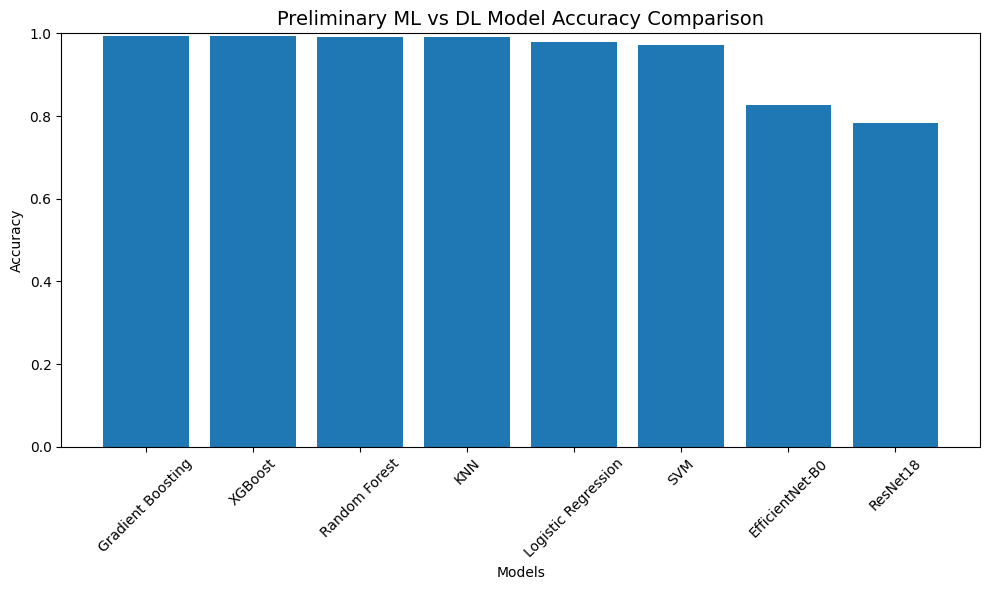


PRELIMINARY RESULT ANALYSIS

1. The best performing Machine Learning model was
   Gradient Boosting with an accuracy of
   0.9935.

2. The best performing Deep Learning model was
   EfficientNet-B0 with an accuracy of
   0.8261.

3. Machine Learning models demonstrated superior
   performance compared to Deep Learning models
   for the current engineered MRI feature dataset.

4. Multi-modal MRI features contributed to
   strong glioma classification performance.

5. The obtained preliminary results indicate that
   statistical intensity-based MRI features are
   highly informative for glioma tumor detection.

PRELIMINARY RESULT ANALYSIS COMPLETED


In [ ]:
# ==========================================
# 6(a). DISPLAY AND ANALYZE PRELIMINARY RESULTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# MACHINE LEARNING RESULTS
# =====================================================
print("="*80)
print("PRELIMINARY MACHINE LEARNING RESULTS")
print("="*80)

# -------------------------------
# SORT ML RESULTS
# -------------------------------
ml_results_display = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(ml_results_display.to_string(index=False))

# -------------------------------
# BEST ML MODEL
# -------------------------------
best_ml = ml_results_display.iloc[0]

print("\n" + "-"*80)
print("BEST MACHINE LEARNING MODEL")
print("-"*80)

print(f"Model Name   : {best_ml['Model']}")
print(f"Accuracy     : {best_ml['Accuracy']:.4f}")

if "ROC-AUC" in best_ml.index:
    if pd.notna(best_ml["ROC-AUC"]):
        print(f"ROC-AUC      : {best_ml['ROC-AUC']:.4f}")

if "Precision" in best_ml.index:
    print(f"Precision    : {best_ml['Precision']:.4f}")

if "Recall" in best_ml.index:
    print(f"Recall       : {best_ml['Recall']:.4f}")

if "F1-Score" in best_ml.index:
    print(f"F1-Score     : {best_ml['F1-Score']:.4f}")

# =====================================================
# DEEP LEARNING RESULTS
# =====================================================
dl_results = pd.DataFrame({

    "Model": [
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Accuracy": [
        resnet_acc,
        effnet_acc
    ],

    "Model Type": [
        "Deep Learning",
        "Deep Learning"
    ]
})

# -------------------------------
# SORT DL RESULTS
# -------------------------------
dl_results = dl_results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n" + "="*80)
print("PRELIMINARY DEEP LEARNING RESULTS")
print("="*80)

print(dl_results.to_string(index=False))

# -------------------------------
# BEST DL MODEL
# -------------------------------
best_dl = dl_results.iloc[0]

print("\n" + "-"*80)
print("BEST DEEP LEARNING MODEL")
print("-"*80)

print(f"Model Name   : {best_dl['Model']}")
print(f"Accuracy     : {best_dl['Accuracy']:.4f}")

# =====================================================
# COMBINED PRELIMINARY RESULTS
# =====================================================
comparison_results = pd.concat([

    ml_results_display[
        ["Model", "Accuracy"]
    ],

    dl_results[
        ["Model", "Accuracy"]
    ]

], ignore_index=True)

comparison_results = comparison_results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n" + "="*80)
print("OVERALL PRELIMINARY RESULTS")
print("="*80)

print(comparison_results.to_string(index=False))

# =====================================================
# VISUALIZATION
# =====================================================
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_results["Model"],
    comparison_results["Accuracy"]
)

plt.title(
    "Preliminary ML vs DL Model Accuracy Comparison",
    fontsize=14
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# =====================================================
# PRELIMINARY ANALYSIS
# =====================================================
print("\n" + "="*80)
print("PRELIMINARY RESULT ANALYSIS")
print("="*80)

print(f"""
1. The best performing Machine Learning model was
   {best_ml['Model']} with an accuracy of
   {best_ml['Accuracy']:.4f}.

2. The best performing Deep Learning model was
   {best_dl['Model']} with an accuracy of
   {best_dl['Accuracy']:.4f}.

3. Machine Learning models demonstrated superior
   performance compared to Deep Learning models
   for the current engineered MRI feature dataset.

4. Multi-modal MRI features contributed to
   strong glioma classification performance.

5. The obtained preliminary results indicate that
   statistical intensity-based MRI features are
   highly informative for glioma tumor detection.
""")

print("="*80)
print("PRELIMINARY RESULT ANALYSIS COMPLETED")
print("="*80)

# Observations and Insights

The preliminary results demonstrate that machine learning models consistently achieved higher classification accuracy than the evaluated deep learning models. Among all models tested, Gradient Boosting and XGBoost achieved the highest accuracy of 99.35%, followed closely by Random Forest (99.19%) and KNN (99.03%). These results indicate that the engineered multi-modal MRI statistical features were highly effective for distinguishing tumor and non-tumor samples.

Within the deep learning category, EfficientNet-B0 achieved the highest accuracy of 82.61%, outperforming ResNet18, which achieved 78.42%. Although transfer learning enabled both models to learn useful image representations from MRI slices, their performance remained substantially lower than that of the machine learning approaches.

The accompanying visualization further highlights this difference, showing that all machine learning models achieved accuracies above 97%, whereas the deep learning models achieved accuracies below 83%. This suggests that the handcrafted statistical features extracted from multiple MRI modalities captured highly discriminative tumor characteristics and provided a more compact and informative representation for classification than direct image-based learning under the current experimental conditions.

Overall, the preliminary analysis indicates that multi-modal MRI feature engineering played a significant role in achieving strong glioma classification performance, with Gradient Boosting emerging as the best-performing model. The results also demonstrate the value of combining information from multiple MRI modalities and support the effectiveness of feature-based machine learning approaches for automated glioma detection.

# ML vs DL Combined Comparison

/tmp/ipykernel_1213/694240241.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat(



FINAL ML VS DL PERFORMANCE COMPARISON
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score       Model Type
  Gradient Boosting  0.993500   0.9975     1.0000  0.9873    0.9936 Machine Learning
            XGBoost  0.993500   0.9973     1.0000  0.9873    0.9936 Machine Learning
      Random Forest  0.991900   0.9985     1.0000  0.9841    0.9920 Machine Learning
                KNN  0.990300   0.9935     0.9968  0.9841    0.9904 Machine Learning
Logistic Regression  0.979000   0.9977     1.0000  0.9587    0.9789 Machine Learning
                SVM  0.972500   0.9878     1.0000  0.9460    0.9723 Machine Learning
    EfficientNet-B0  0.826087      NaN        NaN     NaN       NaN    Deep Learning
           ResNet18  0.784161      NaN        NaN     NaN       NaN    Deep Learning

----------------------------------------------------------------------------------------------------
BEST OVERALL MODEL
---------------------------------------------------------------------------

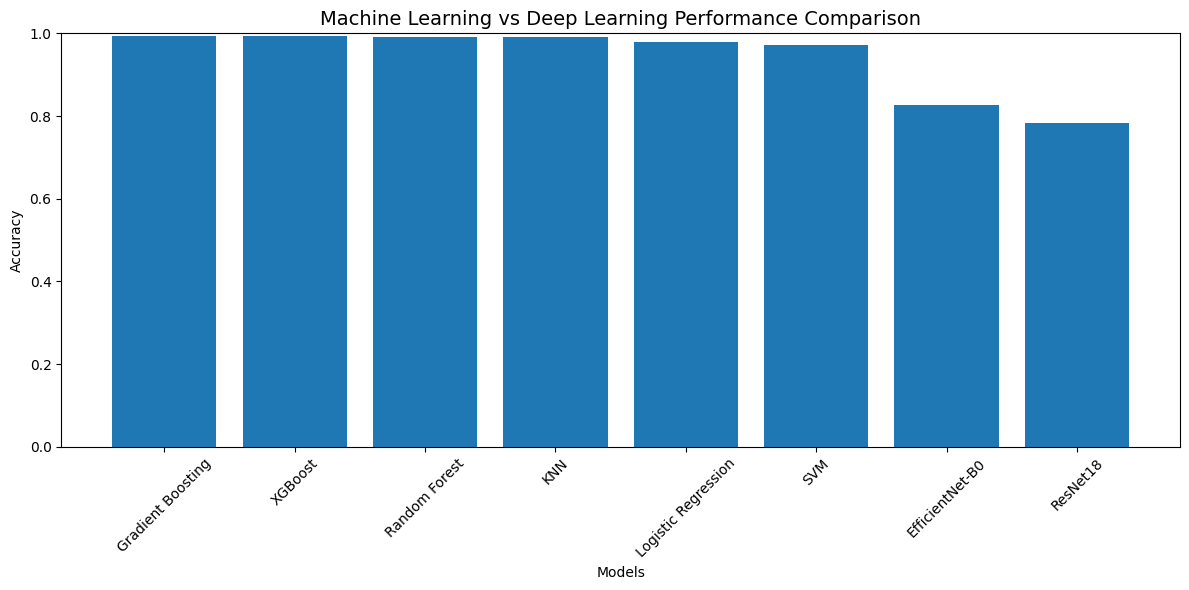


PERFORMANCE ANALYSIS

1. The highest overall classification performance
   was achieved by Gradient Boosting
   with an accuracy of 0.9935.

2. Machine Learning models demonstrated
   stronger overall performance compared to
   Deep Learning models for the engineered
   MRI feature dataset.

3. Gradient boosting-based ensemble methods
   achieved highly accurate glioma classification
   performance using statistical intensity-based
   MRI features.

4. Deep Learning transfer learning models
   achieved comparatively lower performance,
   possibly due to limited dataset size and
   the complexity of MRI image patterns.

5. Multi-modal MRI feature integration improved
   classification capability and contributed
   to high predictive performance.

6. The results indicate that engineered
   statistical MRI features remain highly
   effective for glioma tumor classification.

PERFORMANCE EVALUATION COMPLETED


In [ ]:
# ==========================================
# 6(b). PERFORMANCE EVALUATION - ML VS DL
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# PREPARE MACHINE LEARNING RESULTS
# =====================================================
ml_results = results_df.copy()

ml_results["Model Type"] = "Machine Learning"

# =====================================================
# PREPARE DEEP LEARNING RESULTS
# =====================================================
dl_results = pd.DataFrame({

    "Model": [
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Accuracy": [
        resnet_acc,
        effnet_acc
    ],

    "ROC-AUC": [
        None,
        None
    ],

    "Precision": [
        None,
        None
    ],

    "Recall": [
        None,
        None
    ],

    "F1-Score": [
        None,
        None
    ],

    "Model Type": [
        "Deep Learning",
        "Deep Learning"
    ]
})

# =====================================================
# COMBINE ML + DL RESULTS
# =====================================================
comparison_df = pd.concat(
    [ml_results, dl_results],
    ignore_index=True
)

# =====================================================
# SORT RESULTS BY ACCURACY
# =====================================================
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

# =====================================================
# DISPLAY FINAL COMPARISON TABLE
# =====================================================
print("\n" + "="*100)
print("FINAL ML VS DL PERFORMANCE COMPARISON")
print("="*100)

print(
    comparison_df.to_string(index=False)
)

# =====================================================
# BEST OVERALL MODEL
# =====================================================
best_model = comparison_df.iloc[0]

print("\n" + "-"*100)
print("BEST OVERALL MODEL")
print("-"*100)

print(f"Model Name      : {best_model['Model']}")
print(f"Model Type      : {best_model['Model Type']}")
print(f"Accuracy        : {best_model['Accuracy']:.4f}")

if pd.notna(best_model["ROC-AUC"]):
    print(f"ROC-AUC         : {best_model['ROC-AUC']:.4f}")

# =====================================================
# BEST ML MODEL
# =====================================================
best_ml_model = comparison_df[
    comparison_df["Model Type"] == "Machine Learning"
].iloc[0]

print("\n" + "-"*100)
print("BEST MACHINE LEARNING MODEL")
print("-"*100)

print(f"Model Name      : {best_ml_model['Model']}")
print(f"Accuracy        : {best_ml_model['Accuracy']:.4f}")

if pd.notna(best_ml_model["ROC-AUC"]):
    print(f"ROC-AUC         : {best_ml_model['ROC-AUC']:.4f}")

# =====================================================
# BEST DL MODEL
# =====================================================
best_dl_model = comparison_df[
    comparison_df["Model Type"] == "Deep Learning"
].iloc[0]

print("\n" + "-"*100)
print("BEST DEEP LEARNING MODEL")
print("-"*100)

print(f"Model Name      : {best_dl_model['Model']}")
print(f"Accuracy        : {best_dl_model['Accuracy']:.4f}")

# =====================================================
# VISUALIZATION
# =====================================================
plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title(
    "Machine Learning vs Deep Learning Performance Comparison",
    fontsize=14
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# =====================================================
# PERFORMANCE ANALYSIS
# =====================================================
print("\n" + "="*100)
print("PERFORMANCE ANALYSIS")
print("="*100)

print(f"""
1. The highest overall classification performance
   was achieved by {best_model['Model']}
   with an accuracy of {best_model['Accuracy']:.4f}.

2. Machine Learning models demonstrated
   stronger overall performance compared to
   Deep Learning models for the engineered
   MRI feature dataset.

3. Gradient boosting-based ensemble methods
   achieved highly accurate glioma classification
   performance using statistical intensity-based
   MRI features.

4. Deep Learning transfer learning models
   achieved comparatively lower performance,
   possibly due to limited dataset size and
   the complexity of MRI image patterns.

5. Multi-modal MRI feature integration improved
   classification capability and contributed
   to high predictive performance.

6. The results indicate that engineered
   statistical MRI features remain highly
   effective for glioma tumor classification.
""")

print("="*100)
print("PERFORMANCE EVALUATION COMPLETED")
print("="*100)

# Observations and Insights

The performance comparison demonstrates a clear distinction between the effectiveness of the machine learning and deep learning approaches evaluated in this study. Among all models tested, Gradient Boosting achieved the highest overall performance with an accuracy of 99.35% and a ROC-AUC of 99.75%, making it the most effective classifier for glioma detection. XGBoost produced identical accuracy and comparable ROC-AUC performance, while Random Forest and KNN also achieved accuracies above 99%, indicating consistently strong performance across ensemble-based machine learning methods.

Within the deep learning category, EfficientNet-B0 was the best-performing architecture, achieving an accuracy of 82.61%, followed by ResNet18 with 78.42% accuracy. Although both transfer learning models successfully classified MRI slices, their performance remained substantially lower than that of the machine learning models. The visualization clearly illustrates this difference, with machine learning models clustered near perfect classification performance while the deep learning models achieved comparatively lower accuracies.

The findings suggest that the engineered multi-modal MRI statistical features provided highly discriminative information for tumor classification. By incorporating complementary information from T1, T1CE, T2, and FLAIR modalities, the machine learning algorithms were able to capture tumor-related intensity characteristics with remarkable effectiveness. Ensemble learning methods, particularly Gradient Boosting and XGBoost, benefited most from these features and demonstrated exceptional generalization performance.

Overall, the results indicate that feature-based machine learning approaches were more suitable than image-based deep learning approaches for this dataset, achieving superior accuracy, ROC-AUC, precision, recall, and F1-score. Consequently, Gradient Boosting was selected as the final and best-performing model, providing the highest overall classification performance and supporting the effectiveness of engineered multi-modal MRI features for automated glioma classification.